# K_01d – Reale Grid-Topologie & Netzfluss-Animationen

**Grid-Arbitrage** · Echte Übertragungs-Netzstruktur (OSM/Overpass) für CH und weitere DACH/EU-Länder

**Gruppe:** SC26_Gruppe_2 | **Status:** Kür – erweiterte Infrastruktur-Analyse | **Abhängig von:** K_01c

---

> **Ziel:** Realistische Netzknoten (Substations) und Kanten (Hochspannungsleitungen) statt synthetischer
> Zonenzentroide. Animierter Energiefluss auf echten Leitungspfaden.
>
> **Länder-generisch:** Alle Datenquellen und Funktionen sind über `CC_CODE` parametrisiert.
> Für CH ist ein vollständiger Offline-Fallback (27 Knoten, 34 Kanten, 380/220 kV) eingebaut.
>
> **Datenquellen (Priorität):**
> 1. **earth-osm** (Geofabrik PBF) — vollständigste OSM-Quelle, kein Timeout-Risiko
> 2. **Overpass API** (OSM) — direktes OSM, bei grossen Ländern ggf. Timeout
> 3. **PyPSA-Eur Zenodo** (zenodo.org/records/14144752) — preprocessed, mit elektr. Parametern
> 4. **Hardcoded Baseline** — CH-spezifisch, offline, aus Swissgrid-Publikationen
>
> ⚠️ Alle Lastfluss-Werte bleiben synthetisch modelliert.


| [← K_01c Animationen](K_01c_Energiefluss_Animationen.ipynb) | [↑ Übersicht](../organisation/O_01_Project_Overview.ipynb) | [K_02 Cross-Border →](K_02_Cross_Border.ipynb) |
|:---|:---:|---:|

## Inhaltsverzeichnis<a id='toc_K_01d'></a>

[Einleitung](#einleitung_K_01d)  
[Initialisierung](#init_K_01d)  
1 [Grid-Topologie laden](#topo_K_01d)  
2 [Netzwerk-Graph aufbauen](#graph_K_01d)  
3 [Statische Netzwerkkarte](#static_K_01d)  
4 [Fluss-Modell auf Kanten](#flow_K_01d)  
5 [GIF A — Tagesfluss auf Leitungen](#gif_a_K_01d)  
6 [GIF B — Jahresverlauf & Richtungsumkehr](#gif_b_K_01d)  
7 [Multi-Country Erweiterung](#multi_K_01d)  
[Abschluss](#abschluss_K_01d)  


---
## Einleitung<a id='einleitung_K_01d'></a>

[↑ Inhaltsverzeichnis](#toc_K_01d)

**Reale Grid-Topologie** aus OpenStreetMap (earth-osm): Hoch- und
Höchstspannungsleitungen (110–380 kV) im Schweizer Übertragungsnetz.

- **Topologie laden** — OSM-Abfrage + Koordinaten-Parsing (lonlat-JSON)
- **Netzwerk-Graph** — NetworkX-Graph mit Spannungsebenen und Knoten-Snap
- **Statische Karte** — Leitungen als LineStrings auf contextily-Basemap
- **Fluss-Modell** — synthetische Energieflüsse auf den Kanten
- **GIF A/B** — animierte Tagesfluss- und Jahresverläufe
- **Multi-Country** — Erweiterung über die CH-Grenze hinaus
- **Slider-Widget** — interaktive Einzelframe-Navigation via `ipywidgets`
  (benötigt `ipywidgets` + `jupyterlab_widgets`, siehe `O_00_Installer`)

> Explorative Erweiterung — OSM-Daten haben variable Qualität.


---
## Initialisierung<a id='init_K_01d'></a>

[↑ Inhaltsverzeichnis](#toc_K_01d)

In [190]:
# ── lib/ aus Projekt-Root erreichbar machen + lib-Imports ───────────────────
# Notebook liegt in einem Unterordner (kuer/, experimental/, notebooks/,
# organisation/). Damit 'from lib.xxx import ...' funktioniert, muss der
# Projekt-Root vorne in sys.path stehen. autoreload sorgt dafür, dass
# Änderungen in lib/*.py ohne Kernel-Restart übernommen werden.
import sys, os
_PROJECT_ROOT = os.path.abspath('..')
if _PROJECT_ROOT not in sys.path:
    sys.path.insert(0, _PROJECT_ROOT)
try:
    get_ipython().run_line_magic('load_ext', 'autoreload')
    get_ipython().run_line_magic('autoreload', '2')
except Exception:
    pass

# lib-Imports (einmal zentral — in allen folgenden Zellen verfügbar)
from lib.widgets  import show_animation
from lib.plotting import show_source, should_skip, show_chart

from lib.io_ops   import log_dataindex, final_check
from lib.bfe_zonen import load_bfe_plants, aggregate_zone_prod
from lib.columns   import find_col

from lib.grid_topo    import load_kantone

from lib.map_animation  import make_gif_fast_map

print(f'lib-Pfad aktiv: {_PROJECT_ROOT}/lib')


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
lib-Pfad aktiv: C:\Users\patri\Documents\docker\python\OWN\Grid-Arbitrage/lib


In [191]:
# ════════════════════════════════════════════════════════════════════════════
# ⚙ PFAD-KONFIGURATION — experimental/ Notebook
# Automatische Projektroot-Erkennung (experimental/ liegt parallel zu kuer/)
# ════════════════════════════════════════════════════════════════════════════
import os

EXP_BASE      = '.'
EXP_DATA_DIR  = os.path.join(EXP_BASE, 'data', 'raw')                  # ⚙ Downloads + Rohdaten
EXP_RAW_DIR   = os.path.join(EXP_BASE, 'data', 'raw', 'zenodo')        # ⚙ Zenodo-Rohdaten (unverändert)
EXP_INTER_DIR = os.path.join(EXP_BASE, 'data', 'intermediate')         # ⚙ gefilterte Zwischenergebnisse
EXP_CACHE_DIR = os.path.join(EXP_BASE, 'data', 'intermediate', 'grid_zenodo')  # ⚙ per-Country Filter-Cache
EXP_OUTPUT_DIR= os.path.join(EXP_BASE, 'output', 'charts')             # ⚙ GIFs + Charts

def _find_project_root(start='.', max_levels=4):
    path = os.path.abspath(start)
    for _ in range(max_levels):
        if os.path.exists(os.path.join(path, 'sync', 'config.json')):
            return path
        path = os.path.dirname(path)
    return None

_root = _find_project_root()
if _root is None:
    raise RuntimeError("Projektroot nicht gefunden (sync/config.json fehlt).")

PROD_SYNC_DIR = os.path.join(_root, 'sync')
PROD_DATA_DIR = os.path.join(_root, 'data', 'raw')
PROD_INTER_DIR= os.path.join(_root, 'data', 'intermediate')
DATAINDEX     = os.path.join(PROD_SYNC_DIR, 'dataindex.csv')  # ⚙ SSOT: Projekt-weites Daten-Protokoll

for d in [EXP_DATA_DIR, EXP_RAW_DIR, EXP_INTER_DIR, EXP_CACHE_DIR, EXP_OUTPUT_DIR]:
    os.makedirs(d, exist_ok=True)

EXP_CHARTS_DIR = EXP_OUTPUT_DIR
DATA_SOURCE    = 'PyPSA-Eur Zenodo'

print(f"Projektroot: {_root}")
print(f"  PROD_DATA_DIR  = {os.path.abspath(PROD_DATA_DIR)}")
print(f"  EXP_RAW_DIR    = {os.path.abspath(EXP_RAW_DIR)}")
print(f"  EXP_CHARTS_DIR = {os.path.abspath(EXP_CHARTS_DIR)}")
print(f"  DATAINDEX      = {os.path.abspath(DATAINDEX)}")


Projektroot: C:\Users\patri\Documents\docker\python\OWN\Grid-Arbitrage
  PROD_DATA_DIR  = C:\Users\patri\Documents\docker\python\OWN\Grid-Arbitrage\data\raw
  EXP_RAW_DIR    = C:\Users\patri\Documents\docker\python\OWN\Grid-Arbitrage\experimental\data\raw\zenodo
  EXP_CHARTS_DIR = C:\Users\patri\Documents\docker\python\OWN\Grid-Arbitrage\experimental\output\charts
  DATAINDEX      = C:\Users\patri\Documents\docker\python\OWN\Grid-Arbitrage\sync\dataindex.csv


In [192]:
# ── Bibliotheken ─────────────────────────────────────────────────────────────
import os, warnings, json, time
import subprocess, sys
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.lines import Line2D
import requests
warnings.filterwarnings('ignore')

for pkg, imp in [('geopandas','geopandas'),('networkx','networkx'),('pillow','PIL')]:
    try: __import__(imp)
    except ImportError: subprocess.check_call([sys.executable,'-m','pip','install',pkg,'-q'])

import geopandas as gpd
import networkx as nx

# ── Logging-Level: INFO→WARNING damit stderr sauber bleibt ─────────────
import logging
for _log in ['earth_osm','eo','eo.stream','eo.backends',
             'matplotlib','matplotlib.animation','PIL']:
    logging.getLogger(_log).setLevel(logging.WARNING)
# matplotlib animation INFO-Meldungen zusätzlich über rcParams unterdrücken
import matplotlib as _mpl
_mpl.rcParams['animation.convert_path'] = 'convert'

print(f"GeoPandas  : {gpd.__version__}")
print(f"NetworkX   : {nx.__version__}")
print(f"📅 Ausgeführt: {datetime.now().strftime('%d.%m.%Y um %H:%M:%S')}")


GeoPandas  : 1.1.3
NetworkX   : 3.4.2
📅 Ausgeführt: 26.04.2026 um 16:59:57


In [193]:
# ── Config (SSOT) + Länder-Parameter ─────────────────────────────────────────
with open(os.path.join(PROD_SYNC_DIR, 'config.json'), encoding='utf-8') as _f: CFG = json.load(_f)

# ── ./xconfig.json laden (experimentelle Parameter, parallel zu config.json) ──
# Strukturell so aufgebaut, dass spätere Migration in config.json via Merge geht.
# Siehe ./MIGRATION.md für Details.
with open('xconfig.json', encoding='utf-8') as _f: XCFG = json.load(_f)

SZ_AKTIV = CFG['szenarien']['gleichzeitigkeit_aktiv']

# ── ⚙ Länder-Konfiguration aus xconfig.json (kuer.k01d.country_config) ──────
# ISO 3166-1 Alpha-2 Codes — erweiterbar in xconfig.json auf weitere Länder
_cc_x = XCFG['kuer']['k01d']['country_config']

# Bbox-Schema: xconfig hat (xlim, ylim) als Listen — in (minlon, minlat, maxlon, maxlat) konvertieren
def _make_country_dict(code, raw):
    """xconfig-Dict in K_01d-Schema konvertieren (mit zone_mapping aus k01b)."""
    bb = (raw['map_xlim'][0], raw['map_ylim'][0], raw['map_xlim'][1], raw['map_ylim'][1])
    d = {
        'name':        raw['name'],
        'osm_area':    f'ISO3166-1"="{raw["iso2"]}',
        'bbox':        bb,
        'voltage_kv':  raw['voltage_kv'],
        'map_xlim':    tuple(raw['map_xlim']),
        'map_ylim':    tuple(raw['map_ylim']),
    }
    # Zone-Mapping nur für CH aus k01b (andere Länder haben kein Zonenmodell hier)
    if code == 'CH':
        d['zone_mapping'] = XCFG['kuer']['k01b']['kanton_to_zone']
        d['zone_colors']  = XCFG['kuer']['k01b']['zone_colors']
    return d

COUNTRY_CONFIG = {code: _make_country_dict(code, raw) for code, raw in _cc_x.items()}

# ⚙ Aktives Land — aus xconfig.json (experimental_aktiv.country)
CC_CODE = XCFG['experimental_aktiv']['country']  # ⚙ experimental_aktiv.country
CC      = COUNTRY_CONFIG[CC_CODE]

# Farben aus config
_viz         = CFG.get('visualisierung', {}).get('farben', {})
BG_DARK      = _viz.get('bg_dark',    '#0d1117')
BG_PANEL     = _viz.get('bg_panel',   '#141414')
C_LOAD       = _viz.get('c_load',     '#66BB6A')
C_CHARGE     = _viz.get('c_charge',   '#1565C0')
C_FEED       = _viz.get('c_feed',     '#B71C1C')
C_PRICE      = _viz.get('c_price',    '#FFA726')
C_SPINE      = _viz.get('c_spine',    '#333333')
C_ACHSE      = _viz.get('c_achse',    '#aaaaaa')
C_TICK       = _viz.get('c_tick',     '#bbbbbb')
_stil        = CFG.get('visualisierung', {}).get('stil', {})
FS_TITEL     = _stil.get('schriftgroesse_titel', 13)
FS_KLEIN     = _stil.get('schriftgroesse_klein',  7)

# Leitungsfarben nach Spannung — aus xconfig.json (kuer.k01d.voltage_styling)
_vs = XCFG['kuer']['k01d']['voltage_styling']
VOLTAGE_COLORS = {int(k): v for k, v in _vs['colors'].items()}  # JSON-keys sind str
VOLTAGE_LW     = {int(k): v for k, v in _vs['lw'].items()}

# Aliases (müssen vor print stehen)
ZENODO_RECORD  = XCFG['kuer']['k01d']['animation_zenodo']['record']  # ⚙ kuer.k01d.animation_zenodo.record
CACHE_DIR      = EXP_CACHE_DIR
EXP_CHARTS_DIR = EXP_OUTPUT_DIR
DATA_DIR       = PROD_DATA_DIR
DATA_SOURCE    = XCFG['kuer']['k01d']['animation_zenodo']['data_source_label']

print(f"Aktives Land: {CC_CODE} — {CC['name']}")
print(f"Spannungsebenen: {CC['voltage_kv']} kV")
print(f"Cache: {CACHE_DIR}")


Aktives Land: CH — Schweiz
Spannungsebenen: [110, 132, 150, 220, 380] kV
Cache: .\data\intermediate\grid_zenodo


**⚙ Markdown-Prüfwerte (xconfig-abhängig)**:  
Werte mit ⚙ kommen aus `./xconfig.json` (experimentell). Bei Migration in `../sync/config.json` siehe `./MIGRATION.md`.


In [194]:
# ── ⚙ Markdown-Prüfwerte (xconfig-abhängig) ────────────────────────────────
print('=== ⚙ MARKDOWN-PRÜFWERTE (xconfig.json — experimentell) ===')
_xa = XCFG['experimental_aktiv']
print(f'  Aktives Land               = {_xa["country"]}  (Optionen: {_xa["_country_optionen"]})')
print(f'  Aktives Zonenmodell        = {_xa["zonenmodell"]}  (für CH; sonst irrelevant)')
print()
print(f'  COUNTRY_CONFIG geladen für: {list(COUNTRY_CONFIG.keys())}')
print(f'    Aktiv: {CC["name"]} | bbox={CC["bbox"]} | {CC["voltage_kv"]} kV')
print()
_az = XCFG['kuer']['k01d']['animation_zenodo']
_zenodo = XCFG['kuer']['k01d']['animation_zenodo']['record']
print(f'  Animation:')
print(f'    Frame-Mult               = {_az["frame_mult"]}')
print(f'    Phase-Rot/sec (max)      = {_az["phase_rot_per_sec"]}')
print(f'    Flow-Threshold           = {_az["flow_threshold_mw"]} MW')
print()
print(f'  Zenodo-Datenquelle:')
print(f'    Record                   = {_zenodo}')
print()
_lay = XCFG['kuer']['k01d']['overlay_layout']
print(f'  Overlay-Layout (User-justiert):')
print(f'    Bilanz-Pos               = {tuple(_lay["bilanz"]["pos"])}  (manuell justiert!)')
print(f'    Saldo-Pos                = {tuple(_lay["saldo"]["pos"])}')
print(f'    Balken-Pos               = {tuple(_lay["balken"]["pos"])}')
print(f'    {sum(1 for o in _lay.values() if isinstance(o, dict) and o.get("ein", False))}/{len(_lay)} Overlays aktiv')


=== ⚙ MARKDOWN-PRÜFWERTE (xconfig.json — experimentell) ===
  Aktives Land               = CH  (Optionen: ['CH', 'DE', 'AT', 'FR', 'IT'])
  Aktives Zonenmodell        = k01b_6zonen  (für CH; sonst irrelevant)

  COUNTRY_CONFIG geladen für: ['CH', 'DE', 'AT']
    Aktiv: Schweiz | bbox=(5.88, 45.78, 10.65, 47.95) | [110, 132, 150, 220, 380] kV

  Animation:
    Frame-Mult               = 3
    Phase-Rot/sec (max)      = 0.25
    Flow-Threshold           = 15 MW

  Zenodo-Datenquelle:
    Record                   = 14144752

  Overlay-Layout (User-justiert):
    Bilanz-Pos               = (0.04, 0.75)  (manuell justiert!)
    Saldo-Pos                = (0.5, 0.95)
    Balken-Pos               = (0.99, 0.82)
    10/11 Overlays aktiv


**🔎 Quellcode der importierten lib-Funktion**

`load_kantone` aus `lib/grid_topo.py` — lädt Schweizer Kantonsgrenzen
mit automatischer Kürzel-Detektion (Spalte `KAB`). Aufklappbar darunter
ist der Quellcode einsehbar.


In [195]:
show_source(load_kantone)


<details>
<summary>🔎 Quellcode: <code>load_kantone</code> (aus <code>lib/grid_topo.py</code>)</summary>

```python
def load_kantone(data_dirs, download_url=None, download_target=None,
                 min_file_size=50_000, verbose=True):
    """Lädt Schweizer Kantonsgrenzen aus GeoPackage-Cache.

    Probiert mehrere Pfad-Kandidaten nacheinander, wählt den ersten der
    existiert und gross genug ist. Normalisiert auf EPSG:4326, ergänzt
    eine ``KAB``-Spalte mit 2-Buchstaben-Kürzeln.

    Parameter
    ---------
    data_dirs : list[str] oder str
        Liste von Dateipfaden zu kantone.gpkg oder swissboundaries3d.gpkg
        die nacheinander probiert werden. Einzelner String wird automatisch
        in eine Liste gewandelt.
    download_url : str, optional
        URL zu einem swissBOUNDARIES3D ZIP. Wenn gesetzt UND alle Pfade
        fehlschlagen, wird das ZIP heruntergeladen, .gpkg extrahiert und
        unter ``download_target`` gespeichert.
    download_target : str, optional
        Zielpfad für den Download (nur genutzt wenn ``download_url`` gesetzt).
    min_file_size : int, default 50_000 (50 KB)
        Minimale Dateigrösse in Bytes für eine Cache-Datei als gültig.
    verbose : bool, default True
        Status-Meldungen auf stdout.

    Return
    ------
    geopandas.GeoDataFrame oder None
        Kantone-GeoDataFrame mit Spalten inkl. ``KAB`` (2-Buchstaben-Kürzel)
        und CRS EPSG:4326. ``None`` wenn kein Cache gefunden UND
        (Download nicht versucht ODER fehlgeschlagen).
    """
    import geopandas as gpd

    if isinstance(data_dirs, str):
        data_dirs = [data_dirs]

    # ── Schritt 1: Cache-Datei finden ─────────────────────────────────────────
    kant_file = None
    for path in data_dirs:
        if os.path.exists(path) and os.path.getsize(path) > min_file_size:
            kant_file = path
            break

    # ── Schritt 2: Download-Fallback ──────────────────────────────────────────
    if kant_file is None and download_url and download_target:
        if verbose:
            print(f'Kantone-Cache fehlt — lade swissBOUNDARIES3D...')
        try:
            import requests
            import zipfile
            zip_path = download_target + '.zip'
            r = requests.get(download_url, timeout=120, stream=True)
            r.raise_for_status()
            with open(zip_path, 'wb') as f:
                for chunk in r.iter_content(1024 * 512):
                    f.write(chunk)
            with zipfile.ZipFile(zip_path) as z:
                gpkg_in_zip = next((n for n in z.namelist()
                                    if n.lower().endswith('.gpkg')), None)
                if gpkg_in_zip:
                    with z.open(gpkg_in_zip) as src, open(download_target, 'wb') as dst:
                        dst.write(src.read())
                    kant_file = download_target
                    if verbose:
                        print(f'  Extrahiert: {kant_file}')
        except Exception as e:
            if verbose:
                print(f'  Download fehlgeschlagen: {e}')

    if kant_file is None:
        if verbose:
            print('⚠️  Kantone nicht gefunden — Karte ohne Grenzen')
        return None

    # ── Schritt 3: Laden + CRS-Normalisierung ─────────────────────────────────
    try:
        layers = gpd.list_layers(kant_file)
        lname = next((l for l in layers['name'] if 'kanton' in l.lower()),
                     layers['name'].iloc[0])
        gdf = gpd.read_file(kant_file, layer=lname)
        if gdf.crs and gdf.crs.to_epsg() != 4326:
            gdf = gdf.to_crs(epsg=4326)
    except Exception as e:
        if verbose:
            print(f'  Ladefehler: {e}')
        return None

    # ── Schritt 4: KAB-Spalte ableiten — WERTE-basiert (robust gegen Schema-Änderungen)
    # Spaltenname ist NICHT die Wahrheit (z.B. swissBOUNDARIES3D 2026-01 hat
    # eine 'icc'-Spalte mit 'CH' = Land-Code, nicht Kantonskürzel). Wir prüfen
    # daher die WERTE jeder Spalte gegen die drei möglichen Repräsentationen:
    # (1) Kürzel als String, (2) Nummer 1-26, (3) Kantonsname.
    import pandas as pd

    # Vorhandene KAB-Spalte zuerst entfernen, falls die Werte fragwürdig sind.
    # Robust: prüfe sowohl Anzahl valider Kürzel ALS AUCH Eindeutigkeit
    # (eine Spalte mit allen 'FR' hat 26 valide Kürzel aber nur 1 unique →
    # ist offensichtlich keine Kantons-ID).
    if 'KAB' in gdf.columns:
        pre = gdf['KAB'].astype(str).str.strip().str.upper()
        n_valid_pre  = pre.isin(KANT_ABK_SET).sum()
        n_unique_pre = pre[pre.isin(KANT_ABK_SET)].nunique()
        if n_valid_pre < 20 or n_unique_pre < 20:
            if verbose:
                print(f'  Vorhandene KAB-Spalte ist nicht valide '
                      f'(valid={n_valid_pre}, unique={n_unique_pre}, '
                      f'Sample: {pre.head(3).tolist()}) — Strategien anwenden')
            gdf = gdf.drop(columns=['KAB'])
        else:
            gdf['KAB'] = pre

    found = False

    # ── Strategie 1: Spalte mit Werten = 2-Buchstaben-Kürzel ─────────────────
    # Validierung: >=20 valide UND >=20 verschiedene Werte (nicht alle gleich)
    if 'KAB' not in gdf.columns:
        for col in gdf.columns:
            if col == 'geometry':
                continue
            try:
                vals = gdf[col].astype(str).str.strip().str.upper()
                valid_mask = vals.isin(KANT_ABK_SET)
                n_valid  = valid_mask.sum()
                n_unique = vals[valid_mask].nunique()
                if n_valid >= 20 and n_unique >= 20:
                    gdf['KAB'] = vals
                    if verbose:
                        print(f'  KAB via Kürzel-Werte in "{col}" '
                              f'({n_valid}/{len(gdf)} Treffer, {n_unique} unique)')
                    found = True
                    break
            except Exception:
                continue

    # ── Strategie 2: Spalte mit Zahlen 1..26 (Kantons-Nummer) ─────────────────
    # KRITISCH: erstellung_monat hat auch Werte 1-12 in [1,26] und würde sonst
    # fälschlich als Kantonsnummer interpretiert. Eindeutigkeit prüfen!
    # Echte Kantone: 26 verschiedene Nummern. erstellung_monat: max 12.
    if not found:
        for col in gdf.columns:
            if col == 'geometry':
                continue
            try:
                nums = pd.to_numeric(gdf[col], errors='coerce')
                between = nums.between(1, 26)
                n_in    = between.sum()
                n_uniq  = nums[between].nunique()
                if n_in >= 20 and n_uniq >= 20:
                    gdf['KAB'] = nums.map(KANT_NUM_TO_ABK).fillna('??')
                    if verbose:
                        print(f'  KAB via Kantonsnummer-Werte in "{col}" '
                              f'({n_in}/{len(gdf)} Treffer, {n_uniq} unique)')
                    found = True
                    break
            except Exception:
                continue

    # ── Strategie 3: Spalte mit Kantonsnamen (DE/FR/IT) ───────────────────────
    # Auch hier nunique prüfen — falls eine Spalte versehentlich denselben Namen
    # häufig wiederholt
    if not found:
        for col in gdf.columns:
            if col == 'geometry':
                continue
            try:
                mapped  = gdf[col].astype(str).str.strip().map(KANT_NAME_TO_ABK)
                n_map   = mapped.notna().sum()
                n_uniq  = mapped.dropna().nunique()
                if n_map >= 20 and n_uniq >= 20:
                    gdf['KAB'] = mapped.fillna('??')
                    if verbose:
                        print(f'  KAB via Kantonsname-Werte in "{col}" '
                              f'({n_map}/{len(gdf)} Treffer, {n_uniq} unique)')
                    found = True
                    break
            except Exception:
                continue

    # ── Diagnose bei Misserfolg ───────────────────────────────────────────────
    if not found:
        if 'KAB' not in gdf.columns:
            gdf['KAB'] = '??'
        if verbose:
            print(f'⚠️  KAB konnte nicht abgeleitet werden — keine Strategie greift.')
            print(f'   Verfügbare Spalten + Beispielwerte:')
            for c in gdf.columns:
                if c == 'geometry':
                    continue
                sample = gdf[c].iloc[0] if len(gdf) else '(leer)'
                print(f'     {c!r:25s} = {sample!r}')

    if verbose:
        n_valid = gdf['KAB'].isin(KANT_ABK_SET).sum() if 'KAB' in gdf.columns else 0
        print(f'Kantone: {len(gdf)} | {n_valid} valide Kürzel | {os.path.basename(kant_file)}')

    return gdf
```

</details>


In [196]:
# ── Kantone laden (K_01 Cache oder Download) ─────────────────────────────────
import geopandas as gpd

KANT_CANDIDATES = [
    os.path.join(PROD_DATA_DIR, 'kantone.gpkg'),
    os.path.join(PROD_DATA_DIR, 'swissboundaries3d.gpkg'),
]
KANT_NUM_TO_ABK = {
    1:'ZH',2:'BE',3:'LU',4:'UR',5:'SZ',6:'OW',7:'NW',8:'GL',
    9:'ZG',10:'FR',11:'SO',12:'BS',13:'BL',14:'SH',15:'AR',16:'AI',
    17:'SG',18:'GR',19:'AG',20:'TG',21:'TI',22:'VD',23:'VS',24:'NE',25:'GE',26:'JU'
}

gdf_kant = load_kantone([
    os.path.join(PROD_DATA_DIR, 'kantone.gpkg'),
    os.path.join(PROD_DATA_DIR, 'swissboundaries3d.gpkg'),
])
print(f"gdf_kant: {len(gdf_kant) if gdf_kant is not None else 'None'}")


  KAB via Kantonsnummer-Werte in "kantonsnummer" (26/26 Treffer, 26 unique)
Kantone: 26 | 26 valide Kürzel | kantone.gpkg
gdf_kant: 26


In [197]:
# ── Bekannte Netzengpässe (Swissgrid-Quellen) ────────────────────────────────
# Format: (lon1, lat1, lon2, lat2, label, label_dlon, label_dlat)
# Quelle: Swissgrid Netzentwicklungsplan 2040 + eigene Recherche
ENGPASSLINIEN = [
    (8.62, 46.63, 8.62, 47.08, 'Göschenen-\nAirolo',   0.22,  0.0 ),  # Gotthardachse
    (7.10, 46.82, 6.35, 46.48, 'Westgrenze\nFR-CH',   -0.35, -0.12),  # Romand-Export
    (8.04, 47.40, 8.62, 47.40, 'AG-ZH\nMittelland',    0.02, -0.14),  # Mittelland-Engpass
]

def draw_engpaesse(ax, lw=2.5, alpha=0.85, fontsize=7):
    """Zeichnet bekannte Swissgrid-Engpässe als rote gestrichelte Linien."""
    import matplotlib.patches as _ep
    for lon1,lat1,lon2,lat2,label,dlon,dlat in ENGPASSLINIEN:
        ax.plot([lon1,lon2],[lat1,lat2], color='#FF5252', lw=lw,
                linestyle='--', alpha=alpha, zorder=18,
                solid_capstyle='round',
                path_effects=None)
        # Pfeil + Label
        mid_lon = (lon1+lon2)/2 + dlon
        mid_lat = (lat1+lat2)/2 + dlat
        ax.annotate(label, xy=((lon1+lon2)/2,(lat1+lat2)/2),
                    xytext=(mid_lon, mid_lat),
                    color='#FF5252', fontsize=fontsize, fontweight='bold',
                    ha='center', va='center', zorder=19,
                    bbox=dict(boxstyle='round,pad=0.2', fc='#0d1117',
                              alpha=0.8, lw=0),
                    arrowprops=dict(arrowstyle='->', color='#FF5252',
                                   lw=1.2, alpha=0.7))

print(f"✅ ENGPASSLINIEN: {len(ENGPASSLINIEN)} Engpässe definiert")
for _e in ENGPASSLINIEN:
    print(f"   {_e[4].replace(chr(10),' ')}: ({_e[0]},{_e[1]}) → ({_e[2]},{_e[3]})")


✅ ENGPASSLINIEN: 3 Engpässe definiert
   Göschenen- Airolo: (8.62,46.63) → (8.62,47.08)
   Westgrenze FR-CH: (7.1,46.82) → (6.35,46.48)
   AG-ZH Mittelland: (8.04,47.4) → (8.62,47.4)


In [198]:
# ══════════════════════════════════════════════════════════════════════════════
# ⚙ ANIMATIONS-SCHALTER K_01d — alle visuellen Parameter hier einstellen
# ══════════════════════════════════════════════════════════════════════════════

# ── Frame-Auflösung ───────────────────────────────────────────────────────────
_anim = CFG.get('animation', {})
FRAMES_PER_HOUR = _anim.get('frames_per_hour', 4)
FRAMES_PER_WEEK = _anim.get('frames_per_week', 4)

# ⚙ Frame-Multiplikator für flüssigere Animation — aus xconfig.json
# 1 = Config-Default (24h = 96 Frames @ 10fps)  | 2 = doppelt | 3 = dreifach (Default)
# 4 = sehr smooth, langer Render
# Dank fps-basierter Phase-Normierung ist die visuelle Dot-Geschwindigkeit
# UNABHÄNGIG von FRAME_MULT. Mehr Frames = nur smoother.
FRAME_MULT = XCFG['kuer']['k01d']['animation_zenodo']['frame_mult']  # ⚙ kuer.k01d.animation_zenodo.frame_mult
FRAMES_PER_HOUR = FRAMES_PER_HOUR * FRAME_MULT
FRAMES_PER_WEEK = FRAMES_PER_WEEK * FRAME_MULT

N_FRAMES_TAG    = 24 * FRAMES_PER_HOUR
N_FRAMES_JAHR   = 52 * FRAMES_PER_WEEK
FPS_TAG         = _anim.get('fps_karte', 10) * FRAME_MULT
FPS_JAHR        = _anim.get('fps_karte', 10) * FRAME_MULT
DPI_GIF         = _anim.get('dpi', 110)

# ── GIF Fluss-Dots — aus xconfig.json (kuer.k01d.gif_d) ─────────────────────
_gD = XCFG['kuer']['k01d']['gif_d']
GIF_D_NORM_MODE      = _gD['norm_mode']         # ⚙ kuer.k01d.gif_d.norm_mode
GIF_D_MW_NORM_GLOBAL = _gD['mw_norm_global']    # ⚙ kuer.k01d.gif_d.mw_norm_global
GIF_D_N_DOTS_BASE    = _gD['n_dots_base']       # ⚙ kuer.k01d.gif_d.n_dots_base
GIF_D_DOT_SIZE       = _gD['dot_size']          # ⚙ kuer.k01d.gif_d.dot_size
GIF_D_MIN_MW         = _gD['min_mw']            # ⚙ kuer.k01d.gif_d.min_mw
GIF_D_SHOW_LABEL     = _gD['show_label']        # ⚙ kuer.k01d.gif_d.show_label

# ── Animations-Zenodo-Parameter (Phase, Hubs, Hintergrund) — aus xconfig.json
_az = XCFG['kuer']['k01d']['animation_zenodo']
PHASE_ROT_PER_SEC_AT_MAX = _az['phase_rot_per_sec']    # ⚙ kuer.k01d.animation_zenodo.phase_rot_per_sec
FLOW_HUBS_PER_ZONE       = _az['flow_hubs_per_zone']   # ⚙ kuer.k01d.animation_zenodo.flow_hubs_per_zone
FLOW_THRESHOLD_MW        = _az['flow_threshold_mw']    # ⚙ kuer.k01d.animation_zenodo.flow_threshold_mw
BG_EDGE_ALPHA            = _az['bg_edge_alpha']        # ⚙ kuer.k01d.animation_zenodo.bg_edge_alpha
BG_NODE_ALPHA            = _az['bg_node_alpha']        # ⚙ kuer.k01d.animation_zenodo.bg_node_alpha
BORDER_HUB_MARK          = _az['border_hub_mark']      # ⚙ kuer.k01d.animation_zenodo.border_hub_mark

print("⚙ K_01d Animations-Schalter:")
print(f"  Auflösung: {FRAMES_PER_HOUR}f/h × 24h = {N_FRAMES_TAG}f Tag "
      f"| {FRAMES_PER_WEEK}f/W × 52W = {N_FRAMES_JAHR}f Jahr (FRAME_MULT={FRAME_MULT})")
print(f"  fps: {FPS_TAG} Tag / {FPS_JAHR} Jahr | Dauer Tag: {N_FRAMES_TAG/FPS_TAG:.1f}s")
print(f"  Phase-Geschwindigkeit: {PHASE_ROT_PER_SEC_AT_MAX:.2f} Umläufe/s bei max flow")
print(f"  norm='{GIF_D_NORM_MODE}' | n_dots={GIF_D_N_DOTS_BASE} | min={GIF_D_MIN_MW}MW")
print(f"  Fluss-Modell: Top-{FLOW_HUBS_PER_ZONE} Hubs/Zone | threshold={FLOW_THRESHOLD_MW}MW")
print(f"  Sichtbarkeit: Kanten-α={BG_EDGE_ALPHA} | Knoten-α={BG_NODE_ALPHA} | Border-Mark={BORDER_HUB_MARK}")


⚙ K_01d Animations-Schalter:
  Auflösung: 12f/h × 24h = 288f Tag | 12f/W × 52W = 624f Jahr (FRAME_MULT=3)
  fps: 30 Tag / 30 Jahr | Dauer Tag: 9.6s
  Phase-Geschwindigkeit: 0.25 Umläufe/s bei max flow
  norm='per_edge' | n_dots=4 | min=40MW
  Fluss-Modell: Top-4 Hubs/Zone | threshold=15MW
  Sichtbarkeit: Kanten-α=0.55 | Knoten-α=0.65 | Border-Mark=True


In [199]:
# ══════════════════════════════════════════════════════════════════════════════
# ⚙  OVERLAY-PARAMETER — Layout-Settings aus xconfig.json (kuer.k01d.overlay_layout)
# ══════════════════════════════════════════════════════════════════════════════
#
# Diese Zelle liest alle Overlay-Settings aus xconfig.json.
# Anpassungen direkt in xconfig.json vornehmen → diese Cell + Vorschau-Zelle
# erneut laufen lassen → prüfen → erst dann GIF-Zellen ausführen.
#
# Layout-System (für Anpassungen in xconfig.json):
#
#    (0.0, 1.0) ─────── (0.5, 1.0) ─────── (1.0, 1.0)    ← oben
#        │                  │                  │
#        │            Karte der Schweiz        │
#        │                  │                  │
#    (0.0, 0.5)         (0.5, 0.5)         (1.0, 0.5)    ← mitte
#        │                  │                  │
#        │                  │                  │
#    (0.0, 0.0) ─────── (0.5, 0.0) ─────── (1.0, 0.0)    ← unten
#
# AUSRICHTUNG (align):
#   ['right', 'top']    → Box startet rechts-oben und wächst nach links/unten
#   ['left',  'top']    → Box startet links-oben  und wächst nach rechts/unten
#   ['left',  'bottom'] → Box startet links-unten und wächst nach rechts/oben
#   ['right', 'bottom'] → Box startet rechts-unten und wächst nach links/oben
#   ['center','center'] → Box zentriert um pos
#
# SCHRIFTGRÖSSEN (Punkt = pt):
#   4.0 = sehr klein, 5.5 = klein, 6.5 = mittel, 7.5 = gross, 10 = sehr gross

# ══════════════════════════════════════════════════════════════════════════════
# ⚡ ZONENMODELL — aus xconfig.json (experimental_aktiv.zonenmodell)
# ══════════════════════════════════════════════════════════════════════════════
# 'k01b_6zonen' (Default) = Nordost, Ostschweiz, Mitte-Erzeugung, Mitte-Transit, West, Süd
# 'k01_5zonen'            = Nord, Mitte, West, Süd, Ost
#
# ACHTUNG: Umschalten erfordert Neuausführung von:
#   k01d-flow-model → k01d-graph-build → alle nachfolgenden Zellen
USE_ZONE_MODEL_K01 = (XCFG['experimental_aktiv']['zonenmodell'] == 'k01_5zonen')

# ── Layout-Settings aus xconfig.json laden ──────────────────────────────────
_lay = XCFG['kuer']['k01d']['overlay_layout']

def _t(v):
    """Listen aus JSON in Tupel konvertieren (für Matplotlib-Konsistenz)."""
    return tuple(v) if isinstance(v, list) else v

# Legende Spannung
_o = _lay['leg_spannung']
OV_LEG_SPANNUNG_EIN   = _o['ein']
OV_LEG_SPANNUNG_POS   = _t(_o['pos'])
OV_LEG_SPANNUNG_ALIGN = _t(_o['align'])
OV_LEG_SPANNUNG_SIZE  = _o['size']
OV_LEG_SPANNUNG_TITEL = _o['titel']
LEGEND_KV_LEVELS      = _o['kv_levels']

# Legende Dot-Skala
_o = _lay['leg_dotmw']
OV_LEG_DOTMW_EIN   = _o['ein']
OV_LEG_DOTMW_POS   = _t(_o['pos'])
OV_LEG_DOTMW_ALIGN = _t(_o['align'])
OV_LEG_DOTMW_SIZE  = _o['size']
OV_LEG_DOTMW_TITEL = _o['titel']
OV_LEG_DOTMW_WERTE = _o['werte']

# CH-Saldo
_o = _lay['saldo']
OV_SALDO_EIN   = _o['ein']
OV_SALDO_POS   = _t(_o['pos'])
OV_SALDO_ALIGN = _t(_o['align'])
OV_SALDO_SIZE  = _o['size']

# CH-Produktion/Verbrauch
_o = _lay['prodverb']
OV_PRODVERB_EIN   = _o['ein']
OV_PRODVERB_POS   = _t(_o['pos'])
OV_PRODVERB_ALIGN = _t(_o['align'])
OV_PRODVERB_SIZE  = _o['size']

# Grenzflüsse-Summen
_o = _lay['grenzen']
OV_GRENZEN_EIN   = _o['ein']
OV_GRENZEN_POS   = _t(_o['pos'])
OV_GRENZEN_ALIGN = _t(_o['align'])
OV_GRENZEN_SIZE  = _o['size']

# Zonen-Imbalance Labels (automatische Position)
_o = _lay['zonen']
OV_ZONEN_EIN   = _o['ein']
OV_ZONEN_SIZE  = _o['size']
OV_ZONEN_ALPHA = _o['alpha']

# Grenzlabels (automatische Position)
_o = _lay['grenzlbl']
OV_GRENZLBL_EIN   = _o['ein']
OV_GRENZLBL_SIZE  = _o['size']
OV_GRENZLBL_ALPHA = _o['alpha']

# Zeit-Label
_o = _lay['zeit']
OV_ZEIT_EIN  = _o['ein']
OV_ZEIT_SIZE = _o['size']

# Balkendiagramm
_o = _lay['balken']
OV_BALKEN_EIN     = _o['ein']
OV_BALKEN_POS     = _t(_o['pos'])
OV_BALKEN_ALIGN   = _t(_o['align'])
OV_BALKEN_BREITE  = _o['breite']
OV_BALKEN_HOEHE   = _o['hoehe']
OV_BALKEN_SIZE    = _o['size']
OV_BALKEN_YMAX_MW = _o['ymax_mw']
OV_BALKEN_ALPHA   = _o['alpha']

# Bilanz
_o = _lay['bilanz']
OV_BILANZ_EIN     = _o['ein']
OV_BILANZ_POS     = _t(_o['pos'])
OV_BILANZ_ALIGN   = _t(_o['align'])
OV_BILANZ_BREITE  = _o['breite']
OV_BILANZ_HOEHE   = _o['hoehe']
OV_BILANZ_SIZE    = _o['size']
OV_BILANZ_YMAX_MW = _o['ymax_mw']
OV_BILANZ_ALPHA   = _o['alpha']

# OVERLAYS-Dict (wird von draw_*-Funktionen gelesen)
OVERLAYS = {
    'legende_spannung':        {'enabled': OV_LEG_SPANNUNG_EIN, 'pos': OV_LEG_SPANNUNG_POS, 'align': OV_LEG_SPANNUNG_ALIGN, 'size': OV_LEG_SPANNUNG_SIZE, 'title': OV_LEG_SPANNUNG_TITEL},
    'legende_dot_mw':          {'enabled': OV_LEG_DOTMW_EIN,    'pos': OV_LEG_DOTMW_POS,    'align': OV_LEG_DOTMW_ALIGN,    'size': OV_LEG_DOTMW_SIZE,    'title': OV_LEG_DOTMW_TITEL},
    'ch_saldo':                {'enabled': OV_SALDO_EIN,        'pos': OV_SALDO_POS,        'align': OV_SALDO_ALIGN,        'size': OV_SALDO_SIZE},
    'ch_produktion_verbrauch': {'enabled': OV_PRODVERB_EIN,     'pos': OV_PRODVERB_POS,     'align': OV_PRODVERB_ALIGN,     'size': OV_PRODVERB_SIZE},
    'grenzen_summen':          {'enabled': OV_GRENZEN_EIN,      'pos': OV_GRENZEN_POS,      'align': OV_GRENZEN_ALIGN,      'size': OV_GRENZEN_SIZE},
    'zonen_imbalance':         {'enabled': OV_ZONEN_EIN,        'size': OV_ZONEN_SIZE,      'alpha': OV_ZONEN_ALPHA},
    'grenzen_label':           {'enabled': OV_GRENZLBL_EIN,     'size': OV_GRENZLBL_SIZE,   'alpha': OV_GRENZLBL_ALPHA},
    'zeit_label':              {'enabled': OV_ZEIT_EIN,         'size': OV_ZEIT_SIZE},
    'balkendiagramm':          {'enabled': OV_BALKEN_EIN,       'pos': OV_BALKEN_POS,       'align': OV_BALKEN_ALIGN, 'breite': OV_BALKEN_BREITE, 'hoehe': OV_BALKEN_HOEHE, 'size': OV_BALKEN_SIZE, 'ymax_mw': OV_BALKEN_YMAX_MW, 'alpha': OV_BALKEN_ALPHA},
    'bilanz':                  {'enabled': OV_BILANZ_EIN,       'pos': OV_BILANZ_POS,       'align': OV_BILANZ_ALIGN, 'breite': OV_BILANZ_BREITE, 'hoehe': OV_BILANZ_HOEHE, 'size': OV_BILANZ_SIZE, 'ymax_mw': OV_BILANZ_YMAX_MW, 'alpha': OV_BILANZ_ALPHA},
}
LEGEND_DOT_MW = OV_LEG_DOTMW_WERTE   # Alias für draw_overlay_legende_dot_mw

# ── Übersicht ausgeben ──
print('⚙  Overlay-Konfiguration aktiv (aus xconfig.json):')
print(f'   Zonenmodell: {"K_01 (5 Zonen, erste Festlegung)" if USE_ZONE_MODEL_K01 else "K_01b (6 Zonen, erweitert)"}')
print()
print(f'{"Overlay":<30}{"Ein":<6}{"Position":<20}{"Grösse":<8}')
print('─' * 64)
_rows = [
    ('Legende Spannung',        OV_LEG_SPANNUNG_EIN,  OV_LEG_SPANNUNG_POS,  OV_LEG_SPANNUNG_SIZE),
    ('Legende Dot-MW',          OV_LEG_DOTMW_EIN,     OV_LEG_DOTMW_POS,     OV_LEG_DOTMW_SIZE),
    ('CH-Saldo',                OV_SALDO_EIN,         OV_SALDO_POS,         OV_SALDO_SIZE),
    ('CH-Produktion/Verbrauch', OV_PRODVERB_EIN,      OV_PRODVERB_POS,      OV_PRODVERB_SIZE),
    ('Grenzflüsse-Summen',      OV_GRENZEN_EIN,       OV_GRENZEN_POS,       OV_GRENZEN_SIZE),
    ('Zonen-Imbalance',         OV_ZONEN_EIN,         '(automatisch)',      OV_ZONEN_SIZE),
    ('Grenzen-Labels',          OV_GRENZLBL_EIN,      '(automatisch)',      OV_GRENZLBL_SIZE),
    ('Zeit-Label',              OV_ZEIT_EIN,          '(fest oben)',        OV_ZEIT_SIZE),
    ('Balkendiagramm P/V',      OV_BALKEN_EIN,        OV_BALKEN_POS,        OV_BALKEN_SIZE),
    ('Bilanz (separat)',        OV_BILANZ_EIN,        OV_BILANZ_POS,        OV_BILANZ_SIZE),
]
for name, ein, pos, size in _rows:
    ein_s = '✅ an' if ein else '⛔ aus'
    pos_s = str(pos) if not isinstance(pos, str) else pos
    print(f'{name:<30}{ein_s:<6}{pos_s:<20}{size}')
print(f'\nSpannungs-Level in Legende: {LEGEND_KV_LEVELS}  |  Dot-Referenzen: {LEGEND_DOT_MW} MW')


⚙  Overlay-Konfiguration aktiv (aus xconfig.json):
   Zonenmodell: K_01b (6 Zonen, erweitert)

Overlay                       Ein   Position            Grösse  
────────────────────────────────────────────────────────────────
Legende Spannung              ✅ an  (0.01, 0.01)        10.5
Legende Dot-MW                ✅ an  (0.75, 0.01)        12.5
CH-Saldo                      ✅ an  (0.5, 0.95)         7.5
CH-Produktion/Verbrauch       ✅ an  (0.99, 0.97)        8.5
Grenzflüsse-Summen            ✅ an  (0.01, 0.96)        8.5
Zonen-Imbalance               ✅ an  (automatisch)       5.5
Grenzen-Labels                ✅ an  (automatisch)       5.5
Zeit-Label                    ✅ an  (fest oben)         10
Balkendiagramm P/V            ✅ an  (0.99, 0.82)        5.5
Bilanz (separat)              ✅ an  (0.04, 0.75)        5.5

Spannungs-Level in Legende: [380, 220]  |  Dot-Referenzen: [100, 500, 1000] MW


---
## 1. Grid-Topologie laden<a id='topo_K_01d'></a>

[↑ Inhaltsverzeichnis](#toc_K_01d)

Drei Quellen in Prioritätsreihenfolge: Overpass API → PyPSA-Eur Zenodo → Hardcoded Baseline.

### ⚙ Datenqualität & Granularität — auf einen Blick

| Element | Status | Quelle |
|---------|--------|--------|
| Knoten-Koordinaten | 📡 **Echt** | OSM (earth-osm/Overpass) oder Swissgrid-Baseline |
| Leitungspfade | 📡 **Echt** (wenn OSM) | OSM `power=line`, 220/380 kV |
| Lastfluss-Richtung/-Intensität | 🔬 **Modelliert** | Imbalance-Differenz, kein DC-Solver |
| Cross-Border [MW] | 🔬 **Modelliert** | Anteilsschlüssel DE/IT/FR/AT |

**Für echte Lastflüsse:** PyPSA mit Leitungsimpedanzen aus Zenodo-Dataset (enthält r, x).

#### Räumliche Granularität

| Ebene | CH | Übertragungs-Äquivalent |
|-------|----|------------------------|
| Kantone (aktuell K_01) | 26 | ~grobe Zonenstruktur |
| Bezirke | ~150 | mittelgross |
| Gemeinden | ~2'100 | feingranular, aber kein Lastfluss-Relevanz |
| **Substations (K_01d)** | **147 (Swissgrid)** | **✅ physikalisch korrekt** |

→ Substations sind die einzig sinnvolle Granularität für Netzfluss-Analyse.
Gemeinden wären für Verbrauchsverteilung interessant, nicht für Topologie.


In [200]:
# Baseline wurde entfernt — PyPSA-Eur Zenodo ist einzige Quelle
# Bei Offline-Betrieb: zenodo.org/records/14144752 manuell herunterladen
print('Baseline nicht mehr benötigt — PyPSA-Eur Zenodo als einzige Quelle')


Baseline nicht mehr benötigt — PyPSA-Eur Zenodo als einzige Quelle


**🔎 Quellcode der importierten lib-Funktion**

Die Funktion `log_dataindex` wird aus `lib/io_ops.py` importiert und
in den folgenden Loader-Zellen verwendet, um jeden Zenodo-Download und
jedes abgeleitete Zwischenergebnis im projektweiten Daten-Protokoll
(`sync/dataindex.csv`) zu dokumentieren. Aufklappbar unten ist der
Quellcode einsehbar.


In [201]:
show_source(log_dataindex)


<details>
<summary>🔎 Quellcode: <code>log_dataindex</code> (aus <code>lib/io_ops.py</code>)</summary>

```python
def log_dataindex(filename, source_url, local_path, data_type,
                  rows=None, size_kb=None, status='active', note='',
                  dataindex_path=None):
    """Schreibt einen Eintrag ins Daten-Provenienz-Protokoll.

    Existiert bereits ein aktiver Eintrag mit demselben ``filename``, wird
    dieser als ``superseded`` markiert (mit Zeitstempel in ``superseded_at``).

    Parameter
    ---------
    filename : str
        Dateiname (ohne Pfad).
    source_url : str
        Quelle (URL, Bibliotheksname, o.Ä.).
    local_path : str
        Relativer lokaler Pfad der Datei.
    data_type : {'raw','intermediate','processed','output'}
        Art der Datei in der Pipeline.
    rows : int, optional
        Anzahl Zeilen (für tabellarische Daten).
    size_kb : float, optional
        Grösse in Kilobyte (wird auf 1 Nachkommastelle gerundet).
    status : {'active','superseded','deleted'}, default 'active'
        Status des Eintrags.
    note : str, default ''
        Freitext-Kommentar.
    dataindex_path : str, optional
        Pfad zur ``dataindex.csv``. Wenn ``None``, wird im NB-Scope die
        globale Variable ``DATAINDEX`` gesucht (Rückwärtskompatibilität);
        Fallback ``"../sync/dataindex.csv"``.

    Return
    ------
    None. Schreibt nach ``dataindex.csv``.
    """
    import pandas as pd

    # dataindex_path auflösen
    if dataindex_path is None:
        # Versuche globale Variable DATAINDEX aus dem aufrufenden Scope
        import inspect
        caller_globals = inspect.stack()[1].frame.f_globals
        dataindex_path = caller_globals.get('DATAINDEX', '../sync/dataindex.csv')

    ts = datetime.utcnow().isoformat(timespec='seconds') + 'Z'

    if os.path.exists(dataindex_path):
        df_idx = pd.read_csv(dataindex_path)
        mask = (df_idx['filename'] == filename) & (df_idx['status'] == 'active')
        if mask.any():
            df_idx.loc[mask, 'status']         = 'superseded'
            df_idx.loc[mask, 'superseded_at']  = ts
    else:
        df_idx = pd.DataFrame(columns=DATAINDEX_COLUMNS)

    row = {
        'timestamp':      ts,
        'filename':       filename,
        'source_url':     source_url,
        'local_path':     local_path,
        'data_type':      data_type,
        'rows':           rows,
        'size_kb':        round(size_kb, 1) if size_kb else None,
        'status':         status,
        'superseded_at':  '',
        'note':           note,
    }
    pd.concat(
        [df_idx, pd.DataFrame([row])],
        ignore_index=True,
    ).to_csv(dataindex_path, index=False)

    print(f'  dataindex: {filename} [{status}]')
```

</details>


In [202]:
# ── PyPSA-Eur Zenodo — einzige Topologie-Quelle ──────────────────────────────
# Quelle: zenodo.org/records/{ZENODO_RECORD}
# Enthält: Substations + Leitungen (220–750 kV) mit r/x/b/s_nom für ganz Europa
# Dateigrössen: buses.csv ~1 MB, lines.csv ~20 MB → Gesamt-Download ~21 MB
# Cache: EXP_CACHE_DIR (experimental/data/intermediate/grid_zenodo/)
#
# Schema (verifiziert gegen v0.6):
#   buses.csv: bus_id, voltage, dc, symbol, under_construction, tags, x, y, country, geometry
#              → x = Längengrad, y = Breitengrad (nicht PyPSA-Impedanz!)
#   lines.csv: line_id, bus0, bus1, voltage, i_nom, circuits, s_nom, r, x, b,
#              length, underground, under_construction, type, tags, geometry
#              → voltage in kV (NICHT v_nom), x = Reaktanz, length in Meter

import logging, requests
from io import StringIO
logging.getLogger('matplotlib').setLevel(logging.WARNING)
logging.getLogger('PIL').setLevel(logging.WARNING)

# Schema das df_edges nach diesem Loader haben muss (für Zelle k01d-graph-build)
_EDGE_REQUIRED_COLS = {'from_lat', 'from_lon', 'to_lat', 'to_lon', 'voltage_kv',
                       'from_node', 'to_node'}

def load_pypsa_zenodo(cc_code, cache_dir, raw_dir, zenodo_record=ZENODO_RECORD, force=False):
    '''
    Lädt PyPSA-Eur prebuilt network von Zenodo (v0.6 Schema).
    Filter: country == cc_code (z.B. 'CH', 'DE', 'AT').
    Gibt (df_nodes, df_edges) zurück.

    df_nodes Spalten: id, lon, lat, voltage_kv, zone, name
    df_edges Spalten: id, from_node, to_node, from_lon, from_lat, to_lon, to_lat,
                      voltage_kv, s_nom_mva, r_ohm, x_ohm, b_siemens, length_km

    ⚙ Für anderes Land: CC_CODE in Pfad-Konfiguration ändern.
    ⚙ Neue Zenodo-Version: ZENODO_RECORD in Pfad-Konfiguration anpassen.
    '''
    os.makedirs(cache_dir, exist_ok=True)
    os.makedirs(raw_dir, exist_ok=True)
    # Per-Country gefilterte Zwischenergebnisse → intermediate/
    buses_cache = os.path.join(cache_dir, f'{cc_code}_pypsa_buses.csv')
    lines_cache = os.path.join(cache_dir, f'{cc_code}_pypsa_lines.csv')
    # Zenodo-Rohdaten (Europa gesamt, unverändert) → raw/zenodo/
    raw_buses   = os.path.join(raw_dir, 'buses.csv')
    raw_lines   = os.path.join(raw_dir, 'lines.csv')

    # ── 1: Cache-Check mit Schema-Validierung ────────────────────────────────
    # Alte (buggy) Caches ohne from_lat/from_lon werden automatisch verworfen.
    if not force and os.path.exists(buses_cache) and os.path.exists(lines_cache):
        try:
            df_n = pd.read_csv(buses_cache)
            df_e = pd.read_csv(lines_cache)
            if _EDGE_REQUIRED_COLS.issubset(df_e.columns) and len(df_e) > 0 and len(df_n) > 0:
                print(f'{cc_code}: PyPSA Cache geladen ({len(df_n)} Knoten, {len(df_e)} Kanten)')
                return df_n, df_e
            missing = sorted(_EDGE_REQUIRED_COLS - set(df_e.columns))
            print(f'  Cache-Schema veraltet (fehlt: {missing}) → neu aufbauen')
        except Exception as e:
            print(f'  Cache-Lesefehler ({e}) → neu aufbauen')

    # ── 2: Rohdaten laden (Europa gesamt, für spätere Länder-Wechsel) ────────
    base_url = f'https://zenodo.org/records/{zenodo_record}/files'

    if not force and os.path.exists(raw_buses) and os.path.exists(raw_lines):
        print(f'ℹ️  Zenodo-Rohdaten aus lokalem Cache')
        df_buses_all = pd.read_csv(raw_buses)
        df_lines_all = pd.read_csv(raw_lines)
    else:
        print(f'▶ Lade PyPSA-Eur Zenodo Record {zenodo_record} (~21 MB, Europa gesamt)...')
        try:
            print(f'   1/2 buses.csv (~1 MB)...', end=' ', flush=True)
            rb = requests.get(f'{base_url}/buses.csv?download=1', timeout=120)
            print(f'HTTP {rb.status_code}, {len(rb.content)/1024:.0f} KB')
            print(f'   2/2 lines.csv (~20 MB)...', end=' ', flush=True)
            rl = requests.get(f'{base_url}/lines.csv?download=1', timeout=300)
            print(f'HTTP {rl.status_code}, {len(rl.content)/1024/1024:.1f} MB')
        except requests.RequestException as e:
            print(f'❌ Zenodo-Download fehlgeschlagen: {e}')
            return None, None
        if rb.status_code != 200 or rl.status_code != 200:
            print(f'❌ Zenodo HTTP {rb.status_code}/{rl.status_code} — Netzwerk prüfen')
            return None, None
        try:
            # Zenodo v0.6: geometry-Spalte nutzt einfache Anführungszeichen 'LINESTRING(...)'
            # → quotechar="'" nötig, sonst zerhackt der CSV-Parser an Kommas in Koordinaten
            df_buses_all = pd.read_csv(StringIO(rb.text), quotechar="'")
            df_lines_all = pd.read_csv(StringIO(rl.text), quotechar="'")
        except Exception as e:
            print(f'❌ CSV-Parse-Fehler: {e}')
            return None, None
        df_buses_all.to_csv(raw_buses, index=False)
        df_lines_all.to_csv(raw_lines, index=False)
        print(f'   Rohdaten: {os.path.basename(raw_buses)}, {os.path.basename(raw_lines)}')
        # Provenienz-Protokoll
        _zenodo_url = f'https://zenodo.org/records/{zenodo_record}/files/buses.csv'
        log_dataindex('buses.csv', _zenodo_url, raw_buses, 'raw',
                      rows=len(df_buses_all),
                      size_kb=os.path.getsize(raw_buses)/1024,
                      note=f'Zenodo PyPSA-Eur Record {zenodo_record} (Europa gesamt)',
                      dataindex_path=DATAINDEX)
        log_dataindex('lines.csv',
                      f'https://zenodo.org/records/{zenodo_record}/files/lines.csv',
                      raw_lines, 'raw',
                      rows=len(df_lines_all),
                      size_kb=os.path.getsize(raw_lines)/1024,
                      note=f'Zenodo PyPSA-Eur Record {zenodo_record} (Europa gesamt)',
                      dataindex_path=DATAINDEX)

    print(f'   Europa gesamt: {len(df_buses_all)} Busse, {len(df_lines_all)} Leitungen')

    # ── 3: Busse normalisieren (x→lon, y→lat) ────────────────────────────────
    df_buses_all = df_buses_all.copy()
    df_buses_all['lon']        = pd.to_numeric(df_buses_all['x'], errors='coerce')
    df_buses_all['lat']        = pd.to_numeric(df_buses_all['y'], errors='coerce')
    df_buses_all['voltage_kv'] = pd.to_numeric(df_buses_all['voltage'], errors='coerce').fillna(220).astype(int)

    # ── 4: Auf Ziel-Land filtern (für df_nodes) ──────────────────────────────
    df_b = df_buses_all[df_buses_all['country'] == cc_code].copy()
    if len(df_b) == 0:
        avail = sorted(df_buses_all['country'].dropna().unique())
        print(f'⚠️  Keine Busse für {cc_code}. Verfügbar: {avail}')
        return None, None

    df_nodes = pd.DataFrame({
        'id':         df_b['bus_id'].astype(str).values,
        'lon':        df_b['lon'].values,
        'lat':        df_b['lat'].values,
        'voltage_kv': df_b['voltage_kv'].values,
        'zone':       '',
        'name':       df_b.get('tags', pd.Series([''] * len(df_b))).astype(str).fillna('').values,
    }).dropna(subset=['lon','lat']).reset_index(drop=True)

    # ── 5: Leitungen filtern + mit Koordinaten anreichern ────────────────────
    # Strategie: Kante behalten, wenn MINDESTENS ein Endpunkt im Ziel-Land liegt
    # (Grenzleitungen CH↔DE/AT/IT/FR werden so erfasst — wichtig für Topologie).
    # Koord.-Lookup via ALLE Busse (nicht nur CC), damit foreign-side auch Coords kriegt.
    cc_bus_ids = set(df_b['bus_id'].astype(str))
    df_l = df_lines_all.copy()
    df_l['bus0'] = df_l['bus0'].astype(str)
    df_l['bus1'] = df_l['bus1'].astype(str)
    mask = df_l['bus0'].isin(cc_bus_ids) | df_l['bus1'].isin(cc_bus_ids)
    df_l = df_l[mask].copy()
    print(f'   Kanten mit ≥1 Endpunkt in {cc_code}: {len(df_l)}')

    bus_coords = df_buses_all[['bus_id','lon','lat']].drop_duplicates('bus_id')
    df_l = df_l.merge(
        bus_coords.rename(columns={'bus_id':'bus0','lon':'from_lon','lat':'from_lat'}),
        on='bus0', how='left')
    df_l = df_l.merge(
        bus_coords.rename(columns={'bus_id':'bus1','lon':'to_lon','lat':'to_lat'}),
        on='bus1', how='left')

    before = len(df_l)
    df_l = df_l.dropna(subset=['from_lon','from_lat','to_lon','to_lat']).copy()
    lost = before - len(df_l)

    df_edges = pd.DataFrame({
        'id':         df_l['line_id'].astype(str).values if 'line_id' in df_l.columns
                       else df_l.index.astype(str).values,
        'from_node':  df_l['bus0'].values,
        'to_node':    df_l['bus1'].values,
        'from_lon':   df_l['from_lon'].values,
        'from_lat':   df_l['from_lat'].values,
        'to_lon':     df_l['to_lon'].values,
        'to_lat':     df_l['to_lat'].values,
        'voltage_kv': pd.to_numeric(df_l['voltage'], errors='coerce').fillna(220).astype(int).values,
        's_nom_mva':  pd.to_numeric(df_l.get('s_nom'), errors='coerce').values,
        'r_ohm':      pd.to_numeric(df_l.get('r'),     errors='coerce').values,
        'x_ohm':      pd.to_numeric(df_l.get('x'),     errors='coerce').values,  # Reaktanz
        'b_siemens':  pd.to_numeric(df_l.get('b'),     errors='coerce').values,
        'length_km':  (pd.to_numeric(df_l.get('length'), errors='coerce')/1000.0).values,
    })

    # ── 6: Cachen ────────────────────────────────────────────────────────────
    df_nodes.to_csv(buses_cache, index=False)
    df_edges.to_csv(lines_cache, index=False)
    # Provenienz-Protokoll (Zwischenergebnisse: gefiltert + normalisiert)
    log_dataindex(f'{cc_code}_pypsa_buses.csv', raw_buses, buses_cache, 'intermediate',
                  rows=len(df_nodes),
                  size_kb=os.path.getsize(buses_cache)/1024,
                  note=f'{cc_code} Substations aus Zenodo, gefiltert + normalisiert',
                  dataindex_path=DATAINDEX)
    log_dataindex(f'{cc_code}_pypsa_lines.csv', raw_lines, lines_cache, 'intermediate',
                  rows=len(df_edges),
                  size_kb=os.path.getsize(lines_cache)/1024,
                  note=f'{cc_code} Leitungen aus Zenodo, gefiltert + mit Koordinaten angereichert',
                  dataindex_path=DATAINDEX)

    print(f'✅ {cc_code}: {len(df_nodes)} Substations, {len(df_edges)} Leitungen')
    if lost:
        print(f'   ⚠️  {lost} Leitungen verworfen (Endpunkt nicht in buses.csv)')
    kv_dist = df_nodes['voltage_kv'].value_counts().to_dict()
    print(f'   Spannungen (Nodes): {dict(sorted(kv_dist.items(), key=lambda x: -x[1]))}')
    return df_nodes, df_edges


# ── Kantone für Visualisierung (aus PROD, nur lesen) ─────────────────────────
print("✅ Zenodo-Loader bereit (Schema: buses.x/y=lon/lat, lines.voltage=kV, length=m)")


✅ Zenodo-Loader bereit (Schema: buses.x/y=lon/lat, lines.voltage=kV, length=m)


In [203]:
# ── Topologie laden: PyPSA-Eur Zenodo ────────────────────────────────────────
# Einzige Quelle. Downloads → EXP_CACHE_DIR (experimental/data/intermediate/grid_zenodo/)
# Für anderes Land: CC_CODE in Pfad-Konfiguration ändern

FORCE_RELOAD = CFG.get('force_reload', {}).get('grid_topology', False)
print(f"▶ Lade Grid-Topologie via PyPSA-Eur Zenodo (CC_CODE={CC_CODE})...")

df_nodes, df_edges = load_pypsa_zenodo(CC_CODE, EXP_CACHE_DIR, EXP_RAW_DIR,
                                        zenodo_record=ZENODO_RECORD,
                                        force=FORCE_RELOAD)

if df_nodes is None or len(df_nodes) == 0:
    print("⚠️  Zenodo nicht verfügbar — Notebook benötigt Internetverbindung")
    print("   Alternativ: zenodo.org/records/14144752 → buses.csv/lines.csv manuell herunterladen")
    print(f"   Ziel: {EXP_CACHE_DIR}/zenodo_buses_all.csv")
else:
    DATA_SOURCE = f'PyPSA-Eur Zenodo (Record {ZENODO_RECORD})'
    print(f"\n✅ Quelle: {DATA_SOURCE}")
    print(f"   Knoten: {len(df_nodes)}")
    print(f"   Kanten: {len(df_edges)}")
    print(f"   Cache:  {EXP_CACHE_DIR}/")

# Kantone für Visualisierung (aus Produktionsdaten, nur lesen)
gdf_kant = load_kantone([
    os.path.join(PROD_DATA_DIR, 'kantone.gpkg'),
    os.path.join(PROD_DATA_DIR, 'swissboundaries3d.gpkg'),
])


▶ Lade Grid-Topologie via PyPSA-Eur Zenodo (CC_CODE=CH)...
CH: PyPSA Cache geladen (193 Knoten, 258 Kanten)

✅ Quelle: PyPSA-Eur Zenodo (Record 14144752)
   Knoten: 193
   Kanten: 258
   Cache:  .\data\intermediate\grid_zenodo/
  KAB via Kantonsnummer-Werte in "kantonsnummer" (26/26 Treffer, 26 unique)
Kantone: 26 | 26 valide Kürzel | kantone.gpkg


---
## 2. Netzwerk-Graph aufbauen<a id='graph_K_01d'></a>

[↑ Inhaltsverzeichnis](#toc_K_01d)

NetworkX-Graph aus Substations (Knoten) und Leitungen (Kanten). Knotengrad = Anzahl Verbindungen → Proxy für lokale Netzwichtigkeit.

In [204]:
# ── NetworkX-Graph aufbauen — mit OSM-Datenbereinigung ────────────────────────
import networkx as nx
import numpy as np

BB = {'minlon': 5.88, 'maxlon': 10.65, 'minlat': 45.78, 'maxlat': 47.95}

def in_bbox(lon, lat, bb=BB, margin=0.10):
    return (bb['minlon']-margin <= lon <= bb['maxlon']+margin and
            bb['minlat']-margin <= lat <= bb['maxlat']+margin)

def clean_name(row_id, row_name):
    n = str(row_name).strip() if row_name else ''
    if not n or n == 'nan' or n.lstrip('-').isdigit():
        return None
    return n[:20]

G = nx.Graph()

df_n_clean = df_nodes.copy()
mask = df_n_clean.apply(
    lambda r: in_bbox(float(r['lon']), float(r['lat'])), axis=1)
df_n_clean = df_n_clean[mask].copy()
print(f"Nodes nach bbox-Filter: {len(df_n_clean)} / {len(df_nodes)}")

from scipy.spatial import cKDTree
coords = df_n_clean[['lon','lat']].values.astype(float)
MERGE_DEG = 0.008  # ~680 m
if len(coords) > 1:
    tree = cKDTree(coords)
    pairs = tree.query_pairs(MERGE_DEG)
    parent = list(range(len(df_n_clean)))
    def find(x):
        while parent[x] != x: parent[x] = parent[parent[x]]; x = parent[x]
        return x
    def union(a, b): parent[find(a)] = find(b)
    for a, b in pairs: union(a, b)
    groups = {}
    for idx in range(len(df_n_clean)):
        root = find(idx)
        groups.setdefault(root, []).append(idx)
    keep_rows = []
    for root, idxs in groups.items():
        sub = df_n_clean.iloc[idxs]
        best = sub.sort_values('voltage_kv', ascending=False).iloc[0]
        keep_rows.append(best)
    df_n_clean = pd.DataFrame(keep_rows).reset_index(drop=True)
    print(f"Nach Deduplication (≤{MERGE_DEG*111:.0f}km): {len(df_n_clean)} Nodes")

for _, row in df_n_clean.iterrows():
    nid  = str(row['id'])
    name = clean_name(nid, row.get('name', ''))
    kv   = int(row.get('voltage_kv', 220))
    G.add_node(nid,
               lon=float(row['lon']),
               lat=float(row['lat']),
               voltage_kv=kv,
               zone=str(row.get('zone', '')),
               name=name if name else f'{kv}kV',
               display_name=name if name else None)

MAX_SNAP_DEG = 0.25
node_ids   = list(G.nodes())
node_lons  = np.array([G.nodes[n]['lon'] for n in node_ids])
node_lats  = np.array([G.nodes[n]['lat'] for n in node_ids])
node_tree  = cKDTree(np.column_stack([node_lons, node_lats]))

added_edges = set()
skipped = 0

for _, row in df_edges.iterrows():
    try:
        fl, flo = float(row['from_lat']), float(row['from_lon'])
        tl, tlo = float(row['to_lat']),  float(row['to_lon'])
    except (KeyError, ValueError):
        skipped += 1; continue

    if not in_bbox(flo, fl) or not in_bbox(tlo, tl):
        skipped += 1; continue

    fd, fi = node_tree.query([flo, fl])
    td, ti = node_tree.query([tlo, tl])

    if fd > MAX_SNAP_DEG or td > MAX_SNAP_DEG:
        skipped += 1; continue

    n1, n2 = node_ids[fi], node_ids[ti]
    if n1 == n2: continue

    key = (min(n1,n2), max(n1,n2))
    kv  = int(row.get('voltage_kv', 220))
    if key not in added_edges:
        G.add_edge(n1, n2, voltage_kv=kv)
        added_edges.add(key)

print(f"Kanten: {G.number_of_edges()} hinzugefügt, {skipped} übersprungen")

isolated = list(nx.isolates(G))
G.remove_nodes_from(isolated)
print(f"Isolierte Nodes entfernt: {len(isolated)}")

degree = dict(G.degree())
nx.set_node_attributes(G, degree, 'degree')

major = [n for n,d in degree.items() if d >= 3]
minor = [n for n,d in degree.items() if d == 2]

print(f"\nGraph final: {G.number_of_nodes()} Knoten, {G.number_of_edges()} Kanten")
print(f"  Grosse Knoten (Grad ≥3): {len(major)}")
print(f"  Mittlere Knoten (Grad 2): {len(minor)}")
if major:
    top5 = sorted(degree.items(), key=lambda x: -x[1])[:5]
    print(f"  Top-5 nach Grad: {top5}")

# ══════════════════════════════════════════════════════════════════════════════
# ── Zonen-Zuordnung via hardcoded Kantons-Zentroide ──────────────────────────
# Robuster als spatial-join auf gdf_kant (dort kann KAB numerische IDs enthalten).
# KDTree gegen fixe Zentroide liefert IMMER eine Kantons-Zuordnung pro Knoten.
# ══════════════════════════════════════════════════════════════════════════════
KANTON_CENTROIDS = {
    'ZH': (8.65, 47.42), 'BE': (7.60, 46.82), 'LU': (8.15, 47.07),
    'UR': (8.63, 46.78), 'SZ': (8.75, 47.05), 'OW': (8.23, 46.87),
    'NW': (8.39, 46.93), 'GL': (9.03, 46.99), 'ZG': (8.53, 47.17),
    'FR': (7.12, 46.73), 'SO': (7.57, 47.33), 'BS': (7.58, 47.56),
    'BL': (7.75, 47.45), 'SH': (8.65, 47.72), 'AR': (9.30, 47.37),
    'AI': (9.43, 47.32), 'SG': (9.38, 47.30), 'GR': (9.55, 46.70),
    'AG': (8.20, 47.40), 'TG': (9.08, 47.55), 'TI': (8.90, 46.32),
    'VD': (6.60, 46.60), 'VS': (7.60, 46.20), 'NE': (6.85, 47.00),
    'GE': (6.15, 46.20), 'JU': (7.20, 47.35),
}

zone_map = CC.get('zone_mapping', {})
if zone_map:
    print(f"\n──Zonen-Zuordnung (KDTree gegen {len(KANTON_CENTROIDS)} Kantons-Zentroide)──")
    kab_list = list(KANTON_CENTROIDS.keys())
    kab_xy   = np.array([KANTON_CENTROIDS[k] for k in kab_list])
    kab_tree = cKDTree(kab_xy)

    assigned = 0
    zone_counts  = {}
    for n in G.nodes():
        lon = G.nodes[n]['lon']; lat = G.nodes[n]['lat']
        _, idx = kab_tree.query([lon, lat])
        kab = kab_list[idx]
        zone = zone_map.get(kab, '')
        if zone:
            G.nodes[n]['zone']   = zone
            G.nodes[n]['kanton'] = kab
            assigned += 1
            zone_counts[zone]  = zone_counts.get(zone, 0) + 1

    print(f"  Zugeordnet: {assigned}/{G.number_of_nodes()} Knoten")
    print(f"  Pro Zone:")
    for z, c in sorted(zone_counts.items(), key=lambda x: -x[1]):
        print(f"    {z:20s} {c:3d} Knoten")
else:
    print("⚠️  Keine zone_mapping in CC — Zonen-Zuordnung übersprungen")


Nodes nach bbox-Filter: 193 / 193
Nach Deduplication (≤1km): 156 Nodes
Kanten: 204 hinzugefügt, 8 übersprungen
Isolierte Nodes entfernt: 0

Graph final: 156 Knoten, 204 Kanten
  Grosse Knoten (Grad ≥3): 59
  Mittlere Knoten (Grad 2): 70
  Top-5 nach Grad: [('way/50319857-400', 10), ('way/35002638-380', 9), ('CH14-380', 8), ('way/1105061707-380', 7), ('way/147714395-380', 7)]

──Zonen-Zuordnung (KDTree gegen 26 Kantons-Zentroide)──
  Zugeordnet: 156/156 Knoten
  Pro Zone:
    Süd                   43 Knoten
    Ostschweiz            31 Knoten
    West                  24 Knoten
    Mitte-Erzeugung       22 Knoten
    Mitte-Transit         22 Knoten
    Nordost               14 Knoten


---
## 3. Statische Netzwerkkarte<a id='static_K_01d'></a>

[↑ Inhaltsverzeichnis](#toc_K_01d)

Leitungen nach Spannung (Farbe + Stärke), Knoten nach Grad (Grösse).

In [205]:
# Kantone bereits in load-topo Zelle geladen (gdf_kant)
# Falls gdf_kant None: K_01 zuerst ausführen
if gdf_kant is None:
    gdf_kant = load_kantone([
    os.path.join(PROD_DATA_DIR, 'kantone.gpkg'),
    os.path.join(PROD_DATA_DIR, 'swissboundaries3d.gpkg'),
])


In [206]:
print("\n▶ Starte Erstellung: Statische Netzwerkkarte (1/3)")
# 📡 ECHTE TOPOLOGIE (earth-osm/Overpass/Zenodo/Baseline) | 🔬 SYNTHETISCHE Zonenfarben
# ── Statische Netzwerkkarte ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 10))
fig.patch.set_facecolor(BG_DARK)
ax.set_facecolor('#090d14')
ax.set_xlim(*CC['map_xlim']); ax.set_ylim(*CC['map_ylim'])
ax.set_axis_off()

# Kantonsgrenzen
if gdf_kant is not None:
    gdf_kant.boundary.plot(ax=ax, color='#1e2d40', linewidth=0.7, zorder=1)
    try:
        gpd.GeoDataFrame(geometry=[gdf_kant.unary_union.boundary], crs='EPSG:4326').plot(
            ax=ax, color='#2a3d55', linewidth=2.0, zorder=2)
    except Exception:
        pass

# Kanten nach Spannung (dicker = höher)
for n1, n2, data in G.edges(data=True):
    kv  = data.get('voltage_kv', 220)
    col = VOLTAGE_COLORS.get(kv, '#888')
    lw  = VOLTAGE_LW.get(kv, 1.0)
    x1, y1 = G.nodes[n1]['lon'], G.nodes[n1]['lat']
    x2, y2 = G.nodes[n2]['lon'], G.nodes[n2]['lat']
    ax.plot([x1,x2],[y1,y2], color=col, lw=lw, alpha=0.75, zorder=3, solid_capstyle='round')

# Knoten: Grösse = Grad, Farbe = Zone oder Spannung
zone_col = CC.get('zone_colors', {})
for n, data in G.nodes(data=True):
    deg  = data.get('degree', 1)
    kv   = data.get('voltage_kv', 220)
    zone = data.get('zone', '')
    col  = zone_col.get(zone, VOLTAGE_COLORS.get(kv, '#ccc'))
    size = max(25, min(400, deg**2 * 15))
    ax.scatter(data['lon'], data['lat'], s=size, c=col,
               alpha=0.92, zorder=10, linewidths=0.5,
               edgecolors='white' if deg >= 3 else 'none')
    # Labels für grosse Knoten
    if deg >= 3:
        name = data.get('display_name') or data.get('name', '')
        if not name: continue
        name = name[:14]
        ax.text(data['lon']+0.04, data['lat']+0.03, name,
                color='white', fontsize=5.5, zorder=11, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.1', fc='#090d14', alpha=0.7, lw=0))

# Legende
volt_handles = [Line2D([0],[0], color=VOLTAGE_COLORS[kv], lw=VOLTAGE_LW[kv]+0.5,
                       label=f'{kv} kV') for kv in [380,220]]
size_handles = [Line2D([0],[0], marker='o', color='w', markerfacecolor='#aaa',
                       markersize=ms, label=f'Grad {d}')
                for ms, d in [(4,1),(7,3),(10,5)]]
ax.legend(handles=volt_handles+size_handles, loc='lower left',
          fontsize=7, framealpha=0.6, facecolor='#111', labelcolor='white')

ax.set_title(f'Übertragungnetz {CC["name"]} — {CC_CODE} | Quelle: {DATA_SOURCE}',
             color='white', fontsize=FS_TITEL, fontweight='bold')
fig.text(0.98, 0.02, '⚠️ Topologie: OSM/Baseline | Lastfluss: synthetisch',
         ha='right', va='bottom', color='#ff5252', fontsize=7, transform=fig.transFigure)

draw_engpaesse(ax)

# ── Grössere Schweizer Städte (nur statisches Bild, nicht Animation) ─────────
# Koordinaten WGS84, grob Stadtzentrum. Nur gezeigt wenn CH (CC_CODE == 'CH').
CH_STADTE = {
    'Zürich':     (8.5417, 47.3769, 'ZH'),
    'Genève':     (6.1432, 46.2044, 'GE'),
    'Basel':      (7.5886, 47.5596, 'BS'),
    'Bern':       (7.4474, 46.9480, 'BE'),
    'Lausanne':   (6.6323, 46.5197, 'VD'),
    'Luzern':     (8.3093, 47.0502, 'LU'),
    'St. Gallen': (9.3767, 47.4245, 'SG'),
    'Lugano':     (8.9511, 46.0037, 'TI'),
    'Winterthur': (8.7240, 47.5000, 'ZH'),
    'Biel/Bienne':(7.2461, 47.1368, 'BE'),
    'Thun':       (7.6280, 46.7580, 'BE'),
    'Chur':       (9.5330, 46.8500, 'GR'),
}
if CC_CODE == 'CH':
    for name, (slon, slat, _kab) in CH_STADTE.items():
        ax.scatter(slon, slat, s=30, marker='s',
                   facecolors='#FFFFFF', edgecolors='#0d1117',
                   linewidths=0.8, alpha=0.85, zorder=13)
        ax.text(slon+0.035, slat-0.04, name, color='#FFFFFF',
                fontsize=6.5, fontweight='bold', zorder=14,
                bbox=dict(boxstyle='round,pad=0.12', fc='#0d1117',
                          alpha=0.75, lw=0))

# Legende: Engpässe
import matplotlib.patches as _ep_leg
ax.legend(handles=[
    _ep_leg.Patch(color='#EF5350', label='380 kV'),
    _ep_leg.Patch(color='#FFA726', label='220 kV'),
    _ep_leg.Patch(color='#42A5F5', label='110 kV'),
    plt.Line2D([0],[0],color='#FF5252',lw=2.5,linestyle='--',
               label='Engpass (Swissgrid)'),
], loc='lower left', fontsize=7, framealpha=0.7,
    facecolor='#111', labelcolor='white')
plt.tight_layout()
p = os.path.join(EXP_CHARTS_DIR, f'EXP_kuer_k01d_{CC_CODE.lower()}_netz_statisch.png')
plt.savefig(p, dpi=120, bbox_inches='tight', facecolor=BG_DARK)
print(f"✅ Gespeichert: {p}")
plt.close()



▶ Starte Erstellung: Statische Netzwerkkarte (1/3)
✅ Gespeichert: .\output\charts\EXP_kuer_k01d_ch_netz_statisch.png


**🔎 Quellcode der importierten lib-Funktion**

`show_chart` aus `lib/plotting.py` — aufklappbar der Quellcode.


In [207]:
show_source(show_chart)


<details>
<summary>🔎 Quellcode: <code>show_chart</code> (aus <code>lib/plotting.py</code>)</summary>

```python
def show_chart(filename, caption='', width=950, charts_dir=None, as_html=None):
    """Zeigt einen erzeugten Chart (PNG, JPG, GIF) aus einem Charts-Verzeichnis.

    Der Renderer wird automatisch nach Dateiendung gewählt:
      * .gif  → HTML ``<img>``-Tag (animierte GIFs)
      * sonst → ``IPython.display.Image``

    Parameter
    ---------
    filename : str
        Dateiname der Chart-Datei (nur Name, Pfad wird ergänzt).
    caption : str, optional
        Text, der nach dem Bild ausgegeben wird.
    width : int, default 950
        Anzeige-Breite in Pixel.
    charts_dir : str, optional
        Charts-Verzeichnis. Wenn ``None``, wird im Caller-Scope die globale
        Variable ``CHARTS_DIR`` gesucht (Rückwärtskompatibilität).
    as_html : bool, optional
        Erzwingt HTML (``<img>``-Tag, für animierte GIFs) oder ``Image``
        (statisch). Bei ``None`` wird aus der Dateiendung abgeleitet
        (``.gif`` → HTML).

    Return
    ------
    None. Gibt Fehlermeldung auf stdout aus wenn die Datei fehlt.
    """
    from IPython.display import Image, HTML, display

    # charts_dir auflösen
    if charts_dir is None:
        import inspect
        caller_globals = inspect.stack()[1].frame.f_globals
        charts_dir = caller_globals.get('CHARTS_DIR')
        if charts_dir is None:
            print('⚠️  show_chart: weder charts_dir übergeben noch CHARTS_DIR im Scope')
            return

    path = os.path.join(charts_dir, filename)
    if not os.path.exists(path):
        print(f'❌  Nicht vorhanden: {path}')
        return

    # Renderer wählen
    if as_html is None:
        as_html = filename.lower().endswith('.gif')

    if as_html:
        display(HTML(f'<img src="{path}" width="{width}">'))
    else:
        display(Image(filename=path, width=width))

    if caption:
        print(f'\n{caption}\n')
```

</details>


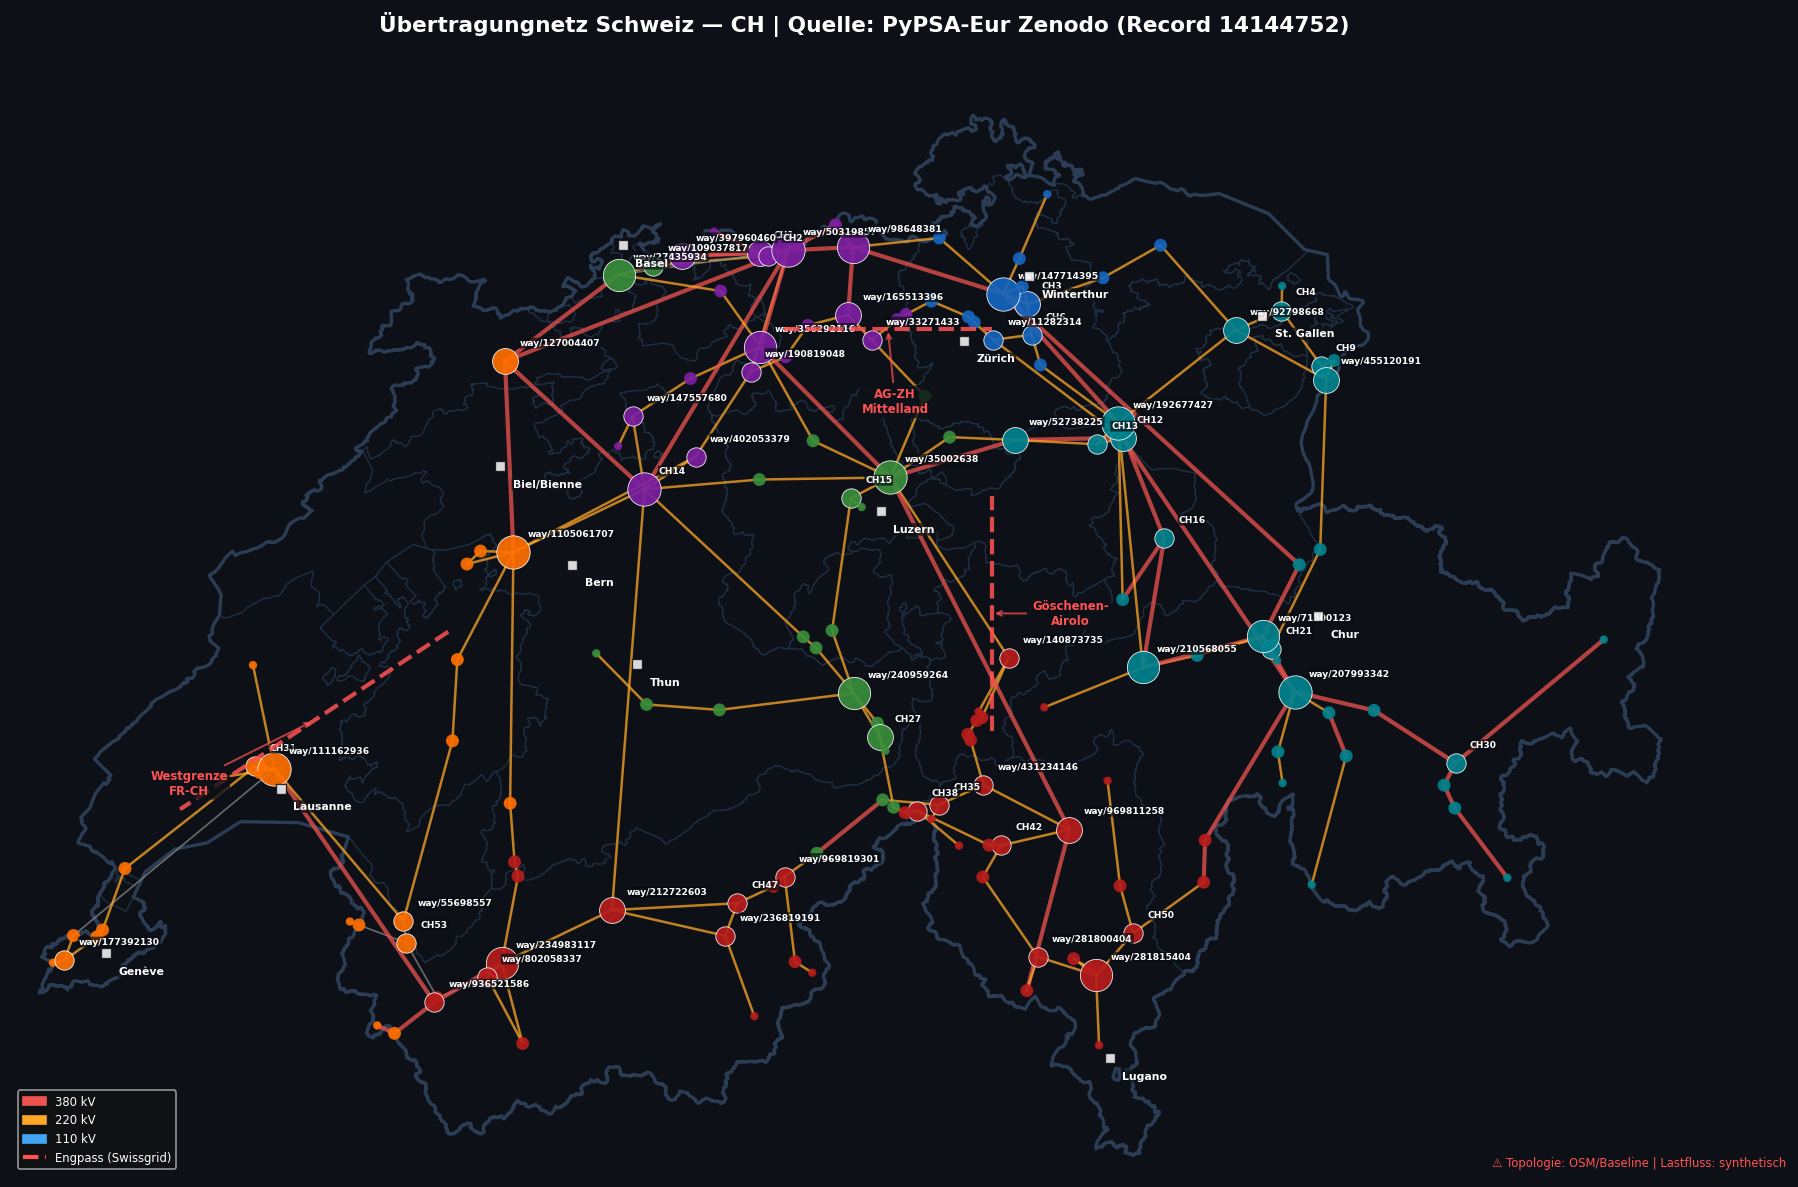


Stromnetz-Topologie der Schweiz mit Generatoren, Leitungen und Engpässen



In [208]:
# ── Ausgabe anzeigen ────────────────────────────────────────────
show_chart(f'EXP_kuer_k01d_{CC_CODE.lower()}_netz_statisch.png',
           'Stromnetz-Topologie der Schweiz mit Generatoren, Leitungen und Engpässen',
           width=900, charts_dir=EXP_CHARTS_DIR)


**Statische Netzwerkkarte CH**

Übertragungnetz CH. Leitungen: 380 kV (rot/dick), 220 kV (orange/dünn).
Knoten-Grösse = Netzgrad (wichtige Hubs: Beznau, Mettlen, Laufenburg).
Quelle: Echte OSM-Topologie wenn online, Swissgrid-Baseline (27 Knoten) wenn offline.

---
## 4. Fluss-Modell auf Kanten<a id='flow_K_01d'></a>

[↑ Inhaltsverzeichnis](#toc_K_01d)

Synthetisches Lastfluss-Modell: Imbalance pro Zone → Fluss auf kürzestem Pfad im Graph.
Richtung und Intensität variieren saisonal und stündlich — **Richtungsumkehr ist modelliert**.

In [209]:
import numpy as np
from scipy.interpolate import CubicSpline

# Zeitachsen für Animationen
TAG_TIMES  = np.linspace(0, 24, N_FRAMES_TAG,  endpoint=False)
JAHR_TIMES = np.linspace(0, 52, N_FRAMES_JAHR, endpoint=False)
MONAT_KURZ = ['Jan','Feb','Mrz','Apr','Mai','Jun','Jul','Aug','Sep','Okt','Nov','Dez']

# ── Zonen-Imbalance Zeitreihen (aus K_01c-Logik) ─────────────────────────────
HOURS = np.arange(24)
WEEKS = np.arange(52)
SAISONS = ['Winter','Frühling','Sommer','Herbst']

# ══════════════════════════════════════════════════════════════════════════════
# ⚙ ZONENMODELL-WAHL — siehe k01d-overlay-config für den Schalter USE_ZONE_MODEL_K01
# ══════════════════════════════════════════════════════════════════════════════
# Zwei Zonenmodelle werden unterstützt:
#   'K01B' (default, 6 Zonen): Nordost, Ostschweiz, Mitte-Erzeugung, Mitte-Transit, West, Süd
#   'K01'  (erste Festlegung, 5 Zonen): Nord, Mitte, West, Süd, Ost
#
# Der Schalter USE_ZONE_MODEL_K01 steht in der Overlay-Config-Zelle. Ist er auf
# True, werden hier ZONE_PROD_INSTALLED und zone_mapping umgebogen.

# Fallback falls Schalter noch nicht gesetzt (Zelle Overlay-Config noch nicht gelaufen)
try:
    _ZMODEL = 'K01' if USE_ZONE_MODEL_K01 else 'K01B'
except NameError:
    _ZMODEL = 'K01B'

# ── K_01B Produktion & Zonen-Mapping aus xconfig.json (kuer.k01b) ────────────
ZONE_COLORS_K01B    = XCFG['kuer']['k01b']['zone_colors']         # ⚙ kuer.k01b.zone_colors
KANTON_TO_ZONE_K01B = XCFG['kuer']['k01b']['kanton_to_zone']      # ⚙ kuer.k01b.kanton_to_zone

# ── K_01 Zonen-Mapping (5 Zonen) aus xconfig.json (kuer.k01_zonenmodell) ─────
ZONE_COLORS_K01    = XCFG['kuer']['k01_zonenmodell']['zone_colors']
KANTON_TO_ZONE_K01 = XCFG['kuer']['k01_zonenmodell']['kanton_to_zone']

# ── ZONE_PROD_INSTALLED aus echten BFE-Daten (lib.bfe_zonen) ─────────────────
# Beide Modelle (K_01B 6-Zonen, K_01 5-Zonen) aus DENSELBEN BFE-Anlagen,
# nur unterschiedlich gemappt → identische Totals, unterschiedliche Aufteilung.
try:
    _gdf_plants_d = load_bfe_plants(PROD_DATA_DIR)
    _kanton_col = find_col(_gdf_plants_d, 'canton', 'kanton')
    ZONE_PROD_INSTALLED_K01B = aggregate_zone_prod(
        _gdf_plants_d, KANTON_TO_ZONE_K01B,
        kanton_col=_kanton_col,
        kept_ets=('Solar', 'Wasserkraft', 'Kernkraft'),
        collapse_to='Andere',
    )
    ZONE_PROD_INSTALLED_K01 = aggregate_zone_prod(
        _gdf_plants_d, KANTON_TO_ZONE_K01,
        kanton_col=_kanton_col,
        kept_ets=('Solar', 'Wasserkraft', 'Kernkraft'),
        collapse_to='Andere',
    )
    print(f'ZONE_PROD_INSTALLED aus BFE aggregiert ({len(_gdf_plants_d):,} Anlagen):')
    print(f'  K_01B (6 Zonen): {list(ZONE_PROD_INSTALLED_K01B.keys())}')
    print(f'  K_01  (5 Zonen): {list(ZONE_PROD_INSTALLED_K01.keys())}')
except FileNotFoundError as e:
    raise RuntimeError(
        f'❌ BFE-Daten fehlen: {e}\n'
        f'   K_01d benötigt bfe_produktionsanlagen.gpkg in {PROD_DATA_DIR}.\n'
        f'   Bitte zuerst Pflicht-NB K_01 (Räumliche Analyse) ausführen.'
    )

# ── Aktive Auswahl je nach Schalter ──────────────────────────────────────────
if _ZMODEL == 'K01':
    ZONE_PROD_INSTALLED = ZONE_PROD_INSTALLED_K01
    ZONE_COLORS_ACTIVE  = ZONE_COLORS_K01
    KANTON_TO_ZONE_B    = KANTON_TO_ZONE_K01
else:
    ZONE_PROD_INSTALLED = ZONE_PROD_INSTALLED_K01B
    ZONE_COLORS_ACTIVE  = ZONE_COLORS_K01B
    KANTON_TO_ZONE_B    = KANTON_TO_ZONE_K01B

# ── In CC-Struktur (Config) überschreiben damit Downstream-Code es findet ────
CC['zone_mapping'] = KANTON_TO_ZONE_B
CC['zone_colors']  = ZONE_COLORS_ACTIVE

# ── Capacity Factors aus xconfig.json (kuer.k01_kapazitaetsfaktoren) ──────────
_cf_x = XCFG['kuer']['k01_kapazitaetsfaktoren']
CF          = dict(_cf_x['jahresdurchschnitt'])  # ⚙ kuer.k01_kapazitaetsfaktoren.jahresdurchschnitt
CF_SEASONAL = dict(_cf_x['saisonal'])            # ⚙ kuer.k01_kapazitaetsfaktoren.saisonal

# Defensive Ergänzung: 'Andere' (für Wind/Biomasse/Erdgas/Geothermie/Erdöl/Kohle-Aggregat)
# Falls in xconfig nicht vorhanden — vermeidet KeyError bei BFE-Zonen mit 'Andere'-Anteil.
CF.setdefault('Andere', 0.40)
CF_SEASONAL.setdefault('Andere', {'Winter': 1.10, 'Frühling': 1.00, 'Sommer': 0.85, 'Herbst': 1.00})
KANTON_POP = {
    'ZH':1593583,'BE':1065607,'LU':433654,'UR':37208,'SZ':165539,'OW':39028,
    'NW':43921,'GL':40590,'ZG':130426,'FR':340765,'SO':279375,'BS':183709,
    'BL':297025,'SH':86928,'AR':58050,'AI':16293,'SG':530468,'GR':202461,
    'AG':718084,'TG':295373,'TI':358353,'VD':826400,'VS':357043,'NE':177589,
    'GE':511655,'JU':73584,
}
zone_pop = {}
for k, z in KANTON_TO_ZONE_B.items():
    zone_pop[z] = zone_pop.get(z,0) + KANTON_POP.get(k,0)
SPEZ_KW = XCFG['kuer']['k01b']['spez_kw_person']  # ⚙ kuer.k01b.spez_kw_person

ZONE_BASE_CONS = {z: pop * SPEZ_KW / 1000 for z, pop in zone_pop.items()}

# ── Zeitprofile ───────────────────────────────────────────────────────────────
def solar_h(h): return max(0.0, float(np.sin(np.pi*(h-6.0)/13.0)))
def hydro_h(h): return float(1.0 + 0.22*np.exp(-((h-10.5)**2)/14) + 0.18*np.exp(-((h-19.0)**2)/10))
def cons_h(h, sais):
    s = {'Winter':1.15,'Frühling':1.00,'Sommer':0.87,'Herbst':1.02}.get(sais,1.0)
    return s*(1.0 + 0.38*np.exp(-((h-8.5)**2)/4.5) + 0.44*np.exp(-((h-19.0)**2)/5.0) - 0.28*np.exp(-((h-4.0)**2)/3.0))

def solar_w(w): return 0.12 + 0.10*np.sin(2*np.pi*(w-12)/52)
def hydro_w(w): return 0.38 + 0.14*np.sin(2*np.pi*(w-15)/52)
def nuclear_w(w): return 0.79 - 0.05*np.sin(2*np.pi*(w-26)/52)
def cons_w(w):    return 1.00 - 0.14*np.sin(2*np.pi*(w-12)/52)

# ══════════════════════════════════════════════════════════════════════════════
# Produktion und Verbrauch getrennt — pro Zone und für ganze Schweiz
# ══════════════════════════════════════════════════════════════════════════════
# BISHER wurde in den Overlays der Verbrauch auf fix 7500 MW gesetzt und die
# Produktion als `7500 + Saldo` rekonstruiert. Das war eine grobe Approximation
# und für den Tagesverlauf schlicht falsch (Verbrauch ist im Tagesverlauf stark
# variabel: ca. 5500 MW Nacht, 9500 MW Abendspitze).
#
# Jetzt rechnen wir beide Grössen direkt aus den ZONE_PROD_INSTALLED × CF ×
# cons_h(h,sais)-Formeln — konsistent mit dem zone_imb_h-Modell.

def zone_produktion_h(zone, h, sais):
    """Produktion einer Zone zur Stunde h in saison [MW]."""
    return sum(inst * CF[et] * CF_SEASONAL[et][sais]
               * (solar_h(h) if et=='Solar' else (hydro_h(h) if et=='Wasserkraft' else 1.0))
               for et, inst in ZONE_PROD_INSTALLED.get(zone,{}).items())

def zone_verbrauch_h(zone, h, sais):
    """Verbrauch einer Zone zur Stunde h in saison [MW]."""
    return ZONE_BASE_CONS.get(zone, 500) * cons_h(h, sais)

def zone_imb_h(zone, h, sais):
    """Imbalance (Produktion - Verbrauch) einer Zone [MW]."""
    return zone_produktion_h(zone, h, sais) - zone_verbrauch_h(zone, h, sais)

def zone_produktion_w(zone, w):
    """Produktion einer Zone zur Woche w (Jahres-Profil) [MW]."""
    return sum(inst * (solar_w(w) if et=='Solar'
                       else (hydro_w(w) if et=='Wasserkraft' else nuclear_w(w)))
               for et, inst in ZONE_PROD_INSTALLED.get(zone,{}).items())

def zone_verbrauch_w(zone, w):
    return ZONE_BASE_CONS.get(zone, 500) * cons_w(w)

def zone_imb_w(zone, w):
    return zone_produktion_w(zone, w) - zone_verbrauch_w(zone, w)

# ── CH-Aggregate — für Overlay-Display ───────────────────────────────────────
def ch_produktion_h(h, sais):
    return sum(zone_produktion_h(z, h, sais) for z in ZONE_PROD_INSTALLED)

def ch_verbrauch_h(h, sais):
    return sum(zone_verbrauch_h(z, h, sais) for z in ZONE_PROD_INSTALLED)

def ch_produktion_w(w):
    return sum(zone_produktion_w(z, w) for z in ZONE_PROD_INSTALLED)

def ch_verbrauch_w(w):
    return sum(zone_verbrauch_w(z, w) for z in ZONE_PROD_INSTALLED)

# ── Produktion nach Energieträger (für Balkendiagramm) ──────────────────────
def ch_produktion_by_type_h(h, sais):
    """CH Produktion aufgesplittet nach Energieträger {Solar, Wasserkraft, Kernkraft, Andere} [MW]."""
    result = {'Solar':0.0, 'Wasserkraft':0.0, 'Kernkraft':0.0, 'Andere':0.0}
    for zone, anlagen in ZONE_PROD_INSTALLED.items():
        for et, inst in anlagen.items():
            factor = CF[et] * CF_SEASONAL[et][sais]
            if et == 'Solar':
                factor *= solar_h(h)
            elif et == 'Wasserkraft':
                factor *= hydro_h(h)
            # Kernkraft + Andere: Grundlast, nur CF_SEASONAL
            result[et] = result.get(et, 0.0) + inst * factor
    return result

def ch_produktion_by_type_w(w):
    result = {'Solar':0.0, 'Wasserkraft':0.0, 'Kernkraft':0.0, 'Andere':0.0}
    for zone, anlagen in ZONE_PROD_INSTALLED.items():
        for et, inst in anlagen.items():
            if et == 'Solar':
                result[et] = result.get(et, 0.0) + inst * solar_w(w)
            elif et == 'Wasserkraft':
                result[et] = result.get(et, 0.0) + inst * hydro_w(w)
            else:
                # Kernkraft + Andere: nuclear-Profil (= weitgehend flach übers Jahr)
                result[et] = result.get(et, 0.0) + inst * nuclear_w(w)
    return result

# ── Verbrauch nach Zone (für Balkendiagramm) ────────────────────────────────
def ch_verbrauch_by_zone_h(h, sais):
    return {z: zone_verbrauch_h(z, h, sais) for z in ZONE_PROD_INSTALLED}

def ch_verbrauch_by_zone_w(w):
    return {z: zone_verbrauch_w(z, w) for z in ZONE_PROD_INSTALLED}

# ══════════════════════════════════════════════════════════════════════════════
# Diagnose-Ausgabe
# ══════════════════════════════════════════════════════════════════════════════
print(f"✅ Flow-Modell geladen — Zonenmodell '{_ZMODEL}' "
      f"({len(ZONE_PROD_INSTALLED)} Zonen, {sum(sum(a.values()) for a in ZONE_PROD_INSTALLED.values())/1000:.1f} GW installiert)")

print(f"\nImbalance-Test (erste Zone = {list(ZONE_PROD_INSTALLED.keys())[0]}):")
_first = list(ZONE_PROD_INSTALLED.keys())[0]
for sais in SAISONS:
    imb_00 = zone_imb_h(_first, 0, sais)
    imb_12 = zone_imb_h(_first, 12, sais)
    print(f"  {sais}: 00h={imb_00:+.0f} MW, 12h={imb_12:+.0f} MW")

print(f"\nCH Produktion vs Verbrauch (Winter):")
for h in [0, 6, 12, 19]:
    p = ch_produktion_h(h, 'Winter')
    v = ch_verbrauch_h(h, 'Winter')
    print(f"  {h:02d}h:  Produktion {p:.0f} MW  |  Verbrauch {v:.0f} MW  |  Saldo {p-v:+.0f} MW")

print(f"\nJahresverlauf CH gesamt:")
for w in [0, 13, 26, 39]:
    total_w = ch_produktion_w(w) - ch_verbrauch_w(w)
    mn = MONAT_KURZ[int(w/52*12)]
    print(f"  Woche {w+1:02d} ({mn}): {total_w:+.0f} MW (P={ch_produktion_w(w):.0f}, V={ch_verbrauch_w(w):.0f})")


ZONE_PROD_INSTALLED aus BFE aggregiert (329,402 Anlagen):
  K_01B (6 Zonen): ['Mitte-Erzeugung', 'Mitte-Transit', 'Nordost', 'Ostschweiz', 'Süd', 'West']
  K_01  (5 Zonen): ['Mitte', 'Nord', 'Ost', 'Süd', 'West']
✅ Flow-Modell geladen — Zonenmodell 'K01B' (6 Zonen, 29.7 GW installiert)

Imbalance-Test (erste Zone = Mitte-Erzeugung):
  Winter: 00h=+1553 MW, 12h=+1617 MW
  Frühling: 00h=+1762 MW, 12h=+1921 MW
  Sommer: 00h=+1722 MW, 12h=+1921 MW
  Herbst: 00h=+1656 MW, 12h=+1759 MW

CH Produktion vs Verbrauch (Winter):
  00h:  Produktion 7099 MW  |  Verbrauch 7736 MW  |  Saldo -636 MW
  06h:  Produktion 7318 MW  |  Verbrauch 7908 MW  |  Saldo -590 MW
  12h:  Produktion 8202 MW  |  Verbrauch 7940 MW  |  Saldo +263 MW
  19h:  Produktion 7866 MW  |  Verbrauch 11154 MW  |  Saldo -3289 MW

Jahresverlauf CH gesamt:
  Woche 01 (Jan): -111 MW (P=7561, V=7672)
  Woche 14 (Apr): +3846 MW (P=10468, V=6622)
  Woche 27 (Jul): +8112 MW (P=13912, V=5800)
  Woche 40 (Okt): +4155 MW (P=11004, V=6849)


In [210]:
# ── Kantens-Fluss auf Graph (physikalisch vereinfacht) ────────────────────────
# Modell: Nur die Top-N Grad-Hubs pro Zone absorbieren die Zonen-Imbalance.
# Das entspricht der Realität: hochgradige Substations sind die Übergabepunkte
# ans Höchstspannungsnetz. Gleichmässige Verteilung auf ALLE Knoten der Zone
# würde zu kleine Werte pro Knoten liefern → Threshold greift nicht.

def compute_edge_flows(G, zone_fn, cc_cfg,
                       hubs_per_zone=None, threshold=None):
    if hubs_per_zone is None: hubs_per_zone = FLOW_HUBS_PER_ZONE
    if threshold     is None: threshold     = FLOW_THRESHOLD_MW

    zone_imb = {z: zone_fn(z) for z in cc_cfg.get('zone_colors', {}).keys()}

    # Top-N Hubs pro Zone (nach Grad)
    zone_hubs = {}
    for z in zone_imb:
        z_nodes = [(n, G.nodes[n].get('degree', 1))
                   for n, d in G.nodes(data=True) if d.get('zone') == z]
        z_nodes.sort(key=lambda x: -x[1])
        zone_hubs[z] = [n for n, _ in z_nodes[:hubs_per_zone]]

    node_surplus = {}
    for z, hubs in zone_hubs.items():
        if not hubs: continue
        per_hub = zone_imb[z] / len(hubs)
        for h in hubs:
            node_surplus[h] = per_hub

    edge_flow = {(min(u,v), max(u,v)): 0.0 for u, v in G.edges()}
    surplus = [(n, s) for n, s in node_surplus.items() if s >  threshold]
    deficit = [(n, s) for n, s in node_surplus.items() if s < -threshold]

    for s_node, s_mw in surplus:
        for d_node, d_mw in deficit:
            if s_node == d_node: continue
            try:
                path = nx.shortest_path(G, s_node, d_node)
            except nx.NetworkXNoPath:
                continue
            flow = min(abs(s_mw), abs(d_mw)) * 0.3
            for i in range(len(path)-1):
                u, v = path[i], path[i+1]
                key = (min(u, v), max(u, v))
                if u < v:
                    edge_flow[key] = edge_flow.get(key, 0) + flow
                else:
                    edge_flow[key] = edge_flow.get(key, 0) - flow

    return edge_flow


# ══════════════════════════════════════════════════════════════════════════════
# Grenz-Hub-Auto-Detection
# ══════════════════════════════════════════════════════════════════════════════
# Schweizer-Seite der 380/220-kV-Grenzübergänge (Swissgrid-Netzplan):
BORDER_HUB_REF = {
    'DE': (8.05, 47.57),   # Laufenburg / Beznau (380+220 kV → DE)
    'AT': (10.41, 46.77),  # Pradella (380/220 kV → AT, Unterengadin)
    'IT': (9.04, 46.17),   # Soazza / Mendrisio (380 kV → IT)
    'FR': (6.14, 46.22),   # Bois-Tollot (380+220 kV → FR, Genfersee)
}

# Ziel-Punkte der Grenz-Linien (AUSSERHALB CH, weit genug vom Hub für sichtbare Dots):
BORDER_POINTS = {
    'DE': (7.50, 48.10),   # NW von Laufenburg — Baden-Württemberg
    'AT': (11.00, 47.20),  # E von Pradella    — Vorarlberg/Tirol
    'IT': (8.90, 45.50),   # S von Soazza      — Mailand-Richtung
    'FR': (5.30, 46.10),   # W von Bois-Tollot — Annemasse/Lyon-Richtung
}
BORDER_COLORS = {'DE':'#42A5F5','AT':'#EF5350','IT':'#66BB6A','FR':'#FFA726'}
BORDER_WEIGHT = {'DE':0.35,'AT':0.15,'IT':0.30,'FR':0.20}


def _find_border_hub(G_graph, ref_lon, ref_lat, min_degree=2, prefer_kv=380,
                     search_radius_deg=1.20):
    """Grenz-nächsten hoch-grad Knoten zur Ref finden. Radius 1.2° ≈ 130 km."""
    best_node = None
    best_score = float('inf')
    for n, d in G_graph.nodes(data=True):
        deg = d.get('degree', 1)
        if deg < min_degree: continue
        dx = d['lon'] - ref_lon; dy = d['lat'] - ref_lat
        dist = (dx*dx + dy*dy) ** 0.5
        if dist > search_radius_deg: continue
        kv_bonus = 0.3 if d.get('voltage_kv', 0) == prefer_kv else 0
        score = dist / (1 + 0.12 * deg + kv_bonus)
        if score < best_score:
            best_score = score
            best_node  = n
    return best_node


# ══════════════════════════════════════════════════════════════════════════════
# ⚙ MANUELLER OVERRIDE: Falls Auto-Detect nicht den richtigen Hub wählt, hier
# die bus_id direkt setzen (siehe Diagnose-Zelle darunter für Alternativen)
# Beispiel: BORDER_HUB_OVERRIDE = {'AT': 'CH21-380', 'FR': 'way/111162936-220'}
# ══════════════════════════════════════════════════════════════════════════════
BORDER_HUB_OVERRIDE = {
    # 'DE': '...',
    # 'AT': '...',
    # 'IT': '...',
    # 'FR': '...',
}

BORDER_HUB_NODES = {}
print("Grenz-Hub-Auto-Detection (realer Substations-Anker):")
for nb_key, (rlon, rlat) in BORDER_HUB_REF.items():
    if nb_key in BORDER_HUB_OVERRIDE:
        hub = BORDER_HUB_OVERRIDE[nb_key]
        if hub not in G:
            print(f"  ⚠️  Override '{hub}' für {nb_key} nicht im Graph — nutze Auto-Detect")
            hub = _find_border_hub(G, rlon, rlat)
        else:
            print(f"  {nb_key}: OVERRIDE → {hub}")
    else:
        hub = _find_border_hub(G, rlon, rlat)
    BORDER_HUB_NODES[nb_key] = hub
    if hub is not None:
        d = G.nodes[hub]
        dx = d['lon'] - rlon; dy = d['lat'] - rlat
        dist_km = (dx*dx + dy*dy)**0.5 * 111
        label = d.get('display_name') or d.get('name', hub[:12])
        bpx, bpy = BORDER_POINTS[nb_key]
        line_km = ((d['lon']-bpx)**2 + (d['lat']-bpy)**2)**0.5 * 111
        print(f"  {nb_key}: {hub[:30]:30s} → {label:14s} "
              f"({d['lon']:.2f},{d['lat']:.2f}) | {d.get('voltage_kv','?')} kV | "
              f"Grad {d.get('degree','?')} | Hub↔Ref {dist_km:.0f}km | Hub↔Label {line_km:.0f}km")
    else:
        print(f"  {nb_key}: ⚠️  kein Anker gefunden")


def get_border_flows(total_imb_mw):
    return {nb: total_imb_mw * w for nb, w in BORDER_WEIGHT.items()}


print(f"\nEdge-Flow Test Winter 00h (mit {FLOW_HUBS_PER_ZONE} Hubs/Zone, "
      f"threshold {FLOW_THRESHOLD_MW} MW):")
ef = compute_edge_flows(G, lambda z: zone_imb_h(z, 0, 'Winter'), CC)
n_active = sum(1 for v in ef.values() if abs(v) > FLOW_THRESHOLD_MW)
top_flows = sorted(ef.items(), key=lambda x: abs(x[1]), reverse=True)[:6]
print(f"  Aktive Kanten (|Fluss| > {FLOW_THRESHOLD_MW} MW): {n_active} / {len(ef)}")
for edge, flow in top_flows:
    n1_lbl = G.nodes[edge[0]].get('display_name') or edge[0][:14]
    n2_lbl = G.nodes[edge[1]].get('display_name') or edge[1][:14]
    print(f"  {n1_lbl:14s} → {n2_lbl:14s}: {flow:+.0f} MW")


Grenz-Hub-Auto-Detection (realer Substations-Anker):
  DE: way/50319857-400               → way/50319857   (8.05,47.55) | 400 kV | Grad 10 | Hub↔Ref 2km | Hub↔Label 86km
  AT: CH30-380                       → CH30           (9.92,46.57) | 380 kV | Grad 3 | Hub↔Ref 59km | Hub↔Label 139km
  IT: CH50-220                       → CH50           (9.02,46.24) | 220 kV | Grad 3 | Hub↔Ref 9km | Hub↔Label 83km
  FR: CH52-220                       → CH52           (6.12,46.24) | 220 kV | Grad 2 | Hub↔Ref 3km | Hub↔Label 92km

Edge-Flow Test Winter 00h (mit 4 Hubs/Zone, threshold 15 MW):
  Aktive Kanten (|Fluss| > 15 MW): 50 / 204
  way/111162936  → way/936521586 : -2110 MW
  way/234983117  → way/936521586 : +2110 MW
  CH3            → way/147714395 : -1950 MW
  way/35002638   → way/969811258 : -1824 MW
  way/147714395  → way/98648381  : -1428 MW
  way/356292116  → way/50319857  : +1260 MW


In [211]:
# ══════════════════════════════════════════════════════════════════════════════
# 🔍 Grenz-Hub-Diagnose
# ══════════════════════════════════════════════════════════════════════════════
# Diese Zelle validiert die Hub-Auswahl aus der vorherigen Zelle. Sie zeigt:
#   Teil 1: Pro Nachbarland die 5 nächsten CH-Knoten zum Referenzpunkt
#           → so kannst du prüfen, ob der Auto-Detect den besten Kandidaten nimmt
#   Teil 2: Pro gewähltem Hub die Nachbarschaft im 40-km-Umkreis
#           → so kannst du beurteilen, ob es plausibel ein Haupt-Substation ist
#
# Falls ein Hub-Kandidat nicht passt: bus_id in `BORDER_HUB_OVERRIDE` (Zelle
# oben) eintragen, dann die Zellen neu ausführen.

KNOWN_REF = {
    'DE': ('Laufenburg',   8.05, 47.57),
    'AT': ('Pradella',    10.41, 46.77),
    'IT': ('Soazza',       9.04, 46.17),
    'FR': ('Bois-Tollot',  6.14, 46.22),
}

# ── Teil 1: Top-5 CH-Knoten pro Referenz-Grenzknoten ─────────────────────────
print("="*95)
print("🔍  Teil 1:  5 nächste CH-Graph-Knoten zu jeder bekannten Grenz-Referenz")
print("="*95)

for nb_key, (ref_name, rlon, rlat) in KNOWN_REF.items():
    print(f"\n▶ {nb_key}   Ref: {ref_name:<13s} @ ({rlon:.3f}, {rlat:.3f})")
    # Alle Knoten nach Distanz sortieren
    cand = []
    for n, d in G.nodes(data=True):
        dx = d['lon'] - rlon
        dy = d['lat'] - rlat
        dkm = (dx*dx + dy*dy)**0.5 * 111
        cand.append((n, d, dkm))
    cand.sort(key=lambda x: x[2])

    auto = BORDER_HUB_NODES.get(nb_key)
    print(f"   {'Rang':<4} {'Node-ID':<32} {'Lon':<7} {'Lat':<7} {'Dist':<7} {'kV':<4} {'Grad':<5} Marker")
    print(f"   {'-'*4:<4} {'-'*32:<32} {'-'*7:<7} {'-'*7:<7} {'-'*7:<7} {'-'*4:<4} {'-'*5:<5} {'-'*10}")
    for i, (n, d, dkm) in enumerate(cand[:5]):
        marker = ''
        if n == auto: marker += '← AUTO '
        kant = d.get('kanton', '--')
        marker += f"({kant})"
        print(f"   #{i+1:<3} {n[:30]:<32} {d['lon']:<7.3f} {d['lat']:<7.3f} "
              f"{dkm:<7.1f} {d.get('voltage_kv','?'):<4} {d.get('degree','?'):<5} {marker}")

# ── Teil 2: Nachbarschaft der gewählten Hubs prüfen ──────────────────────────
NACHBAR_RADIUS_KM = 40
print(f"\n\n{'='*95}")
print(f"🔍  Teil 2:  Nachbarschaft im {NACHBAR_RADIUS_KM}-km-Umkreis der gewählten Hubs")
print("="*95)

for nb_key, hub in BORDER_HUB_NODES.items():
    if hub is None:
        print(f"\n▶ {nb_key}: KEIN Hub gesetzt"); continue
    hd = G.nodes[hub]
    print(f"\n▶ {nb_key}  Hub: {hub}")
    print(f"   @ ({hd['lon']:.3f}, {hd['lat']:.3f}) | {hd.get('voltage_kv','?')} kV | "
          f"Grad={hd.get('degree','?')} | Kanton={hd.get('kanton','--')} | "
          f"Zone={hd.get('zone','--')}")

    # 2a: Direkte Graph-Nachbarn
    direct = list(G.neighbors(hub))
    print(f"   └─ Direkt verbundene Kanten ({len(direct)}):")
    for nb in direct[:8]:
        nd = G.nodes[nb]
        edge_kv = G.edges[hub, nb].get('voltage_kv', '?')
        dx = nd['lon'] - hd['lon']; dy = nd['lat'] - hd['lat']
        edgelen = (dx*dx + dy*dy)**0.5 * 111
        print(f"       {nb[:30]:<32} @ ({nd['lon']:.3f},{nd['lat']:.3f}) "
              f"| {edge_kv:>3} kV Leitung | {edgelen:5.0f} km | "
              f"Grad {nd.get('degree','?')}")
    if len(direct) > 8:
        print(f"       … + {len(direct)-8} weitere")

    # 2b: Alle Graph-Knoten im Umkreis (Nachbarschaft)
    nearby = []
    for n, d in G.nodes(data=True):
        if n == hub: continue
        dx = d['lon'] - hd['lon']; dy = d['lat'] - hd['lat']
        dkm = (dx*dx + dy*dy)**0.5 * 111
        if dkm < NACHBAR_RADIUS_KM:
            nearby.append((n, d, dkm))
    nearby.sort(key=lambda x: x[2])
    n_380 = sum(1 for _, d, _ in nearby if d.get('voltage_kv') == 380)
    n_220 = sum(1 for _, d, _ in nearby if d.get('voltage_kv') == 220)
    print(f"   └─ Im {NACHBAR_RADIUS_KM}-km-Umkreis: {len(nearby)} Knoten  "
          f"(380kV: {n_380}, 220kV: {n_220})")
    # Top-3 grad-starke Alternativen
    alt = sorted(nearby, key=lambda x: (-x[1].get('degree', 1), x[2]))[:3]
    if alt:
        print(f"   └─ Top-3 Alternativ-Hubs (nach Grad):")
        for n, d, dkm in alt:
            flag = '⭐' if d.get('voltage_kv') == 380 and d.get('degree', 1) >= hd.get('degree', 1) else ''
            print(f"       {n[:30]:<32} @ ({d['lon']:.3f},{d['lat']:.3f}) "
                  f"| {d.get('voltage_kv','?'):>3} kV | Grad {d.get('degree','?'):<2} "
                  f"| {dkm:5.0f} km {flag}")

print(f"\n{'='*95}")
print("💡 Um einen anderen Hub zu wählen: bus_id in `BORDER_HUB_OVERRIDE` (Zelle oben)")
print("   eintragen, dann diese Zelle + Diagnose + Helpers + GIF-Zellen neu ausführen.")
print("="*95)


🔍  Teil 1:  5 nächste CH-Graph-Knoten zu jeder bekannten Grenz-Referenz

▶ DE   Ref: Laufenburg    @ (8.050, 47.570)
   Rang Node-ID                          Lon     Lat     Dist    kV   Grad  Marker
   ---- -------------------------------- ------- ------- ------- ---- ----- ----------
   #1   way/50319857-400                 8.051   47.550  2.2     400  10    ← AUTO (AG)
   #2   CH2-220                          7.996   47.540  6.9     220  3     (AG)
   #3   CH1-220                          7.971   47.545  9.2     220  4     (BL)
   #4   way/35840165-380                 8.183   47.599  15.2    380  2     (AG)
   #5   way/89405664-220                 8.106   47.406  19.2    220  2     (AG)

▶ AT   Ref: Pradella      @ (10.410, 46.770)
   Rang Node-ID                          Lon     Lat     Dist    kV   Grad  Marker
   ---- -------------------------------- ------- ------- ------- ---- ----- ----------
   #1   relation/7933294-380             10.332  46.805  9.5     380  1     (GR)
   #

In [212]:
# ── Vorberechnete Kanten-Normierung (per_edge Modus) ─────────────────────────
# Berechnet Ø |flow| je Kante über alle Saisons + Stunden → stabile Normierung
# Einmalig vor GIF-Erstellung, dann als EDGE_NORMS dict verfügbar
import numpy as _np_en

print("Berechne EDGE_NORMS (per_edge Normierung)...", end=' ')
_sample_hours = _np_en.linspace(0, 24, 12, endpoint=False)
_edge_flow_acc = {k: [] for k in compute_edge_flows(
    G, lambda z: zone_imb_h(z, 12, 'Sommer'), CC).keys()}

for _saison in SAISONS:
    for _h in _sample_hours:
        _ef = compute_edge_flows(G, lambda z: zone_imb_h(z, _h, _saison), CC)
        for k, v in _ef.items():
            if k in _edge_flow_acc:
                _edge_flow_acc[k].append(abs(v))

EDGE_NORMS = {}
for k, vals in _edge_flow_acc.items():
    EDGE_NORMS[k] = max(float(_np_en.mean(vals)) if vals else 0, GIF_D_MIN_MW * 2)

# Globalwert für Border
_all_norms = [v for v in EDGE_NORMS.values() if v > 0]
BORDER_NORM_D = max(float(_np_en.mean(_all_norms)) if _all_norms else GIF_D_MW_NORM_GLOBAL, 100)

n_active = sum(1 for v in EDGE_NORMS.values() if v > GIF_D_MIN_MW)
print(f"OK — {len(EDGE_NORMS)} Kanten | {n_active} aktiv | Ø={BORDER_NORM_D:.0f} MW")


Berechne EDGE_NORMS (per_edge Normierung)... OK — 204 Kanten | 204 aktiv | Ø=224 MW


---
## 5. GIF A — Tagesfluss auf Leitungen<a id='gif_a_K_01d'></a>

[↑ Inhaltsverzeichnis](#toc_K_01d)

Moving Dots auf echten Leitungspfaden. Dot-Dichte & Grösse = MW-Fluss. 4 GIFs (je Jahreszeit) × 24 Frames.

**🔎 Quellcode der importierten lib-Funktion**

Die Funktion `should_skip` wird aus `lib/plotting.py` importiert und ab
dieser Stelle im Notebook verwendet (intern in `make_gif_*`). Steuerung
über `sync/config.json` → `animation.modus` und `animation.overrides`.
Aufklappbar darunter ist der Quellcode einsehbar — ohne die `lib/`-Datei
öffnen zu müssen.


In [213]:
show_source(should_skip)


<details>
<summary>🔎 Quellcode: <code>should_skip</code> (aus <code>lib/plotting.py</code>)</summary>

```python
def should_skip(
    out_path: str,
    asset_type: str,
    name: str,
    cfg: dict[str, Any],
) -> bool:
    """Prüft anhand der Config, ob ein Chart/GIF neu erzeugt werden muss.

    Wird in jeder Zelle genutzt, die ein rechenintensives Artefakt erzeugt.
    Schema der relevanten Config-Sektion (in ``sync/config.json``):

    .. code-block:: json

        "animation": {
            "modus":          "skip_if_exists",
            "modus_statisch": "always",
            "overrides": {
                "kuer_k01_karte_verbraucher": "skip_if_exists"
            }
        }

    Entscheidungsreihenfolge
    ------------------------
    1. ``overrides[name]`` — explizit gesetzter Wert (höchste Priorität)
    2. ``asset_type == 'animation'`` → ``cfg['animation']['modus']``
       (Default: ``'skip_if_exists'``)
    3. ``asset_type == 'statisch'`` → ``cfg['animation']['modus_statisch']``
       (Default: ``'always'``). Wert ``'skip_if_exists_all'`` schaltet
       alle statischen Charts auf skip_if_exists um (Master-Schalter).

    Mode-Werte
    ----------
    * ``'skip_if_exists'``  — skip wenn Datei existiert und nicht leer
    * ``'always'``          — nie skip (Datei wird immer überschrieben)
    * ``'force_rebuild'``   — Alias für ``'always'``

    Parameter
    ---------
    out_path : str
        Zielpfad des zu erzeugenden Artefakts.
    asset_type : str
        Entweder ``'animation'`` oder ``'statisch'``.
    name : str
        Basename des Artefakts (ohne Extension), für ``overrides``-Lookup.
        Beispiel: ``'kuer_k04_anim_A_18h'``.
    cfg : dict
        Geladenes CFG-Dict aus ``sync/config.json``.

    Rückgabe
    --------
    bool
        ``True`` wenn die Erzeugung übersprungen werden kann, sonst ``False``.

    Beispiel
    --------
    >>> out = os.path.join(CHARTS_DIR, 'kuer_k04_anim_A_18h.gif')
    >>> if should_skip(out, 'animation', 'kuer_k04_anim_A_18h', CFG):
    ...     print(f"✓ Überspringe (existiert)")
    ... else:
    ...     make_gif_chart(...)
    """
    if asset_type not in ("animation", "statisch"):
        raise ValueError(
            f"asset_type muss 'animation' oder 'statisch' sein, "
            f"nicht {asset_type!r}"
        )

    anim_cfg = cfg.get("animation", {})
    overrides = anim_cfg.get("overrides", {})

    # 1. Explizit gesetzter Override (Keys mit _ sind Hinweis-Felder)
    if name in overrides and not name.startswith("_"):
        mode = overrides[name]
    # 2. Global je Asset-Typ
    elif asset_type == "animation":
        mode = anim_cfg.get("modus", "skip_if_exists")
    else:  # 'statisch'
        global_static = anim_cfg.get("modus_statisch", "always")
        # Master-Schalter: schaltet ALLE statischen Charts auf skip_if_exists
        if global_static == "skip_if_exists_all":
            mode = "skip_if_exists"
        else:
            mode = global_static

    # Validierung des Mode-Werts (nur informativ, fehlerhafte Werte → 'always')
    valid_modes = {"skip_if_exists", "always", "force_rebuild"}
    if mode not in valid_modes:
        # Nicht hart abbrechen — SSOT-Violation soll loud, aber nicht blockierend
        # sein, damit der Notebook-Lauf nicht an einem Tippfehler hängt.
        import warnings
        warnings.warn(
            f"Unbekannter Modus {mode!r} für {asset_type} '{name}'. "
            f"Erlaubt: {sorted(valid_modes)}. Fallback auf 'always'.",
            RuntimeWarning,
        )
        mode = "always"

    if mode == "skip_if_exists":
        return os.path.exists(out_path) and os.path.getsize(out_path) > 0
    # 'always' oder 'force_rebuild' → immer neu erzeugen
    return False
```

</details>


In [214]:
def _draw_grid_bg(ax):
    """Zeichnet die statischen Topologie-Layer in die gegebene Axes.
    Wird als draw_background-Callback an lib.map_animation.make_gif_fast_map übergeben.
    Alle benötigten Daten (gdf_kant, G, Voltage/Border-Konfig) sind NB-Globals."""
    if gdf_kant is not None:
        # Kantonsgrenzen — deutlicher sichtbar (#2a3d55)
        gdf_kant.boundary.plot(ax=ax, color='#2a3d55', linewidth=0.7, zorder=1)
        # CH-Aussengrenze zusätzlich stärker markieren
        try:
            import geopandas as _gpd
            _ch_outline = _gpd.GeoDataFrame(
                geometry=[gdf_kant.unary_union.boundary], crs='EPSG:4326')
            _ch_outline.plot(ax=ax, color='#3d5470', linewidth=1.4, zorder=1)
        except Exception:
            pass

    # ── Leitungen ───────────────────────────────────────────────────────────
    for n1, n2, data in G.edges(data=True):
        kv  = data.get('voltage_kv', 220)
        x1, y1 = G.nodes[n1]['lon'], G.nodes[n1]['lat']
        x2, y2 = G.nodes[n2]['lon'], G.nodes[n2]['lat']
        if (MAP_XLIM[0]-0.05<=x1<=MAP_XLIM[1]+0.05 and
            MAP_XLIM[0]-0.05<=x2<=MAP_XLIM[1]+0.05 and
            MAP_YLIM[0]-0.05<=y1<=MAP_YLIM[1]+0.05 and
            MAP_YLIM[0]-0.05<=y2<=MAP_YLIM[1]+0.05):
            ax.plot([x1,x2],[y1,y2],
                    color=VOLTAGE_COLORS.get(kv,'#888'),
                    lw=VOLTAGE_LW.get(kv,1)*0.7,
                    alpha=BG_EDGE_ALPHA, zorder=2)

    # ── Knoten ──────────────────────────────────────────────────────────────
    zone_col = CC.get('zone_colors', {})
    for n, data in G.nodes(data=True):
        deg  = data.get('degree', 1)
        zone = data.get('zone', '')
        kv   = data.get('voltage_kv', 220)
        col  = zone_col.get(zone, VOLTAGE_COLORS.get(kv, '#ccc'))
        size = max(12, min(180, deg**2 * 10))
        ax.scatter(data['lon'], data['lat'], s=size, c=col,
                   alpha=BG_NODE_ALPHA, zorder=8,
                   linewidths=0.4 if deg>=3 else 0,
                   edgecolors='white' if deg>=3 else 'none')
        if deg >= 3 and data.get('display_name'):
            ax.text(data['lon']+0.04, data['lat']+0.03,
                    data['display_name'][:14],
                    color='#aaaaaa', fontsize=4.5, zorder=9, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.08', fc='#090d14', alpha=0.6, lw=0))

    # ── Border-Hub-Marker ──────────────────────────────────────────────────
    if BORDER_HUB_MARK:
        for nb_key, hub in BORDER_HUB_NODES.items():
            if hub is None or hub not in G: continue
            hlon = G.nodes[hub]['lon']; hlat = G.nodes[hub]['lat']
            col = BORDER_COLORS[nb_key]
            for r, a in [(350, 0.20), (220, 0.40), (120, 0.75)]:
                ax.scatter(hlon, hlat, s=r, facecolors='none',
                           edgecolors=col, linewidths=2.0, alpha=a, zorder=10)
            ax.text(hlon+0.08, hlat-0.08, f'↔{nb_key}',
                    ha='left', va='top', color=col, fontsize=6.5, fontweight='bold',
                    zorder=10,
                    bbox=dict(boxstyle='round,pad=0.15', fc='#0d1117',
                              ec=col, lw=0.5, alpha=0.85))


# ── Karte + Netz + Schnelles Rendering (gecachter Hintergrund) ───────────────
import io, os, math, numpy as np
from PIL import Image as PILImage
import matplotlib
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

MAP_XLIM = CC['map_xlim']
MAP_YLIM = CC['map_ylim']

TAG_TIMES  = np.linspace(0, 24, N_FRAMES_TAG,  endpoint=False)
JAHR_TIMES = np.linspace(0, 52, N_FRAMES_JAHR, endpoint=False)
MONAT_KURZ = ['Jan','Feb','Mrz','Apr','Mai','Jun','Jul','Aug','Sep','Okt','Nov','Dez']

# ══════════════════════════════════════════════════════════════════════════════
# Geographisch korrekte Figur-Proportion (behebt lat/lon plate-carrée Stretch)
# Bei 46.87°N ist 1° lon ≈ 76km, 1° lat ≈ 111km (Verhältnis 1.46). Eine reine
# 14:8 Figur zieht alles ~16% horizontal auseinander. Korrekt: figsize so dass
# px/km in beide Richtungen gleich ist.
# ══════════════════════════════════════════════════════════════════════════════
FIG_W_IN = 14  # ⚙ Breite fix; Höhe wird aus Geographie berechnet
_lat_mean      = (MAP_YLIM[0] + MAP_YLIM[1]) / 2
_km_per_deg_lon = 111.32 * math.cos(math.radians(_lat_mean))
_km_per_deg_lat = 111.32
_lon_km = (MAP_XLIM[1] - MAP_XLIM[0]) * _km_per_deg_lon
_lat_km = (MAP_YLIM[1] - MAP_YLIM[0]) * _km_per_deg_lat
FIG_H_IN = FIG_W_IN * _lat_km / _lon_km

print(f"📐 Geographisch korrigierte Figur-Proportion:")
print(f"   Mittlere Breite: {_lat_mean:.2f}°N (1° lon = {_km_per_deg_lon:.1f} km)")
print(f"   Ausdehnung: {_lon_km:.0f} × {_lat_km:.0f} km")
print(f"   figsize = ({FIG_W_IN}, {FIG_H_IN:.2f})  → {_lon_km/_km_per_deg_lon*111.32/_lat_km:.3f}× Verhältnis korrekt")

# ── Hintergrund-Cache (als numpy array) ───────────────────────────────────────
_BG_CACHE_D = {}

# ══════════════════════════════════════════════════════════════════════════════
# Pre-Compute + kumulative Phase (fps-normalisiert)
# ══════════════════════════════════════════════════════════════════════════════
def precompute_flow_cache(zone_fn_of_frame, n_frames, fps):
    '''dphase = (flow/mw_norm) * PHASE_ROT_PER_SEC_AT_MAX / fps'''
    print("  ⏳ Pre-Compute Fluss-Cache...", end=' ', flush=True)

    edge_flows_by_frame = []
    total_by_frame = np.zeros(n_frames)
    for fi in range(n_frames):
        z_imb = zone_fn_of_frame(fi)
        ef = compute_edge_flows(G, z_imb, CC)
        edge_flows_by_frame.append(ef)
        total_by_frame[fi] = sum(z_imb(z) for z in CC.get('zone_colors', {}).keys())

    border_flows_by_frame = [get_border_flows(t) for t in total_by_frame]

    PHASE_STEP = PHASE_ROT_PER_SEC_AT_MAX / fps

    edge_keys = list(edge_flows_by_frame[0].keys()) if edge_flows_by_frame else []
    edge_phases = {k: np.zeros(n_frames) for k in edge_keys}
    edge_norms_used = {}
    for k in edge_keys:
        if GIF_D_NORM_MODE == 'per_edge':
            mw_norm = EDGE_NORMS.get(k, GIF_D_MW_NORM_GLOBAL)
        else:
            mw_norm = GIF_D_MW_NORM_GLOBAL
        edge_norms_used[k] = mw_norm
        phase = 0.0
        for fi in range(n_frames):
            flow = edge_flows_by_frame[fi].get(k, 0.0)
            phase += (flow / mw_norm) * PHASE_STEP
            edge_phases[k][fi] = phase

    border_norm = BORDER_NORM_D if GIF_D_NORM_MODE == 'per_edge' else GIF_D_MW_NORM_GLOBAL
    border_phases = {nb: np.zeros(n_frames) for nb in BORDER_HUB_NODES.keys()}
    for nb in border_phases:
        phase = 0.0
        for fi in range(n_frames):
            flow = border_flows_by_frame[fi].get(nb, 0.0)
            phase += (flow / border_norm) * PHASE_STEP
            border_phases[nb][fi] = phase

    print(f"OK ({n_frames}f × {len(edge_keys)} Kanten + {len(border_phases)} Border | "
          f"Phase-Step={PHASE_STEP:.4f}/frame)")
    return {
        'edge_flows_by_frame':   edge_flows_by_frame,
        'edge_phases':           edge_phases,
        'edge_norms':            edge_norms_used,
        'border_flows_by_frame': border_flows_by_frame,
        'border_phases':         border_phases,
        'border_norm':           border_norm,
        'total_by_frame':        total_by_frame,
    }


def draw_flow_dots_on_edge(ax, n1, n2, mw_flow, phase, mw_norm=None, min_mw=None):
    if min_mw is None: min_mw = GIF_D_MIN_MW
    if abs(mw_flow) < min_mw: return
    x1,y1 = G.nodes[n1]['lon'], G.nodes[n1]['lat']
    x2,y2 = G.nodes[n2]['lon'], G.nodes[n2]['lat']
    kv    = G.edges[n1,n2].get('voltage_kv', 220) if G.has_edge(n1,n2) else 220
    col   = VOLTAGE_COLORS.get(kv, '#FFA726')

    if mw_norm is None:
        edge_key = (min(n1,n2), max(n1,n2))
        mw_norm = (EDGE_NORMS.get(edge_key, GIF_D_MW_NORM_GLOBAL)
                   if GIF_D_NORM_MODE == 'per_edge' else GIF_D_MW_NORM_GLOBAL)

    rel_flow = abs(mw_flow) / mw_norm
    n_dots   = max(1, min(6, int(rel_flow * GIF_D_N_DOTS_BASE) + 1))

    # Fixes Dot-Spacing: Dot #i liegt bei (phase + i/N_MAX) — unabhängig von n_dots.
    # Früher: i/n_dots → wenn n_dots sprunghaft wechselt, springen ALLE Dots.
    # Jetzt: Dots erscheinen/verschwinden nur am Ende, keine Positions-Sprünge.
    N_MAX = 6
    p1 = np.array([x1, y1]); p2 = np.array([x2, y2])
    for i in range(n_dots):
        t   = (phase + i/N_MAX) % 1.0
        pos = p1 + t*(p2-p1)
        ax.scatter(*pos, s=GIF_D_DOT_SIZE, c=col,
                   alpha=0.90, zorder=12, linewidths=0, rasterized=True)

    if GIF_D_SHOW_LABEL and abs(mw_flow) > mw_norm * 0.3:
        mid = (p1+p2)/2
        ax.text(mid[0], mid[1]+0.03, f'{abs(mw_flow):.0f}',
                ha='center', va='bottom', color=col, fontsize=4, zorder=14,
                bbox=dict(boxstyle='round,pad=0.04', fc='#090d14', alpha=0.6, lw=0))


def draw_border_flow_d(ax, nb_key, mw, phase, mw_norm=None):
    if abs(mw) < GIF_D_MIN_MW: return
    if mw_norm is None:
        mw_norm = BORDER_NORM_D if GIF_D_NORM_MODE == 'per_edge' else GIF_D_MW_NORM_GLOBAL

    bl, ba = BORDER_POINTS[nb_key]
    anchor = BORDER_HUB_NODES.get(nb_key)
    if anchor and anchor in G:
        ax_lon, ax_lat = G.nodes[anchor]['lon'], G.nodes[anchor]['lat']
    else:
        ax_lon, ax_lat = (MAP_XLIM[0]+MAP_XLIM[1])/2, (MAP_YLIM[0]+MAP_YLIM[1])/2

    col = BORDER_COLORS[nb_key]
    rel_flow = abs(mw) / mw_norm
    n_dots   = max(1, min(4, int(rel_flow * GIF_D_N_DOTS_BASE)))

    N_MAX = 4
    p1 = np.array([ax_lon, ax_lat]); p2 = np.array([bl, ba])
    for i in range(n_dots):
        t   = (phase + i/N_MAX) % 1.0
        pos = p1 + t*(p2-p1)
        ax.scatter(*pos, s=GIF_D_DOT_SIZE*0.8, c=col,
                   alpha=0.90, zorder=11, linewidths=0, rasterized=True)

    ax.plot([ax_lon, bl], [ax_lat, ba], color=col, lw=0.7, alpha=0.35,
            zorder=4, linestyle='--')
    ax.text(bl, ba+0.10, f"{nb_key}\n{mw:+.0f}MW",
            ha='center', va='bottom', color=col, fontsize=5, fontweight='bold',
            zorder=15, bbox=dict(boxstyle='round,pad=0.1', fc='#090d14', alpha=0.75, lw=0))


def add_timestamp_bar_d(ax, label_left, label_center, label_right):
    xspan = MAP_XLIM[1]-MAP_XLIM[0]; yspan = MAP_YLIM[1]-MAP_YLIM[0]
    ax.text(MAP_XLIM[0]+0.01*xspan, MAP_YLIM[1]-0.02*yspan,
            label_left, ha='left', va='top', color='#aaa', fontsize=8, zorder=20)
    ax.text(MAP_XLIM[0]+0.5*xspan,  MAP_YLIM[1]-0.02*yspan,
            label_center, ha='center', va='top', color='white', fontsize=10,
            fontweight='bold', zorder=20)
    ax.text(MAP_XLIM[1]-0.01*xspan, MAP_YLIM[1]-0.02*yspan,
            label_right, ha='right', va='top', color='#ff5252', fontsize=7, zorder=20)


# ══════════════════════════════════════════════════════════════════════════════
# Overlay-Renderer — liest OVERLAYS-Dict (gesetzt in k01d-overlay-config)
# Alle Overlays unten-ausgerichtet in Axes-Fraction → überdecken keine Daten.
# ══════════════════════════════════════════════════════════════════════════════
def _ov(key, default=None):
    '''Liefert Overlay-Config mit Default-Fallback falls OVERLAYS nicht definiert.'''
    try:
        return OVERLAYS.get(key, default or {})
    except NameError:
        return default or {}

def draw_overlay_legende_spannung(ax):
    '''Legende: farbcodierte Spannungsebenen (kV).
    Nutzt matplotlib-Linien + Text für echte Farb-Kodierung pro Zeile.'''
    cfg = _ov('legende_spannung')
    if not cfg.get('enabled', False): return
    px, py = cfg.get('pos', (0.01, 0.01))
    ha, va = cfg.get('align', ('left', 'bottom'))
    fs     = cfg.get('size', 6.5)
    title  = cfg.get('title', 'Spannung')

    n       = len(LEGEND_KV_LEVELS)
    row_h   = fs * 0.0022   # Zeilen-Höhe in Axes-Fraction (empirisch für typische fig-size)
    box_w   = fs * 0.0140   # Box-Breite in Axes-Fraction
    # Hintergrund-Box als Rechteck (via matplotlib.patches)
    import matplotlib.patches as _mpatches
    pad    = row_h * 0.6
    box_h  = (n + 1) * row_h * 1.25 + 2*pad

    if va == 'bottom':
        by_top    = py + box_h
        by_bottom = py
    elif va == 'top':
        by_top    = py
        by_bottom = py - box_h
    else:  # center
        by_top    = py + box_h/2
        by_bottom = py - box_h/2

    if ha == 'left':
        bx_left  = px
        bx_right = px + box_w
    elif ha == 'right':
        bx_left  = px - box_w
        bx_right = px
    else:
        bx_left  = px - box_w/2
        bx_right = px + box_w/2

    rect = _mpatches.FancyBboxPatch(
        (bx_left, by_bottom), box_w, box_h,
        boxstyle='round,pad=0.002,rounding_size=0.005',
        transform=ax.transAxes, fc='#0d1117', ec='#2a3d55', lw=0.7,
        alpha=0.85, zorder=25)
    ax.add_patch(rect)

    # Titel
    title_y = by_top - pad - row_h * 0.6
    ax.text(bx_left + pad, title_y, title,
            transform=ax.transAxes, ha='left', va='center',
            fontsize=fs, color='#dddddd', fontweight='bold', zorder=26)

    # kV-Zeilen mit farbigem Linien-Swatch links
    for i, kv in enumerate(LEGEND_KV_LEVELS):
        y = title_y - (i+1) * row_h * 1.3
        col = VOLTAGE_COLORS.get(kv, '#888')
        # Farbiger Balken
        swatch_w = box_w * 0.25
        ax.plot([bx_left + pad, bx_left + pad + swatch_w], [y, y],
                color=col, lw=2.2, transform=ax.transAxes,
                solid_capstyle='round', zorder=26)
        # Label
        ax.text(bx_left + pad + swatch_w + pad*0.5, y, f'{kv} kV',
                transform=ax.transAxes, ha='left', va='center',
                fontsize=fs, color='#dddddd', family='monospace', zorder=26)

def draw_overlay_legende_dot_mw(ax):
    '''Legende: wieviel MW entspricht wie vielen Dots?'''
    cfg = _ov('legende_dot_mw')
    if not cfg.get('enabled', False): return
    px, py = cfg.get('pos', (0.25, 0.01))
    ha, va = cfg.get('align', ('left', 'bottom'))
    fs     = cfg.get('size', 6.5)
    title  = cfg.get('title', 'Dot-Skala')

    # Rechne wie viele Dots bei welcher MW pro Kante (abhängig von typischem mw_norm)
    typ_norm = GIF_D_MW_NORM_GLOBAL
    lines = [f"━ {title} (@ {typ_norm:.0f} MW/Kante)"]
    for mw in LEGEND_DOT_MW:
        rel = mw / typ_norm
        n_dots = max(1, min(6, int(rel * GIF_D_N_DOTS_BASE) + 1))
        dots = '●' * n_dots
        lines.append(f" {mw:>4} MW  {dots}")
    text = '\n'.join(lines)
    ax.text(px, py, text, transform=ax.transAxes,
            ha=ha, va=va, fontsize=fs, color='#dddddd',
            family='monospace', zorder=25,
            bbox=dict(boxstyle='round,pad=0.35', fc='#0d1117',
                      alpha=0.85, ec='#2a3d55', lw=0.7))


def draw_overlay_ch_saldo(ax, total_mw):
    '''CH-Gesamtsaldo: Produktion minus Verbrauch.'''
    cfg = _ov('ch_saldo')
    if not cfg.get('enabled', False): return
    px, py = cfg.get('pos', (0.5, 0.97))
    ha, va = cfg.get('align', ('center', 'top'))
    fs     = cfg.get('size', 7.5)

    col = '#66BB6A' if total_mw > 0 else '#EF5350'
    label = 'Export' if total_mw > 0 else 'Import'
    ax.text(px, py, f'CH-Saldo: {total_mw:+.0f} MW  ({label})',
            transform=ax.transAxes, ha=ha, va=va,
            fontsize=fs, color='white', fontweight='bold', zorder=25,
            bbox=dict(boxstyle='round,pad=0.3', fc=col, alpha=0.85, lw=0))


def draw_overlay_ch_produktion_verbrauch(ax, produktion_mw, verbrauch_mw):
    '''CH Produktion und Verbrauch getrennt.'''
    cfg = _ov('ch_produktion_verbrauch')
    if not cfg.get('enabled', False): return
    px, py = cfg.get('pos', (0.99, 0.97))
    ha, va = cfg.get('align', ('right', 'top'))
    fs     = cfg.get('size', 6.5)
    txt = (f"▲ Produktion: {produktion_mw:>6.0f} MW\n"
           f"▼ Verbrauch:  {verbrauch_mw:>6.0f} MW")
    ax.text(px, py, txt, transform=ax.transAxes,
            ha=ha, va=va, fontsize=fs, color='#dddddd',
            family='monospace', zorder=25,
            bbox=dict(boxstyle='round,pad=0.3', fc='#0d1117',
                      alpha=0.85, ec='#2a3d55', lw=0.7))


def draw_overlay_grenzen_summen(ax, border_flows):
    '''Import/Export pro Nachbarland aufgeschlüsselt. border_flows: {nb_key: mw}.'''
    cfg = _ov('grenzen_summen')
    if not cfg.get('enabled', False): return
    px, py = cfg.get('pos', (0.01, 0.97))
    ha, va = cfg.get('align', ('left', 'top'))
    fs     = cfg.get('size', 6.5)

    lines = ["━ Grenzflüsse"]
    for nb_key in ['DE', 'FR', 'AT', 'IT']:
        mw = border_flows.get(nb_key, 0)
        arrow = '→' if mw > 0 else '←' if mw < 0 else '·'
        lines.append(f"  {nb_key} {arrow} {abs(mw):>5.0f} MW")
    ax.text(px, py, '\n'.join(lines), transform=ax.transAxes,
            ha=ha, va=va, fontsize=fs, color='#dddddd',
            family='monospace', zorder=25,
            bbox=dict(boxstyle='round,pad=0.3', fc='#0d1117',
                      alpha=0.85, ec='#2a3d55', lw=0.7))


def draw_zonen_imbalance_labels(ax, zone_fn):
    '''Labels pro Zone (am Zentroid). zone_fn: zone_name -> imbalance_mw'''
    cfg = _ov('zonen_imbalance')
    if not cfg.get('enabled', False): return
    fs    = cfg.get('size', 5.5)
    alpha = cfg.get('alpha', 0.65)

    zone_col = CC.get('zone_colors', {})
    for zone, col in zone_col.items():
        z_nodes = [n for n, d in G.nodes(data=True) if d.get('zone') == zone]
        if not z_nodes: continue
        cx = np.mean([G.nodes[n]['lon'] for n in z_nodes])
        cy = np.mean([G.nodes[n]['lat'] for n in z_nodes])
        imb = zone_fn(zone)
        ax.text(cx, cy, f'{imb:+.0f}', ha='center', va='center',
                color='white', fontsize=fs, fontweight='bold', zorder=14,
                bbox=dict(boxstyle='round,pad=0.12', fc=col, alpha=alpha, lw=0))


def draw_all_static_overlays(ax):
    '''Alle statischen Overlays (Legenden) — keine Daten-Abhängigkeit.'''
    draw_overlay_legende_spannung(ax)
    draw_overlay_legende_dot_mw(ax)


# ══════════════════════════════════════════════════════════════════════════════
# Balkendiagramm: Produktion (nach Energieträger) | Verbrauch (nach Zone) | Bilanz
# ══════════════════════════════════════════════════════════════════════════════
# Energieträger-Farben (matplotlib Standard-Farben für Energy-Mix)
ET_COLORS = {
    'Wasserkraft': '#2196F3',  # Blau
    'Kernkraft':   '#9C27B0',  # Violett
    'Solar':       '#FFC107',  # Gelb/Gold
    'Andere':      '#78909C',  # Blaugrau (Wind/Biomasse/Geothermie/Erdgas-Aggregat)
    'Wind':        '#00BCD4',  # Cyan (nicht genutzt aber für Vollständigkeit)
}

def _style_inset(iax, fs, alpha_axes=1.0, with_yaxis=True):
    '''Einheitliches Styling für Inset-Diagramme: transparent + dezente Achsen.
    alpha_axes steuert nur die Sichtbarkeit von Ticks/Labels/Grid (Balken bleiben solide).'''
    iax.set_facecolor('none')        # komplett transparent → Karte scheint durch
    iax.patch.set_alpha(0.0)
    iax.spines['top'].set_visible(False)
    iax.spines['right'].set_visible(False)
    spine_col = (0.6, 0.6, 0.6, alpha_axes)
    iax.spines['bottom'].set_color(spine_col)
    iax.spines['bottom'].set_linewidth(0.5)
    if with_yaxis:
        iax.spines['left'].set_color(spine_col)
        iax.spines['left'].set_linewidth(0.5)
        iax.tick_params(axis='y', labelsize=fs*0.85,
                        colors=(0.85, 0.85, 0.85, alpha_axes),
                        width=0.4, length=2, pad=1)
    else:
        iax.spines['left'].set_visible(False)
        iax.tick_params(axis='y', left=False, labelleft=False)
    iax.tick_params(axis='x', length=0, pad=1,
                    labelsize=fs, colors=(0.85, 0.85, 0.85, alpha_axes))
    iax.grid(axis='y', linestyle=':', color=(0.4, 0.4, 0.4, alpha_axes*0.6),
             linewidth=0.4, zorder=0)


def draw_overlay_balkendiagramm(ax, produktion_by_type, verbrauch_by_zone):
    '''Zwei Balken nebeneinander: Produktion (nach Energieträger) + Verbrauch (nach Zone).
    Bilanz wird SEPARAT gezeichnet (siehe draw_overlay_bilanz). Transparenter
    Hintergrund — die darunterliegende Karte scheint durch.'''
    cfg = _ov('balkendiagramm')
    if not cfg.get('enabled', False): return
    if not produktion_by_type or not verbrauch_by_zone: return

    px, py  = cfg.get('pos', (0.99, 0.85))
    ha, va  = cfg.get('align', ('right', 'top'))
    width   = cfg.get('breite', 0.15)
    height  = cfg.get('hoehe', 0.22)
    fs      = cfg.get('size', 5.5)
    ymax_mw = cfg.get('ymax_mw', 14000)
    alpha   = cfg.get('alpha', 1.0)       # Balken-Deckkraft (nicht Background!)

    # Inset-Position
    if ha == 'right':    ix_l = px - width
    elif ha == 'left':   ix_l = px
    else:                ix_l = px - width/2
    if va == 'top':      iy_b = py - height
    elif va == 'bottom': iy_b = py
    else:                iy_b = py - height/2

    iax = ax.inset_axes([ix_l, iy_b, width, height])
    bar_w = 0.68

    # ── Balken 1: Produktion (stacked nach Energieträger) ──
    p_total = sum(produktion_by_type.values())
    bottom = 0
    for et in ['Wasserkraft', 'Kernkraft', 'Solar', 'Andere']:
        mw = produktion_by_type.get(et, 0)
        if mw > 0:
            iax.bar(0, mw, bar_w, bottom=bottom,
                    color=ET_COLORS.get(et, '#888'),
                    edgecolor='none', linewidth=0, alpha=alpha)
            bottom += mw

    # ── Balken 2: Verbrauch (stacked nach Zone) ──
    v_total = sum(verbrauch_by_zone.values())
    bottom = 0
    zone_col = CC.get('zone_colors', {})
    for zone, mw in sorted(verbrauch_by_zone.items(), key=lambda x: -x[1]):
        if mw > 0:
            iax.bar(1, mw, bar_w, bottom=bottom,
                    color=zone_col.get(zone, '#666'),
                    edgecolor='none', linewidth=0, alpha=alpha)
            bottom += mw

    iax.set_xticks([0, 1])
    iax.set_xticklabels(['Prod.', 'Verbr.'], fontsize=fs)
    iax.set_ylim(0, ymax_mw)
    iax.set_ylabel('MW', fontsize=fs, color='#cccccc', labelpad=2)
    _style_inset(iax, fs, alpha_axes=0.9, with_yaxis=True)

    # Totals über den Balken
    iax.text(0, p_total + ymax_mw*0.02, f'{p_total:.0f}',
             ha='center', va='bottom', fontsize=fs*0.95,
             color='#ffffff', fontweight='bold')
    iax.text(1, v_total + ymax_mw*0.02, f'{v_total:.0f}',
             ha='center', va='bottom', fontsize=fs*0.95,
             color='#ffffff', fontweight='bold')


def draw_overlay_bilanz(ax, bilanz_mw):
    '''Separater Bilanz-Balken: grün nach oben bei Export, rot nach unten bei Import.
    Transparenter Hintergrund wie bei draw_overlay_balkendiagramm.'''
    cfg = _ov('bilanz')
    if not cfg.get('enabled', False): return

    px, py   = cfg.get('pos', (0.03, 0.55))
    ha, va   = cfg.get('align', ('left', 'center'))
    width    = cfg.get('breite', 0.055)
    height   = cfg.get('hoehe', 0.32)
    fs       = cfg.get('size', 5.5)
    ymax_mw  = cfg.get('ymax_mw', 4000)       # eigene Skala für Bilanz (symmetrisch)
    alpha    = cfg.get('alpha', 1.0)

    # Position
    if ha == 'right':    ix_l = px - width
    elif ha == 'left':   ix_l = px
    else:                ix_l = px - width/2
    if va == 'top':      iy_b = py - height
    elif va == 'bottom': iy_b = py
    else:                iy_b = py - height/2

    iax = ax.inset_axes([ix_l, iy_b, width, height])

    col = '#66BB6A' if bilanz_mw > 0 else '#EF5350'
    iax.bar(0, bilanz_mw, 0.7, color=col, edgecolor='none', linewidth=0, alpha=alpha)

    # Nullinie prominent — das ist der zentrale Referenzpunkt
    iax.axhline(0, color='#aaaaaa', linewidth=0.8, zorder=5)

    iax.set_xticks([0])
    iax.set_xticklabels(['Bilanz'], fontsize=fs)
    iax.set_ylim(-ymax_mw, ymax_mw)
    iax.set_ylabel('MW', fontsize=fs, color='#cccccc', labelpad=2)
    _style_inset(iax, fs, alpha_axes=0.9, with_yaxis=True)

    # Value-Label (farbig: grün wenn positiv, rot wenn negativ)
    y_b = bilanz_mw + (ymax_mw*0.04 if bilanz_mw >= 0 else -ymax_mw*0.04)
    va_b = 'bottom' if bilanz_mw >= 0 else 'top'
    iax.text(0, y_b, f'{bilanz_mw:+.0f}',
             ha='center', va=va_b, fontsize=fs*1.05,
             color=col, fontweight='bold')



def draw_all_dynamic_overlays(ax, *, total_mw=0, produktion_mw=0, verbrauch_mw=0,
                              border_flows=None, zone_fn=None,
                              produktion_by_type=None, verbrauch_by_zone=None):
    '''Alle daten-abhängigen Overlays für einen Frame.'''
    if zone_fn is not None:
        draw_zonen_imbalance_labels(ax, zone_fn)
    draw_overlay_ch_saldo(ax, total_mw)
    draw_overlay_ch_produktion_verbrauch(ax, produktion_mw, verbrauch_mw)
    if border_flows is not None:
        draw_overlay_grenzen_summen(ax, border_flows)
    if produktion_by_type is not None and verbrauch_by_zone is not None:
        draw_overlay_balkendiagramm(ax, produktion_by_type, verbrauch_by_zone)
        # Bilanz separat (eigene Position/Skala):
        draw_overlay_bilanz(ax, total_mw)


print(f"✅ K_01d Helper (imshow + lat-korrigiert + Overlay-System)")
print(f"   Tag:  {N_FRAMES_TAG}f @{FPS_TAG}fps = {N_FRAMES_TAG/FPS_TAG:.1f}s")
print(f"   Jahr: {N_FRAMES_JAHR}f @{FPS_JAHR}fps = {N_FRAMES_JAHR/FPS_JAHR:.1f}s")
try:
    n_on = sum(1 for v in OVERLAYS.values() if v.get('enabled'))
    print(f"   Overlays aktiv: {n_on}/{len(OVERLAYS)}")
except NameError:
    print(f"   ⚠️ OVERLAYS dict nicht gefunden — Overlays werden nicht gerendert")


📐 Geographisch korrigierte Figur-Proportion:
   Mittlere Breite: 46.87°N (1° lon = 76.1 km)
   Ausdehnung: 363 × 242 km
   figsize = (14, 9.32)  → 2.198× Verhältnis korrekt
✅ K_01d Helper (imshow + lat-korrigiert + Overlay-System)
   Tag:  288f @30fps = 9.6s
   Jahr: 624f @30fps = 20.8s
   Overlays aktiv: 10/10


▶ Overlay-Vorschau rendern...
   Demo-Werte (Winter 19h):
   Produktion:    7866 MW
     davon Wasserkraft:   4995 MW
           Kernkraft:     2412 MW
           Solar:            0 MW
   Verbrauch:    11154 MW
     Nordost             :   3154 MW
     West                :   2429 MW
     Mitte-Transit       :   2387 MW
     Mitte-Erzeugung     :   1629 MW
     Süd                 :    947 MW
     Ostschweiz          :    608 MW
   CH-Saldo:   -3289 MW  (Import)

✅ Gespeichert: .\output\charts\EXP_kuer_k01d_ch_overlay_vorschau.png

💡 Positionen anpassen in k01d-overlay-config, diese Zelle neu ausführen.
   Wenn's passt → weiter zu den GIF-Zellen.



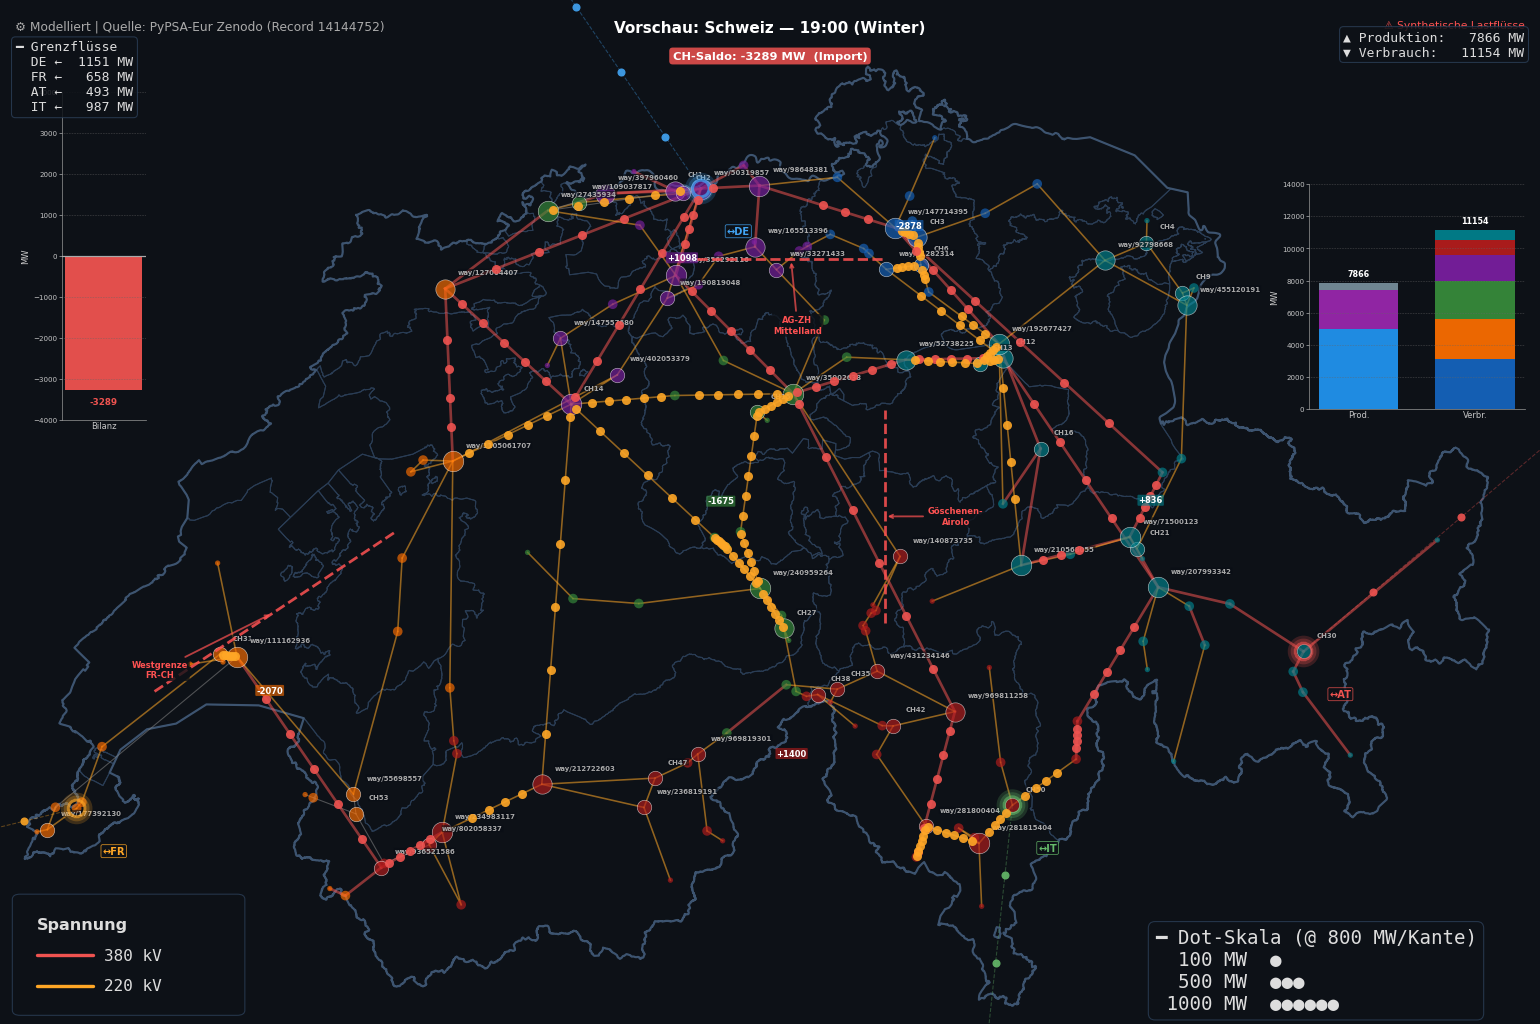


Overlay-Positions-Preview (zum Tunen der k01d-overlay-config)



In [215]:
# ══════════════════════════════════════════════════════════════════════════════
# 👁 Overlay-Vorschau — statisches PNG mit allen aktiven Overlays
# ══════════════════════════════════════════════════════════════════════════════
# Rendert ein Bild mit echten Modell-Werten aus Winter 19h (typischer
# Abend-Spitze-Zustand). So siehst du genau wie die Animation nachher aussieht,
# mit den tatsächlichen Produktions- und Verbrauchswerten.
#
# → Overlay-Positionen anpassen in k01d-overlay-config, diese Zelle (und nur
#   diese) neu ausführen. Erst wenn's passt → GIF-Zellen laufen lassen.

print("▶ Overlay-Vorschau rendern...")

# Repräsentativer Zustand: Winter, 19h (Abendspitze)
_demo_saison = 'Winter'
_demo_hour   = 19

# Echte Modell-Werte
_demo_prod      = ch_produktion_h(_demo_hour, _demo_saison)
_demo_verb      = ch_verbrauch_h (_demo_hour, _demo_saison)
_demo_total_mw  = _demo_prod - _demo_verb
_demo_prod_type = ch_produktion_by_type_h(_demo_hour, _demo_saison)
_demo_verb_zone = ch_verbrauch_by_zone_h (_demo_hour, _demo_saison)

# Grenz-Aufteilung nach BORDER_WEIGHT
_demo_border_flows = {nb: _demo_total_mw * w for nb, w in BORDER_WEIGHT.items()}

def _demo_zone_fn(zone):
    return zone_imb_h(zone, _demo_hour, _demo_saison)

print(f"   Demo-Werte (Winter 19h):")
print(f"   Produktion: {_demo_prod:>7.0f} MW")
print(f"     davon Wasserkraft: {_demo_prod_type.get('Wasserkraft',0):>6.0f} MW")
print(f"           Kernkraft:   {_demo_prod_type.get('Kernkraft',0):>6.0f} MW")
print(f"           Solar:       {_demo_prod_type.get('Solar',0):>6.0f} MW")
print(f"   Verbrauch:  {_demo_verb:>7.0f} MW")
for zone, mw in sorted(_demo_verb_zone.items(), key=lambda x: -x[1]):
    print(f"     {zone:<20}: {mw:>6.0f} MW")
print(f"   CH-Saldo:   {_demo_total_mw:+.0f} MW  ({'Export' if _demo_total_mw > 0 else 'Import'})")

# Hintergrund (gecacht — nutzt BG_CACHE_D wenn schon gerendert)
import io
from PIL import Image as PILImage
_fig = plt.figure(figsize=(FIG_W_IN, FIG_H_IN), facecolor='#0d1117', dpi=DPI_GIF)
_ax  = _fig.add_axes([0, 0, 1, 1])
_ax.set_xlim(*MAP_XLIM); _ax.set_ylim(*MAP_YLIM)
_ax.set_facecolor('#090d14'); _ax.set_axis_off()
_ax.set_aspect('auto')

# Grid-Hintergrund direkt zeichnen (gleiche Layer wie in der GIF-Animation)
_draw_grid_bg(_ax)

# Statischer Flow-Snapshot auf den Kanten
_demo_ef = compute_edge_flows(G, _demo_zone_fn, CC)
for (n1, n2), mw in _demo_ef.items():
    draw_flow_dots_on_edge(_ax, n1, n2, mw, phase=0.2)

# Grenz-Dots
for nb_key, mw in _demo_border_flows.items():
    draw_border_flow_d(_ax, nb_key, mw, phase=0.2)

# Engpässe + Zeit-Label
draw_engpaesse(_ax, lw=1.8, fontsize=5.5)
if OVERLAYS.get('zeit_label', {}).get('enabled', True):
    add_timestamp_bar_d(_ax,
                        f"⚙ Modelliert | Quelle: {DATA_SOURCE}",
                        f"Vorschau: {CC['name']} — {_demo_hour:02d}:00 ({_demo_saison})",
                        "⚠️ Synthetische Lastflüsse")

# Alle Overlays mit ECHTEN Modell-Werten
draw_all_static_overlays(_ax)
draw_all_dynamic_overlays(
    _ax,
    total_mw            = _demo_total_mw,
    produktion_mw       = _demo_prod,
    verbrauch_mw        = _demo_verb,
    border_flows        = _demo_border_flows,
    zone_fn             = _demo_zone_fn,
    produktion_by_type  = _demo_prod_type,
    verbrauch_by_zone   = _demo_verb_zone,
)

_preview_path = os.path.join(EXP_CHARTS_DIR,
                              f'EXP_kuer_k01d_{CC_CODE.lower()}_overlay_vorschau.png')
_fig.savefig(_preview_path, dpi=DPI_GIF, facecolor='#0d1117',
             bbox_inches=None, pad_inches=0)
plt.close(_fig)

print(f"\n✅ Gespeichert: {_preview_path}")
print(f"\n💡 Positionen anpassen in k01d-overlay-config, diese Zelle neu ausführen.")
print(f"   Wenn's passt → weiter zu den GIF-Zellen.\n")
show_chart(os.path.basename(_preview_path),
           'Overlay-Positions-Preview (zum Tunen der k01d-overlay-config)',
           width=900, charts_dir=os.path.dirname(_preview_path))


**🔎 Quellcode der importierten lib-Funktion**

`make_gif_fast_map` aus `lib/map_animation.py` — performance-optimierter
Karten-GIF-Renderer. Statischer Hintergrund wird einmalig via
`draw_background`-Callback erzeugt und gecacht, pro Frame nur die
dynamischen Layer über `draw_dynamic`-Callback gezeichnet. Die
Einzelbilder landen in `<path>_frames/` für den Slider-Modus von
`show_animation`. Aufklappbar darunter der Quellcode.


In [216]:
show_source(make_gif_fast_map)


<details>
<summary>🔎 Quellcode: <code>make_gif_fast_map</code> (aus <code>lib/map_animation.py</code>)</summary>

```python
def make_gif_fast_map(
    draw_background,
    draw_dynamic,
    n_frames,
    fps,
    path,
    map_xlim,
    map_ylim,
    dpi=90,
    fig_size_in=(14, 9),
    facecolor='#0d1117',
    ax_facecolor='#090d14',
    bg_cache_key=None,
    skip_check=None,
    save_frames=True,
    verbose=True,
):
    """Erzeugt ein animiertes GIF mit statischem Hintergrund + dynamischen Layern.

    Rendert den Hintergrund einmal (optional gecacht), dann für jeden Frame
    eine frische Axes mit ``imshow(bg_arr)`` und dem Dynamik-Callback. Die
    Einzelbilder werden als PNGs in ``<path>_frames/`` gespeichert (Standard)
    — diese kann ``lib.widgets.show_animation(path, mode='slider')`` dann
    interaktiv durchblättern.

    Parameter
    ---------
    draw_background : callable(ax) → None
        Zeichnet die statischen Karten-Layer (Kantone, Leitungen, Knoten,
        Zonen-Füllungen) in die übergebene matplotlib Axes. Wird
        EINMAL vor dem Render-Loop aufgerufen. Alle Einstellungen ausser
        xlim/ylim und facecolor setzt der Callback selbst.
    draw_dynamic : callable(ax, frame_idx, n_frames) → None
        Zeichnet dynamische Elemente (Marker, Flüsse, Text, Overlays) für
        den aktuellen Frame. Wird pro Frame aufgerufen. Axes ist bereits
        mit xlim/ylim konfiguriert und zeigt den Hintergrund.
    n_frames : int
        Anzahl Frames im GIF (z.B. 96 = 4h Tagesverlauf bei 4-Frames/h).
    fps : int or float
        Frames pro Sekunde im GIF (z.B. 10).
    path : str
        Ausgabe-Pfad für das GIF (z.B. ``'output/charts/animation.gif'``).
    map_xlim, map_ylim : (float, float)
        Karten-Grenzen in Lon/Lat (z.B. ``(5.88, 10.60)``, ``(45.78, 47.92)``
        für die Schweiz).
    dpi : int, default 90
        Auflösung. 90 = kompakte GIFs (~1MB), 130+ = hochauflösend (~3MB).
    fig_size_in : (float, float), default (14, 9)
        Figure-Grösse in Zoll — zusammen mit dpi ergeben sich die Pixel.
    facecolor : str, default '#0d1117'
        Hintergrundfarbe der Figure (dark-theme).
    ax_facecolor : str, default '#090d14'
        Hintergrundfarbe der Axes (minimal dunkler).
    bg_cache_key : str, optional
        Key für den Modul-Cache. Gleicher Key → Hintergrund wird
        wiederverwendet (z.B. beim Erzeugen mehrerer GIFs mit gleicher
        Basis-Karte). None (Default) → kein Caching.
    skip_check : callable() → bool, optional
        Wenn gesetzt und True zurückgibt → Funktion kehrt sofort zurück
        (für Skip-Logik via config.json). Beispiel::

            skip_check=lambda: should_skip(path, 'animation', name, CFG)

    save_frames : bool, default True
        PNG-Einzelbilder in ``<path>_frames/`` speichern. Erforderlich für
        Slider-Modus von ``show_animation``.
    verbose : bool, default True
        Status-Meldungen auf stdout.
    """
    import matplotlib.pyplot as plt
    import numpy as np
    from PIL import Image as PILImage

    # ── Skip-Check ────────────────────────────────────────────────────────────
    if skip_check is not None and skip_check():
        if verbose:
            print(f'⏭️  {os.path.basename(path)} übersprungen (existiert)')
        return

    # ── Schritt 1: Hintergrund rendern (einmal, optional gecacht) ─────────────
    bg_arr = _render_background_cached(
        draw_background, map_xlim, map_ylim, dpi, fig_size_in,
        facecolor, ax_facecolor, bg_cache_key, verbose)
    h, w = bg_arr.shape[:2]

    fig_w = w / dpi
    fig_h = h / dpi

    # ── Schritt 2: Frame-Ordner anlegen ───────────────────────────────────────
    if save_frames:
        frame_dir = path.replace('.gif', '_frames')
        os.makedirs(frame_dir, exist_ok=True)

    frames_pil = []

    # ── Schritt 3: Frames rendern ────────────────────────────────────────────
    for fi in range(n_frames):
        fig = plt.figure(figsize=(fig_w, fig_h), facecolor=facecolor, dpi=dpi)
        ax = fig.add_axes([0, 0, 1, 1])
        ax.set_xlim(*map_xlim); ax.set_ylim(*map_ylim)
        ax.set_facecolor(ax_facecolor); ax.set_axis_off()
        ax.set_aspect('auto')

        # Background via imshow — pixel-genaue Ausrichtung
        ax.imshow(bg_arr,
                  extent=[map_xlim[0], map_xlim[1], map_ylim[0], map_ylim[1]],
                  origin='upper', aspect='auto',
                  interpolation='nearest', zorder=0)

        # Callback für dynamische Layer
        draw_dynamic(ax, fi, n_frames)

        # Frame → PIL-Image
        buf = io.BytesIO()
        fig.savefig(buf, format='png', dpi=dpi, facecolor=facecolor,
                    bbox_inches=None, pad_inches=0)
        plt.close(fig)
        buf.seek(0)
        frame = PILImage.open(buf).convert('RGB').copy()

        if save_frames:
            frame.save(os.path.join(frame_dir, f'frame_{fi:04d}.png'),
                       optimize=True)
        frames_pil.append(frame)

    # ── Schritt 4: GIF-Compose ────────────────────────────────────────────────
    frames_pil[0].save(path, save_all=True, append_images=frames_pil[1:],
                       duration=int(1000 / fps), loop=0, optimize=True)

    if verbose:
        kb = os.path.getsize(path) // 1024
        print(f'✅ {os.path.basename(path)}')
        print(f'   {n_frames}f @{fps}fps = {n_frames/fps:.1f}s | '
              f'{kb} KB | {w}×{h}px')
        if save_frames:
            print(f'   Frames: {frame_dir}/')
```

</details>


In [217]:
print("\n▶ Starte Erstellung: Tagesfluss 4 Saisons (2/3)")
# 📡 ECHTE TOPOLOGIE | 🔬 SYNTHETISCHER Lastfluss | Overlay-System

def _make_zone_fn_factory(saison):
    """Returns fi -> (zone_name -> imbalance_mw) für Tag-GIF Saison."""
    def zone_fn_of_frame(fi):
        t_h = TAG_TIMES[fi]
        def z_imb(zone): return zone_imb_h(zone, t_h, saison)
        return z_imb
    return zone_fn_of_frame


def _dyn_gif_a(ax, fi, nf, saison, cache):
    t_h    = TAG_TIMES[fi]; h_disp = int(round(t_h)) % 24
    ef     = cache['edge_flows_by_frame'][fi]
    total  = cache['total_by_frame'][fi]
    border = cache['border_flows_by_frame'][fi]

    # Kanten-Fluss-Dots
    for (n1, n2), mw in ef.items():
        phase = cache['edge_phases'][(n1, n2)][fi]
        mw_norm = cache['edge_norms'][(n1, n2)]
        draw_flow_dots_on_edge(ax, n1, n2, mw, phase, mw_norm=mw_norm)

    # Border-Flüsse an realen Grenz-Hubs
    border_norm = cache['border_norm']
    for nb_key, mw in border.items():
        phase = cache['border_phases'][nb_key][fi]
        draw_border_flow_d(ax, nb_key, mw, phase, mw_norm=border_norm)

    # Produktion und Verbrauch direkt aus dem Modell (nicht mehr approximiert)
    prod = ch_produktion_h(t_h, saison)
    verb = ch_verbrauch_h(t_h, saison)
    # Daten für Balkendiagramm
    prod_by_type = ch_produktion_by_type_h(t_h, saison)
    verb_by_zone = ch_verbrauch_by_zone_h(t_h, saison)

    # Overlays zeichnen
    draw_all_static_overlays(ax)
    draw_all_dynamic_overlays(
        ax,
        total_mw            = total,
        produktion_mw       = prod,
        verbrauch_mw        = verb,
        border_flows        = border,
        zone_fn             = lambda z: zone_imb_h(z, t_h, saison),
        produktion_by_type  = prod_by_type,
        verbrauch_by_zone   = verb_by_zone,
    )

    draw_engpaesse(ax, lw=1.8, fontsize=5.5)
    if OVERLAYS.get('zeit_label', {}).get('enabled', True):
        add_timestamp_bar_d(ax, f"⚙ Modelliert | Quelle: {DATA_SOURCE}",
                            f"Lastfluss {CC['name']} — {h_disp:02d}:00 ({saison})",
                            "⚠️ Synthetische Lastflüsse")


for saison in SAISONS:
    print(f"\n  ── {saison} ──")
    cache = precompute_flow_cache(_make_zone_fn_factory(saison),
                                   N_FRAMES_TAG, FPS_TAG)
    p = os.path.join(EXP_CHARTS_DIR, f'EXP_kuer_k01d_{CC_CODE.lower()}_tag_{saison.lower()}.gif')
    make_gif_fast_map(
        draw_background=_draw_grid_bg,
        draw_dynamic=lambda ax, fi, nf, s=saison, c=cache: _dyn_gif_a(ax, fi, nf, s, c),
        n_frames=N_FRAMES_TAG,
        fps=FPS_TAG,
        path=p,
        map_xlim=MAP_XLIM, map_ylim=MAP_YLIM,
        dpi=DPI_GIF, fig_size_in=(FIG_W_IN, FIG_H_IN),
        bg_cache_key='grid',
        skip_check=lambda: should_skip(p, 'animation',
            os.path.basename(p).rsplit('.', 1)[0], CFG),
    )



▶ Starte Erstellung: Tagesfluss 4 Saisons (2/3)

  ── Winter ──
  ⏳ Pre-Compute Fluss-Cache... OK (288f × 204 Kanten + 4 Border | Phase-Step=0.0083/frame)
✅ EXP_kuer_k01d_ch_tag_winter.gif
   288f @30fps = 9.6s | 38307 KB | 1540×1024px
   Frames: .\output\charts\EXP_kuer_k01d_ch_tag_winter_frames/

  ── Frühling ──
  ⏳ Pre-Compute Fluss-Cache... OK (288f × 204 Kanten + 4 Border | Phase-Step=0.0083/frame)
✅ EXP_kuer_k01d_ch_tag_frühling.gif
   288f @30fps = 9.6s | 40950 KB | 1540×1024px
   Frames: .\output\charts\EXP_kuer_k01d_ch_tag_frühling_frames/

  ── Sommer ──
  ⏳ Pre-Compute Fluss-Cache... OK (288f × 204 Kanten + 4 Border | Phase-Step=0.0083/frame)
✅ EXP_kuer_k01d_ch_tag_sommer.gif
   288f @30fps = 9.6s | 36630 KB | 1540×1024px
   Frames: .\output\charts\EXP_kuer_k01d_ch_tag_sommer_frames/

  ── Herbst ──
  ⏳ Pre-Compute Fluss-Cache... OK (288f × 204 Kanten + 4 Border | Phase-Step=0.0083/frame)
✅ EXP_kuer_k01d_ch_tag_herbst.gif
   288f @30fps = 9.6s | 32495 KB | 1540×1024px
   F

**🔎 Quellcode der importierten lib-Funktion**

Die Funktion `show_animation` wird aus `lib/widgets.py` importiert und ab
dieser Stelle im Notebook verwendet. Mit einem Klick auf den aufklappbaren
Block darunter ist der Quellcode direkt im Notebook einsehbar — ohne die
`lib/`-Datei öffnen zu müssen.


In [223]:
show_source(show_animation)


<details>
<summary>🔎 Quellcode: <code>show_animation</code> (aus <code>lib/widgets.py</code>)</summary>

```python
def show_animation(
    path: str,
    mode: str = "gif",
    framerate: int = 10,
    width=1100,
    caption: str | None = None,
) -> None:
    """Zeigt eine Animation an — als GIF (inline) oder als Slider (interaktiv).

    Parameter
    ---------
    path : str
        Voller Pfad zur .gif-Datei. Bei mode='slider' wird der zugehörige
        ``<basename>_frames/``-Ordner automatisch gefunden.
    mode : {'gif', 'slider'}, default 'gif'
        ``'gif'``    — zeigt das fertige GIF inline
        ``'slider'`` — interaktiver Play/Slide-Viewer (Voraussetzung: ipywidgets
        installiert und Frames im _frames/-Ordner vorhanden)
    framerate : int, default 10
        fps bei mode='slider'. Bei mode='gif' ignoriert (fps steckt im GIF).
    width : int or str, default 1100
        Anzeigebreite. Int → Pixel (z.B. 900), Str → CSS (z.B. '100%', '900px').
    caption : str, optional
        Bildunterschrift. Wird nach der Animation ausgegeben.

    Beispiele
    ---------
    >>> show_animation('/output/charts/kuer_k04_anim_A.gif', mode='gif')
    >>> show_animation('/output/charts/kuer_k04_anim_A.gif', mode='slider',
    ...                framerate=15, width='100%')
    """
    from IPython.display import display, Image, HTML

    if mode not in ("gif", "slider"):
        raise ValueError(
            f"mode muss 'gif' oder 'slider' sein, nicht {mode!r}"
        )

    # Für beide Modi: Existenz prüfen (bei slider auf _frames-Ordner via slide_or_play)
    if mode == "gif":
        if not os.path.exists(path):
            print(f"⚠️  Datei nicht gefunden: {path}")
            return
        # Int width → px (Image-Parameter), Str width → CSS über HTML-img
        if isinstance(width, int):
            display(Image(filename=path, width=width))
        else:
            display(HTML(f'<img src="{path}" style="width:{width};display:block">'))
    else:  # mode == 'slider'
        # Breite als CSS-String für slide_or_play
        if isinstance(width, int):
            width_css = f"{width}px"
        else:
            width_css = width
        slide_or_play(path, framerate=framerate, image_width=width_css)

    if caption:
        print(f"\n{caption}\n")
```

</details>


In [228]:
# ── Ausgabe anzeigen ────────────────────────────────────────────
_p = os.path.join(EXP_CHARTS_DIR, 'EXP_kuer_k01d_ch_tag_winter.gif')
# Umschalten: mode='gif' (Standbild) oder mode='slider' (interaktiv).
# framerate nur für Slider relevant (bei GIF steckt fps im GIF selbst).
show_animation(_p, mode='slider', framerate=10,
    width=700)


📼 Lade 288 Frames aus .\output\charts\EXP_kuer_k01d_ch_tag_winter_frames...
   ✅ geladen (167 MB RAM)


In [229]:
# ── Ausgabe anzeigen ────────────────────────────────────────────
_p = os.path.join(EXP_CHARTS_DIR, 'EXP_kuer_k01d_ch_tag_frühling.gif')
# Umschalten: mode='gif' (Standbild) oder mode='slider' (interaktiv).
# framerate nur für Slider relevant (bei GIF steckt fps im GIF selbst).
show_animation(_p, mode='slider', framerate=10,
    width=700)


📼 Lade 288 Frames aus .\output\charts\EXP_kuer_k01d_ch_tag_frühling_frames...
   ✅ geladen (167 MB RAM)


In [230]:
# ── Ausgabe anzeigen ────────────────────────────────────────────
_p = os.path.join(EXP_CHARTS_DIR, 'EXP_kuer_k01d_ch_tag_sommer.gif')
# Umschalten: mode='gif' (Standbild) oder mode='slider' (interaktiv).
# framerate nur für Slider relevant (bei GIF steckt fps im GIF selbst).
show_animation(_p, mode='slider', framerate=10,
    width=700)


📼 Lade 288 Frames aus .\output\charts\EXP_kuer_k01d_ch_tag_sommer_frames...
   ✅ geladen (167 MB RAM)


In [231]:
# ── Ausgabe anzeigen ────────────────────────────────────────────
_p = os.path.join(EXP_CHARTS_DIR, 'EXP_kuer_k01d_ch_tag_herbst.gif')
# Umschalten: mode='gif' (Standbild) oder mode='slider' (interaktiv).
# framerate nur für Slider relevant (bei GIF steckt fps im GIF selbst).
show_animation(_p, mode='slider', framerate=10,
    width=700)


📼 Lade 288 Frames aus .\output\charts\EXP_kuer_k01d_ch_tag_herbst_frames...
   ✅ geladen (167 MB RAM)


**GIF A — Tagesfluss auf echten Leitungspfaden (Winter)**

Moving Dots auf echten OSM-Leitungen. Dot-Dichte = MW-Fluss.
Zone-Labels ±MW. Cross-Border an echten Grenzknoten (Laufenburg→DE, Castione→IT).

---
## 6. GIF B — Jahresverlauf & Richtungsumkehr<a id='gif_b_K_01d'></a>

[↑ Inhaltsverzeichnis](#toc_K_01d)

52 Wochen. Die CH-Bilanz kippt von Export (Sommer) zu Import (Winter-Spitze). Richtungsumkehr der Cross-Border-Dots sichtbar.

In [237]:
print("\n▶ Starte Erstellung: Jahresverlauf 19h + 12h (3/3)")
# 📡 ECHTE TOPOLOGIE | 🔬 SYNTHETISCH | Overlay-System
# Gewichtete Saison-Interpolation — keine Sprünge an Saison-Grenzen

# ══════════════════════════════════════════════════════════════════════════════
# Saison-Gewichte für kontinuierliche Jahres-Interpolation
# ══════════════════════════════════════════════════════════════════════════════
# Problem: die frühere Implementierung nutzte `saison = SAISONS[int(t_w/52*4)]`
#   → diskrete Sprünge an Wochen 13, 26, 39 (Saison-Wechsel)
#   → an diesen Stellen änderten sich CF_SEASONAL-Werte um 13-150%
#   → dadurch sprunghafte Änderungen in Produktion/Verbrauch/Edge-Flows
#
# Lösung: jede Woche als GEWICHTETE MISCHUNG aller 4 Saisons berechnen (Gauss-
# Glocken um die 4 Saison-Zentren Winter=W52, Frühling=W13, Sommer=W26, Herbst=W39).
# An Woche 13.0 sind die Gewichte etwa {Winter:0.11, Frühling:0.79, Sommer:0.11,
# Herbst:0.00} → glatter Übergang zwischen den Saisons.

_SAISON_CENTERS_W = {'Winter': 52.0, 'Frühling': 13.0, 'Sommer': 26.0, 'Herbst': 39.0}
_SAISON_WIDTH_W   = 6.5   # Gauss-σ in Wochen

def saison_weights(t_w):
    """Gewichtete Saison-Anteile an Woche t_w (0..52), Summe = 1."""
    raw = {}
    for sais, center in _SAISON_CENTERS_W.items():
        dw = min(abs(t_w - center), 52 - abs(t_w - center))
        raw[sais] = np.exp(-(dw**2) / (2*_SAISON_WIDTH_W**2))
    total = sum(raw.values())
    return {s: w/total for s, w in raw.items()}

def zone_imb_smooth(zone, h, t_w):
    """Kontinuierliche Zone-Imbalance: gewichteter Mix aller Saisons, Wochenprofil skaliert Verbrauch."""
    ws = saison_weights(t_w)
    week_scale = float(cons_w(t_w))
    # Produktion gewichtet über Saisons
    prod = sum(w * sum(inst * CF[et] * CF_SEASONAL[et][sais]
                       * (solar_h(h) if et=='Solar' else (hydro_h(h) if et=='Wasserkraft' else 1.0))
                       for et, inst in ZONE_PROD_INSTALLED.get(zone,{}).items())
               for sais, w in ws.items())
    # Verbrauch: Tagesprofil × gewichteter Saisons-Faktor × Wochenskalierung
    sais_cons_factors = {'Winter':1.15,'Frühling':1.00,'Sommer':0.87,'Herbst':1.02}
    sais_weighted_factor = sum(ws[s] * sais_cons_factors[s] for s in SAISONS)
    hour_factor = (1.0 + 0.38*np.exp(-((h-8.5)**2)/4.5)
                       + 0.44*np.exp(-((h-19.0)**2)/5.0)
                       - 0.28*np.exp(-((h-4.0)**2)/3.0))
    cons = ZONE_BASE_CONS.get(zone, 500) * sais_weighted_factor * hour_factor * week_scale
    return prod - cons

def ch_produktion_smooth(h, t_w):
    """CH-Gesamtproduktion mit Saison-Interpolation."""
    ws = saison_weights(t_w)
    return sum(w * ch_produktion_h(h, s) for s, w in ws.items())

def ch_verbrauch_smooth(h, t_w):
    """CH-Gesamtverbrauch mit Saison-Interpolation × Wochenprofil."""
    ws = saison_weights(t_w)
    return sum(w * ch_verbrauch_h(h, s) for s, w in ws.items()) * float(cons_w(t_w))

def ch_produktion_by_type_smooth(h, t_w):
    ws = saison_weights(t_w)
    result = {'Solar':0.0, 'Wasserkraft':0.0, 'Kernkraft':0.0, 'Andere':0.0}
    for sais, weight in ws.items():
        pt = ch_produktion_by_type_h(h, sais)
        for et, mw in pt.items():
            result[et] = result.get(et, 0) + weight * mw
    return result

def ch_verbrauch_by_zone_smooth(h, t_w):
    ws = saison_weights(t_w)
    week_scale = float(cons_w(t_w))
    result = {}
    for sais, weight in ws.items():
        vz = ch_verbrauch_by_zone_h(h, sais)
        for zone, mw in vz.items():
            result[zone] = result.get(zone, 0) + weight * mw * week_scale
    return result


def _make_zone_fn_factory_jahr(hour_of_day):
    """Returns fi -> (zone -> imbalance) für Jahres-GIF fester Stunde.
    Nutzt glatte Saison-Interpolation, keine diskreten Saison-Wechsel."""
    def zone_fn_of_frame(fi):
        t_w = JAHR_TIMES[fi]
        def z_imb(zone):
            return zone_imb_smooth(zone, hour_of_day, t_w)
        return z_imb
    return zone_fn_of_frame


def _dyn_gif_b(ax, fi, nf, hour_of_day, cache):
    t_w   = JAHR_TIMES[fi]
    monat = MONAT_KURZ[int(t_w/52*12) % 12]

    ef     = cache['edge_flows_by_frame'][fi]
    total  = cache['total_by_frame'][fi]
    border = cache['border_flows_by_frame'][fi]

    # Kanten-Dots
    for (n1, n2), mw in ef.items():
        phase = cache['edge_phases'][(n1, n2)][fi]
        mw_norm = cache['edge_norms'][(n1, n2)]
        draw_flow_dots_on_edge(ax, n1, n2, mw, phase, mw_norm=mw_norm)

    # Border-Dots
    border_norm = cache['border_norm']
    for nb_key, mw in border.items():
        phase = cache['border_phases'][nb_key][fi]
        draw_border_flow_d(ax, nb_key, mw, phase, mw_norm=border_norm)

    # Produktion/Verbrauch mit glatter Saison-Interpolation
    prod         = ch_produktion_smooth(hour_of_day, t_w)
    verb         = ch_verbrauch_smooth (hour_of_day, t_w)
    prod_by_type = ch_produktion_by_type_smooth(hour_of_day, t_w)
    verb_by_zone = ch_verbrauch_by_zone_smooth (hour_of_day, t_w)

    # Overlays
    draw_all_static_overlays(ax)
    draw_all_dynamic_overlays(
        ax,
        total_mw            = total,
        produktion_mw       = prod,
        verbrauch_mw        = verb,
        border_flows        = border,
        zone_fn             = lambda z: zone_imb_smooth(z, hour_of_day, t_w),
        produktion_by_type  = prod_by_type,
        verbrauch_by_zone   = verb_by_zone,
    )

    draw_engpaesse(ax, lw=1.8, fontsize=5.5)
    if OVERLAYS.get('zeit_label', {}).get('enabled', True):
        # Label mit aktuell dominanter Saison (informativ, nicht für Rechnung)
        ws = saison_weights(t_w)
        dom_saison = max(ws, key=ws.get)
        add_timestamp_bar_d(ax, f"⚙ Modelliert | {DATA_SOURCE}",
                            f"Jahresverlauf {CC['name']} — Woche {int(t_w)+1:02d}/52 ({monat}, {dom_saison}) | {hour_of_day:02d}:00",
                            "⚠️ Synthetische Lastflüsse")


print("\n  ── 19:00 Abendspitze ──")
cache_19 = precompute_flow_cache(_make_zone_fn_factory_jahr(19), N_FRAMES_JAHR, FPS_JAHR)
p19 = os.path.join(EXP_CHARTS_DIR, f'EXP_kuer_k01d_{CC_CODE.lower()}_jahr_19h.gif')
make_gif_fast_map(
    draw_background=_draw_grid_bg,
    draw_dynamic=lambda ax, fi, nf, c=cache_19: _dyn_gif_b(ax, fi, nf, 19, c),
    n_frames=N_FRAMES_JAHR,
    fps=FPS_JAHR,
    path=p19,
    map_xlim=MAP_XLIM, map_ylim=MAP_YLIM,
    dpi=DPI_GIF, fig_size_in=(FIG_W_IN, FIG_H_IN),
    bg_cache_key='grid',
    skip_check=lambda: should_skip(p19, 'animation',
        os.path.basename(p19).rsplit('.', 1)[0], CFG),
)

print("\n  ── 12:00 Mittag ──")
cache_12 = precompute_flow_cache(_make_zone_fn_factory_jahr(12), N_FRAMES_JAHR, FPS_JAHR)
p12 = os.path.join(EXP_CHARTS_DIR, f'EXP_kuer_k01d_{CC_CODE.lower()}_jahr_12h.gif')
make_gif_fast_map(
    draw_background=_draw_grid_bg,
    draw_dynamic=lambda ax, fi, nf, c=cache_12: _dyn_gif_b(ax, fi, nf, 12, c),
    n_frames=N_FRAMES_JAHR,
    fps=FPS_JAHR,
    path=p12,
    map_xlim=MAP_XLIM, map_ylim=MAP_YLIM,
    dpi=DPI_GIF, fig_size_in=(FIG_W_IN, FIG_H_IN),
    bg_cache_key='grid',
    skip_check=lambda: should_skip(p12, 'animation',
        os.path.basename(p12).rsplit('.', 1)[0], CFG),
)



▶ Starte Erstellung: Jahresverlauf 19h + 12h (3/3)

  ── 19:00 Abendspitze ──
  ⏳ Pre-Compute Fluss-Cache... OK (624f × 204 Kanten + 4 Border | Phase-Step=0.0083/frame)
⏭️  EXP_kuer_k01d_ch_jahr_19h.gif übersprungen (existiert)

  ── 12:00 Mittag ──
  ⏳ Pre-Compute Fluss-Cache... OK (624f × 204 Kanten + 4 Border | Phase-Step=0.0083/frame)
⏭️  EXP_kuer_k01d_ch_jahr_12h.gif übersprungen (existiert)


In [238]:
print("\n▶ Jahresverlauf als Tagesmittel (optional)")
# 📡 ECHTE TOPOLOGIE | 🔬 SYNTHETISCH | 24h-Mittel pro Frame
# Ergänzung zu gif-b (19h/12h-Momentaufnahmen) — zeigt den DURCHSCHNITTLICHEN
# Tageszustand pro Zeitpunkt im Jahr. Kein Cherry-Picking einer Extremstunde.

# ── Parameter ────────────────────────────────────────────────────────────────
# 'weekly' = 1 Frame pro Woche  (52f × FRAME_MULT)  — schnell, grob
# 'daily'  = 1 Frame pro Tag    (364f × FRAME_MULT) — flüssig, detailreich
TAGESMITTEL_RESOLUTION   = 'daily'

# Glättung via moving-average über benachbarte Frames (dämpft Kanten-Flow-
# Artefakte durch diskrete shortest-path-Wechsel). 0=aus, 1=3f, 2=5f
TAGESMITTEL_SMOOTH_WIDTH = 1

# ── Tagesmittel-Funktionen (24h-Mittel, Saison-interpoliert) ────────────────
_HOURS = np.arange(24)
_SAIS_CONS_FACTORS = {'Winter':1.15,'Frühling':1.00,'Sommer':0.87,'Herbst':1.02}

def zone_imb_tagesmittel(zone, t_w):
    """Tagesmittel (24h) der Zone-Imbalance, Saison-interpoliert, Wochen-skaliert."""
    ws = saison_weights(t_w)       # aus gif-b (Saison-Gewichte)
    week_scale = float(cons_w(t_w))
    prod_mean = 0.0
    cons_mean = 0.0
    hour_factor_mean = np.mean([
        1.0 + 0.38*np.exp(-((h-8.5)**2)/4.5)
            + 0.44*np.exp(-((h-19.0)**2)/5.0)
            - 0.28*np.exp(-((h-4.0)**2)/3.0)
        for h in _HOURS
    ])
    solar_mean = np.mean([solar_h(h) for h in _HOURS])
    hydro_mean = np.mean([hydro_h(h) for h in _HOURS])
    for sais, weight in ws.items():
        prod_sais = sum(inst * CF[et] * CF_SEASONAL[et][sais] *
                        (solar_mean if et=='Solar'
                         else (hydro_mean if et=='Wasserkraft' else 1.0))
                        for et, inst in ZONE_PROD_INSTALLED.get(zone,{}).items())
        prod_mean += weight * prod_sais
        cons_sais = ZONE_BASE_CONS.get(zone, 500) * _SAIS_CONS_FACTORS[sais] * hour_factor_mean
        cons_mean += weight * cons_sais
    return prod_mean - cons_mean * week_scale

def ch_produktion_tagesmittel(t_w):
    ws = saison_weights(t_w)
    return sum(w * np.mean([ch_produktion_h(h, s) for h in _HOURS]) for s, w in ws.items())

def ch_verbrauch_tagesmittel(t_w):
    ws = saison_weights(t_w)
    week_scale = float(cons_w(t_w))
    return sum(w * np.mean([ch_verbrauch_h(h, s) for h in _HOURS])
               for s, w in ws.items()) * week_scale

def ch_produktion_by_type_tagesmittel(t_w):
    ws = saison_weights(t_w)
    result = {'Solar':0.0, 'Wasserkraft':0.0, 'Kernkraft':0.0, 'Andere':0.0}
    for sais, weight in ws.items():
        for h in _HOURS:
            pt = ch_produktion_by_type_h(h, sais)
            for et, mw in pt.items():
                result[et] = result.get(et, 0) + (weight * mw / 24.0)
    return result

def ch_verbrauch_by_zone_tagesmittel(t_w):
    ws = saison_weights(t_w)
    week_scale = float(cons_w(t_w))
    result = {}
    for sais, weight in ws.items():
        for h in _HOURS:
            vz = ch_verbrauch_by_zone_h(h, sais)
            for zone, mw in vz.items():
                result[zone] = result.get(zone, 0) + (weight * mw * week_scale / 24.0)
    return result


# ── Optionale Glättung des Fluss-Caches ─────────────────────────────────────
def smooth_cache(cache, width):
    """Moving-average mit Fenstergrösse (2*width+1) auf edge_flows + border_flows.
    Phase wird NICHT geglättet. width=0 = no-op."""
    if width <= 0:
        return cache
    n = len(cache['edge_flows_by_frame'])
    kernel = np.ones(2*width + 1) / (2*width + 1)
    edge_keys = list(cache['edge_flows_by_frame'][0].keys()) if cache['edge_flows_by_frame'] else []
    for ek in edge_keys:
        vals = np.array([cache['edge_flows_by_frame'][i].get(ek, 0.0) for i in range(n)])
        smoothed = np.convolve(vals, kernel, mode='same')
        for i in range(n):
            cache['edge_flows_by_frame'][i][ek] = smoothed[i]
    border_keys = list(cache['border_flows_by_frame'][0].keys()) if cache['border_flows_by_frame'] else []
    for bk in border_keys:
        vals = np.array([cache['border_flows_by_frame'][i].get(bk, 0.0) for i in range(n)])
        smoothed = np.convolve(vals, kernel, mode='same')
        for i in range(n):
            cache['border_flows_by_frame'][i][bk] = smoothed[i]
    cache['total_by_frame'] = np.convolve(cache['total_by_frame'], kernel, mode='same')
    return cache


# ── Rendering ────────────────────────────────────────────────────────────────
def _make_zone_fn_tagesmittel():
    def zone_fn_of_frame(fi):
        t_w = JAHR_TM_TIMES[fi]
        def z_imb(zone):
            return zone_imb_tagesmittel(zone, t_w)
        return z_imb
    return zone_fn_of_frame

def _dyn_tagesmittel(ax, fi, nf, cache):
    t_w   = JAHR_TM_TIMES[fi]
    monat = MONAT_KURZ[int(t_w/52*12) % 12]
    ef     = cache['edge_flows_by_frame'][fi]
    total  = cache['total_by_frame'][fi]
    border = cache['border_flows_by_frame'][fi]

    for (n1, n2), mw in ef.items():
        phase = cache['edge_phases'][(n1, n2)][fi]
        mw_norm = cache['edge_norms'][(n1, n2)]
        draw_flow_dots_on_edge(ax, n1, n2, mw, phase, mw_norm=mw_norm)

    border_norm = cache['border_norm']
    for nb_key, mw in border.items():
        phase = cache['border_phases'][nb_key][fi]
        draw_border_flow_d(ax, nb_key, mw, phase, mw_norm=border_norm)

    prod = ch_produktion_tagesmittel(t_w)
    verb = ch_verbrauch_tagesmittel(t_w)
    prod_by_type = ch_produktion_by_type_tagesmittel(t_w)
    verb_by_zone = ch_verbrauch_by_zone_tagesmittel(t_w)

    draw_all_static_overlays(ax)
    draw_all_dynamic_overlays(
        ax, total_mw=total, produktion_mw=prod, verbrauch_mw=verb,
        border_flows=border,
        zone_fn=lambda z: zone_imb_tagesmittel(z, t_w),
        produktion_by_type=prod_by_type, verbrauch_by_zone=verb_by_zone,
    )
    draw_engpaesse(ax, lw=1.8, fontsize=5.5)
    if OVERLAYS.get('zeit_label', {}).get('enabled', True):
        ws = saison_weights(t_w)
        dom_saison = max(ws, key=ws.get)
        tag_im_jahr = int(t_w * 7) + 1
        add_timestamp_bar_d(ax, f"⚙ Modelliert | {DATA_SOURCE}",
                            f"Jahresverlauf {CC['name']} — Tag {tag_im_jahr:03d}/365 ({monat}, {dom_saison}) | 24h-Mittel",
                            "⚠️ Synthetische Lastflüsse")


# ── Auflösung wählen und rendern ─────────────────────────────────────────────
if TAGESMITTEL_RESOLUTION == 'daily':
    N_FRAMES_JAHR_TM = 364 * FRAME_MULT
    JAHR_TM_TIMES    = np.linspace(0, 52, N_FRAMES_JAHR_TM, endpoint=False)
    print(f"  Auflösung: 1 Frame/Tag × FRAME_MULT={FRAME_MULT} → "
          f"{N_FRAMES_JAHR_TM}f @{FPS_JAHR}fps = {N_FRAMES_JAHR_TM/FPS_JAHR:.1f}s")
else:
    N_FRAMES_JAHR_TM = N_FRAMES_JAHR
    JAHR_TM_TIMES    = JAHR_TIMES
    print(f"  Auflösung: 1 Frame/Woche → {N_FRAMES_JAHR_TM}f @{FPS_JAHR}fps = {N_FRAMES_JAHR_TM/FPS_JAHR:.1f}s")

cache_tm = precompute_flow_cache(_make_zone_fn_tagesmittel(), N_FRAMES_JAHR_TM, FPS_JAHR)

if TAGESMITTEL_SMOOTH_WIDTH > 0:
    print(f"  Glättung: moving average ±{TAGESMITTEL_SMOOTH_WIDTH} Frames "
          f"(Fenster={2*TAGESMITTEL_SMOOTH_WIDTH+1}f)...")
    cache_tm = smooth_cache(cache_tm, TAGESMITTEL_SMOOTH_WIDTH)

p_tm = os.path.join(EXP_CHARTS_DIR, f'EXP_kuer_k01d_{CC_CODE.lower()}_jahr_tagesmittel.gif')
make_gif_fast_map(
    draw_background=_draw_grid_bg,
    draw_dynamic=lambda ax, fi, nf, c=cache_tm: _dyn_tagesmittel(ax, fi, nf, c),
    n_frames=N_FRAMES_JAHR_TM,
    fps=FPS_JAHR,
    path=p_tm,
    map_xlim=MAP_XLIM, map_ylim=MAP_YLIM,
    dpi=DPI_GIF, fig_size_in=(FIG_W_IN, FIG_H_IN),
    bg_cache_key='grid',
    skip_check=lambda: should_skip(p_tm, 'animation',
        os.path.basename(p_tm).rsplit('.', 1)[0], CFG),
)



▶ Jahresverlauf als Tagesmittel (optional)
  Auflösung: 1 Frame/Tag × FRAME_MULT=3 → 1092f @30fps = 36.4s
  ⏳ Pre-Compute Fluss-Cache... OK (1092f × 204 Kanten + 4 Border | Phase-Step=0.0083/frame)
  Glättung: moving average ±1 Frames (Fenster=3f)...
⏭️  EXP_kuer_k01d_ch_jahr_tagesmittel.gif übersprungen (existiert)


In [239]:
# ── Ausgabe anzeigen ────────────────────────────────────────────
_p = os.path.join(EXP_CHARTS_DIR, 'EXP_kuer_k01d_ch_jahr_19h.gif')
# Umschalten: mode='gif' (Standbild) oder mode='slider' (interaktiv).
# framerate nur für Slider relevant (bei GIF steckt fps im GIF selbst).
show_animation(_p, mode='slider', framerate=10,
    width=700)


📼 Lade 624 Frames aus .\output\charts\EXP_kuer_k01d_ch_jahr_19h_frames...
   ✅ geladen (366 MB RAM)


In [240]:
# ── Ausgabe anzeigen ────────────────────────────────────────────
_p = os.path.join(EXP_CHARTS_DIR, 'EXP_kuer_k01d_ch_jahr_12h.gif')
# Umschalten: mode='gif' (Standbild) oder mode='slider' (interaktiv).
# framerate nur für Slider relevant (bei GIF steckt fps im GIF selbst).
show_animation(_p, mode='slider', framerate=10,
    width=700)

📼 Lade 624 Frames aus .\output\charts\EXP_kuer_k01d_ch_jahr_12h_frames...
   ✅ geladen (364 MB RAM)


In [241]:
# ── Ausgabe anzeigen ────────────────────────────────────────────
_p = os.path.join(EXP_CHARTS_DIR, 'EXP_kuer_k01d_ch_jahr_tagesmittel.gif')
# Umschalten: mode='gif' (Standbild) oder mode='slider' (interaktiv).
# framerate nur für Slider relevant (bei GIF steckt fps im GIF selbst).
show_animation(_p, mode='slider', framerate=10,
    width=700)

📼 Lade 1092 Frames aus .\output\charts\EXP_kuer_k01d_ch_jahr_tagesmittel_frames...
   ✅ geladen (639 MB RAM)


**GIF B — Jahresverlauf Abendspitze (19h)**

Richtungsumkehr: CH-Saldo-Badge wechselt grün (Export) ↔ rot (Import).
19h: Abendspitze → Importrisiko im Winter. 12h: Mittag → Solar-Überschuss Sommer.

---
## 7. Multi-Country Erweiterung<a id='multi_K_01d'></a>

[↑ Inhaltsverzeichnis](#toc_K_01d)

Anleitung und Code-Template für DE, AT, FR, IT. Alle Funktionen sind generisch — nur `CC_CODE` ändern.

### 8.1 Workflow für ein neues Land

1. **`COUNTRY_CONFIG` ergänzen** (in Initialisierungszelle):
```python
'DE': {
    'name': 'Deutschland',
    'osm_area': 'ISO3166-1"="DE',
    'bbox': (6.00, 47.20, 15.10, 55.10),
    'voltage_kv': [220, 380],
    'zone_mapping': {},     # ggf. Bundesland-Zonen definieren
    'zone_colors': {},
    'map_xlim': (6.0, 15.2),
    'map_ylim': (47.2, 55.2),
}
```

2. **`CC_CODE = 'DE'`** setzen → Notebook komplett neu ausführen

3. Optional **Baseline** für DE in `COUNTRY_BASELINES` hinterlegen
   (TSO-Umspannwerke: Amprion, TenneT, TransnetBW, 50Hertz)

4. **GIFs** erscheinen automatisch mit `kuer_k01d_de_*` Prefix

### 8.2 Datenqualität nach Land

| Land | Overpass-Qualität | Baseline vorhanden | Hinweis |
|------|------------------|--------------------|---------|
| CH | ★★★★★ | ✅ 27 Knoten | Swissgrid gut dokumentiert |
| DE | ★★★★☆ | ❌ (noch offen) | 4 TSOs, > 200 Knoten |
| AT | ★★★★☆ | ❌ | APG (~60 Knoten) |
| FR | ★★★☆☆ | ❌ | RTE, teilweise fehlend in OSM |
| IT | ★★★☆☆ | ❌ | Terna, OSM unvollständig |

### 8.3 PyPSA-Eur als beste Vollösung

Für DE/AT/FR/IT empfehlen sich die **prebuilt networks** von Zenodo:
- `zenodo.org/records/14144752` — alle CH/DE/AT/FR/IT buses + lines als CSV
- Direkt filterbar nach `country` Spalte
- Reaktanz/Widerstand vorhanden (für echten DC-Lastfluss)


In [242]:
# ── Multi-Country Batch (alle konfigurierten Länder) ─────────────────────────
# Aktivieren mit: BATCH_RUN = True
# Erzeugt statische Karten für alle Länder mit verfügbaren Daten

BATCH_RUN = False  # ⚙ True für automatischen Multi-Country-Durchlauf

if BATCH_RUN:
    for cc, cc_cfg in COUNTRY_CONFIG.items():
        print(f"\n{'='*50}")
        print(f"=== {cc}: {cc_cfg['name']} ===")

        # Topologie laden
        result = download_grid_osm(cc, cc_cfg, EXP_CACHE_DIR, force=False)
        if result is None:
            result = load_from_baseline(cc, cc_cfg)
        if result is None:
            print(f"⚠️  Keine Daten für {cc} — übersprungen")
            continue

        df_n, df_e = result

        # Graph aufbauen
        G_cc = nx.Graph()
        for _, row in df_n.iterrows():
            G_cc.add_node(row['id'], lon=float(row['lon']), lat=float(row['lat']),
                          voltage_kv=int(row.get('voltage_kv',220)),
                          zone=str(row.get('zone','')))
        for _, row in df_e.iterrows():
            fn = row.get('from_node', row.get('id',''))
            tn = row.get('to_node', row.get('id',''))
            if fn in G_cc and tn in G_cc and fn != tn:
                G_cc.add_edge(fn, tn, voltage_kv=int(row.get('voltage_kv',220)))
        nx.set_node_attributes(G_cc, dict(G_cc.degree()), 'degree')

        # Statische Karte
        fig, ax = plt.subplots(figsize=(14, 9))
        fig.patch.set_facecolor(BG_DARK)
        ax.set_facecolor('#090d14')
        ax.set_xlim(*cc_cfg['map_xlim']); ax.set_ylim(*cc_cfg['map_ylim'])
        ax.set_axis_off()
        for n1, n2, data in G_cc.edges(data=True):
            kv  = data.get('voltage_kv', 220)
            x1,y1 = G_cc.nodes[n1]['lon'],G_cc.nodes[n1]['lat']
            x2,y2 = G_cc.nodes[n2]['lon'],G_cc.nodes[n2]['lat']
            ax.plot([x1,x2],[y1,y2], color=VOLTAGE_COLORS.get(kv,'#888'),
                    lw=VOLTAGE_LW.get(kv,1), alpha=0.7, zorder=2)
        for n, d in G_cc.nodes(data=True):
            size = max(10, min(250, d.get('degree',1)**2 * 10))
            ax.scatter(d['lon'], d['lat'], s=size, c=VOLTAGE_COLORS.get(d.get('voltage_kv',220),'#ccc'),
                       alpha=0.85, zorder=8, linewidths=0)
        ax.set_title(f'Netz {cc_cfg["name"]} ({cc}) | {G_cc.number_of_nodes()} Knoten',
                     color='white', fontsize=13, fontweight='bold')
        plt.tight_layout()
        p = os.path.join(EXP_CHARTS_DIR, f'EXP_kuer_k01d_{cc.lower()}_netz_statisch.png')
        plt.savefig(p, dpi=110, bbox_inches='tight', facecolor=BG_DARK)
        plt.close()
        print(f"✅ {p}")
else:
    print("BATCH_RUN = False — nur CH aktiv. Für alle Länder: BATCH_RUN = True setzen.")


BATCH_RUN = False — nur CH aktiv. Für alle Länder: BATCH_RUN = True setzen.


---
## Abschluss<a id='abschluss_K_01d'></a>

[↑ Inhaltsverzeichnis](#toc_K_01d)

In [243]:
# ── Abschlusskontrolle K_01d ─────────────────────────────────────────────────
cc = CC_CODE.lower()

# Reichhaltige NB-spezifische Diagnose VOR final_check
print(f'  Graph: {G.number_of_nodes()} Knoten, {G.number_of_edges()} Kanten')
print(f'  Quelle: {DATA_SOURCE}')
print(f'  Aktives Land: {CC_CODE} — {CC["name"]}')
print(f'  Multi-Country: BATCH_RUN = True für automatischen Durchlauf aller Länder.')
print()

# Standard final_check (CC-spezifische Dateien)
final_check(
    'K_01d',
    files=[
        (os.path.join(EXP_CHARTS_DIR, f'EXP_kuer_k01d_{cc}_netz_statisch.png'),  'Statisches Netz-Layout',          50_000),
        (os.path.join(EXP_CHARTS_DIR, f'EXP_kuer_k01d_{cc}_tag_winter.gif'),    'Tagesverlauf Winter',              80_000),
        (os.path.join(EXP_CHARTS_DIR, f'EXP_kuer_k01d_{cc}_tag_frühling.gif'),  'Tagesverlauf Frühling',            80_000),
        (os.path.join(EXP_CHARTS_DIR, f'EXP_kuer_k01d_{cc}_tag_sommer.gif'),    'Tagesverlauf Sommer',              80_000),
        (os.path.join(EXP_CHARTS_DIR, f'EXP_kuer_k01d_{cc}_tag_herbst.gif'),    'Tagesverlauf Herbst',              80_000),
        (os.path.join(EXP_CHARTS_DIR, f'EXP_kuer_k01d_{cc}_jahr_19h.gif'),      'Jahresverlauf 19h-Schnitt',        80_000),
        (os.path.join(EXP_CHARTS_DIR, f'EXP_kuer_k01d_{cc}_jahr_12h.gif'),      'Jahresverlauf 12h-Schnitt',        80_000),
    ],
    extras=[
        f'Datenquelle: {DATA_SOURCE} (Record {ZENODO_RECORD})',
        'K_01d ist EXPERIMENTELL — nicht in K_00 Business Strategy referenziert.',
        'Config-Quelle: ./xconfig.json (parallel zu sync/config.json).',
        'Multi-Country: BATCH_RUN = True in Cell ganz unten setzt alle Länder durch.',
        'Migration in sync/config.json: siehe ./MIGRATION.md',
    ],
    weiter_msg='Multi-Country-Lauf (BATCH_RUN=True) oder zurück zur Pflicht/Kür-Pipeline',
)


  Graph: 156 Knoten, 204 Kanten
  Quelle: PyPSA-Eur Zenodo (Record 14144752)
  Aktives Land: CH — Schweiz
  Multi-Country: BATCH_RUN = True für automatischen Durchlauf aller Länder.

K_01d – Abschlusskontrolle
  ✅  Statisches Netz-Layout                          509.3 KB
  ✅  Tagesverlauf Winter                              37.4 MB
  ✅  Tagesverlauf Frühling                            40.0 MB
  ✅  Tagesverlauf Sommer                              35.8 MB
  ✅  Tagesverlauf Herbst                              31.7 MB
  ✅  Jahresverlauf 19h-Schnitt                        95.3 MB
  ✅  Jahresverlauf 12h-Schnitt                        74.9 MB

Datenquelle: PyPSA-Eur Zenodo (Record 14144752) (Record 14144752)
K_01d ist EXPERIMENTELL — nicht in K_00 Business Strategy referenziert.
Config-Quelle: ./xconfig.json (parallel zu sync/config.json).
Multi-Country: BATCH_RUN = True in Cell ganz unten setzt alle Länder durch.
Migration in sync/config.json: siehe ./MIGRATION.md

→ Weiter mit Multi-Country

True

| [← K_01c Animationen](K_01c_Energiefluss_Animationen.ipynb) | [↑ Übersicht](../organisation/O_01_Project_Overview.ipynb) | [K_02 Cross-Border →](K_02_Cross_Border.ipynb) |
|:---|:---:|---:|